# Amalgamated — All 18 Binary Markets

Each cell covers one market with:
1. 5-panel chart (scatter, cumulative flow, net/bucket, bet density, money density)
2. Stats: mean, median, std, variance, skew per YES/NO side
3. Area calculations, YES/NO ratio, and **log₁₀ of the ratio** (orders-of-magnitude dominance)

---

In [1]:
import warnings; warnings.filterwarnings('ignore')
import math, json
import numpy as np
import polars as pl
from scipy import stats as scipy_stats
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
from pathlib import Path
from datetime import datetime, timedelta

try:
    plt.style.use('seaborn-v0_8-whitegrid')
except Exception:
    plt.style.use('ggplot')
plt.rcParams.update({'figure.dpi':110,'axes.titlesize':9,'axes.labelsize':8,
                     'xtick.labelsize':6,'ytick.labelsize':6,'legend.fontsize':6})

C_YES, C_NO, C_NET = '#2ea043', '#cf222e', '#6e40c9'
EDA = Path('.')

fmt_usdc = mticker.FuncFormatter(
    lambda v,_: f'\${abs(v)/1e6:.1f}M' if abs(v)>=1e6
    else f'\${abs(v)/1e3:.0f}K' if abs(v)>=1e3 else f'\${abs(v):.0f}')

PRICE_SCHEMA  = {'timestamp':pl.Int64,'price':pl.Float64}
TRADES_SCHEMA = {'timestamp':pl.Int64,'price':pl.Float64,'size':pl.Float64}
NICE  = [60,300,600,900,1800,3600,7200,14400,21600,43200,86400]
NLAB  = {60:'1min',300:'5min',600:'10min',900:'15min',1800:'30min',
          3600:'1hr',7200:'2hr',14400:'4hr',21600:'6hr',43200:'12hr',86400:'1day'}

# Discover all [binary]_ folders, sorted by volume desc
folders = sorted([f for f in EDA.iterdir() if f.is_dir() and f.name.startswith('[binary]')])

# Load meta — use meta.json if present, else infer from trades
def load_meta(folder):
    mp = folder / 'meta.json'
    if mp.exists(): return json.load(open(mp))
    return {'question': folder.name.replace('[binary]_','').replace('-',' '),
            'resolution':'?','volume_m':0,'slug':folder.name}

def load_tr(folder):
    p = folder / 'trades.csv'
    if not p.exists(): return pl.DataFrame()
    return (pl.read_csv(str(p), schema_overrides=TRADES_SCHEMA, ignore_errors=True, glob=False)
            .with_columns([
                pl.when(pl.col('outcome').str.to_lowercase()=='yes').then(pl.lit('Yes'))
                  .when(pl.col('outcome').str.to_lowercase()=='no').then(pl.lit('No'))
                  .otherwise(pl.col('outcome')).alias('outcome'),
                (pl.col('timestamp')*1_000_000).cast(pl.Datetime('us')).alias('date'),
            ]))

def load_ph(folder):
    p = folder / 'price_history.csv'
    if not p.exists(): return pl.DataFrame()
    return (pl.read_csv(str(p), schema_overrides=PRICE_SCHEMA, glob=False)
            .with_columns((pl.col('timestamp')*1_000_000).cast(pl.Datetime('us')).alias('date')))

print(f'Found {len(folders)} [binary]_ markets')
for f in folders: print(f'  {f.name}')

<>:23: SyntaxWarning: invalid escape sequence '\$'
<>:24: SyntaxWarning: invalid escape sequence '\$'
<>:24: SyntaxWarning: invalid escape sequence '\$'
<>:23: SyntaxWarning: invalid escape sequence '\$'
<>:24: SyntaxWarning: invalid escape sequence '\$'
<>:24: SyntaxWarning: invalid escape sequence '\$'
/var/folders/tn/7k0dj1bd7ms94cx448gl0jn00000gn/T/ipykernel_95312/2246952223.py:23: SyntaxWarning: invalid escape sequence '\$'
  lambda v,_: f'\${abs(v)/1e6:.1f}M' if abs(v)>=1e6
/var/folders/tn/7k0dj1bd7ms94cx448gl0jn00000gn/T/ipykernel_95312/2246952223.py:24: SyntaxWarning: invalid escape sequence '\$'
  else f'\${abs(v)/1e3:.0f}K' if abs(v)>=1e3 else f'\${abs(v):.0f}')
/var/folders/tn/7k0dj1bd7ms94cx448gl0jn00000gn/T/ipykernel_95312/2246952223.py:24: SyntaxWarning: invalid escape sequence '\$'
  else f'\${abs(v)/1e3:.0f}K' if abs(v)>=1e3 else f'\${abs(v):.0f}')


Found 18 [binary]_ markets
  [binary]_fact-check-maduro-capture-staged
  [binary]_fed-decreases-interest-rates-by-50-bps-after-december-2025-meeting
  [binary]_khamenei-out-as-supreme-leader-of-iran-by-february-28
  [binary]_maduro-in-us-custody-by-december-31
  [binary]_maduro-in-us-custody-by-january-31
  [binary]_maduro-out-by-january-31-2026-318
  [binary]_maduro-out-by-march-31-2026-187-483
  [binary]_maduro-out-by-november-30-2025
  [binary]_maduro-out-in-2025-411
  [binary]_russia-x-ukraine-ceasefire-by-may-31-2026
  [binary]_us-forces-enter-iran-by-april-30-899
  [binary]_us-operation-to-capture-maduro-in-2025
  [binary]_us-x-iran-ceasefire-by-april-7
  [binary]_will-donald-trump-be-inaugurated
  [binary]_will-kamala-harris-win-the-popular-vote-in-the-2024-presidential-election
  [binary]_will-the-sacramento-kings-win-the-2025-nba-finals
  [binary]_will-there-be-another-us-government-shutdown-by-january-31
  [binary]_will-zelenskyy-wear-a-suit-before-july


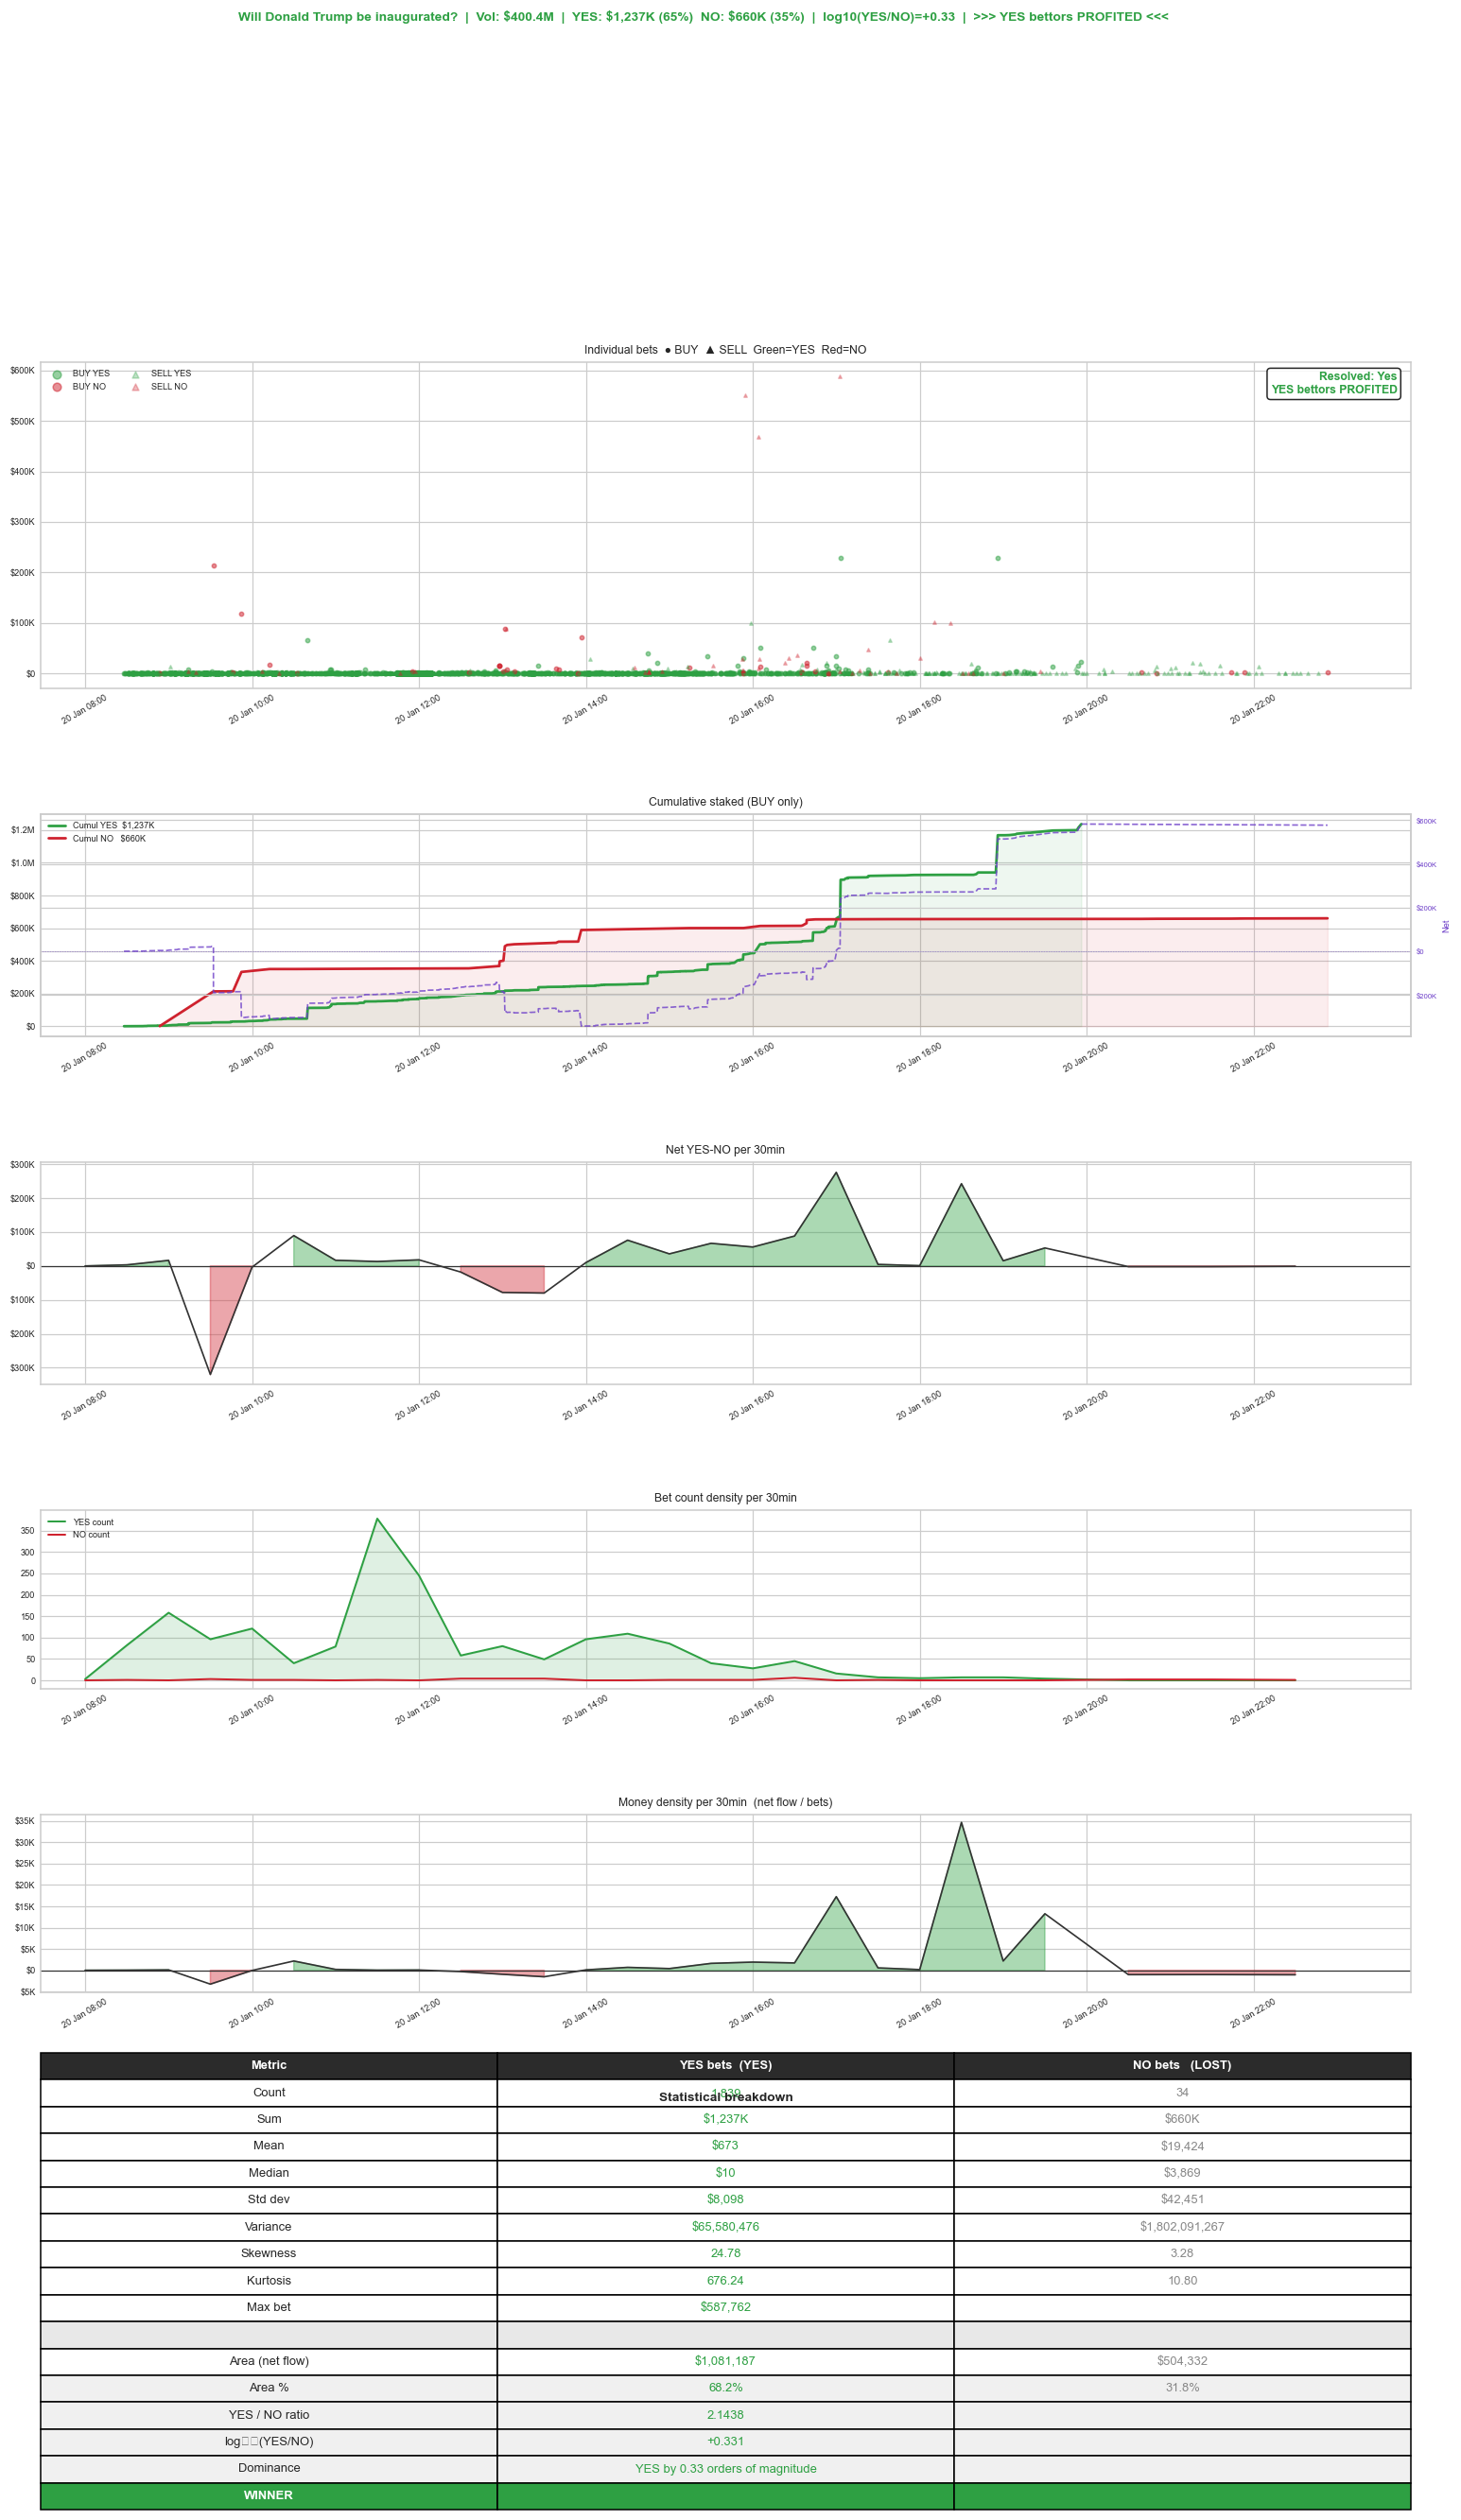

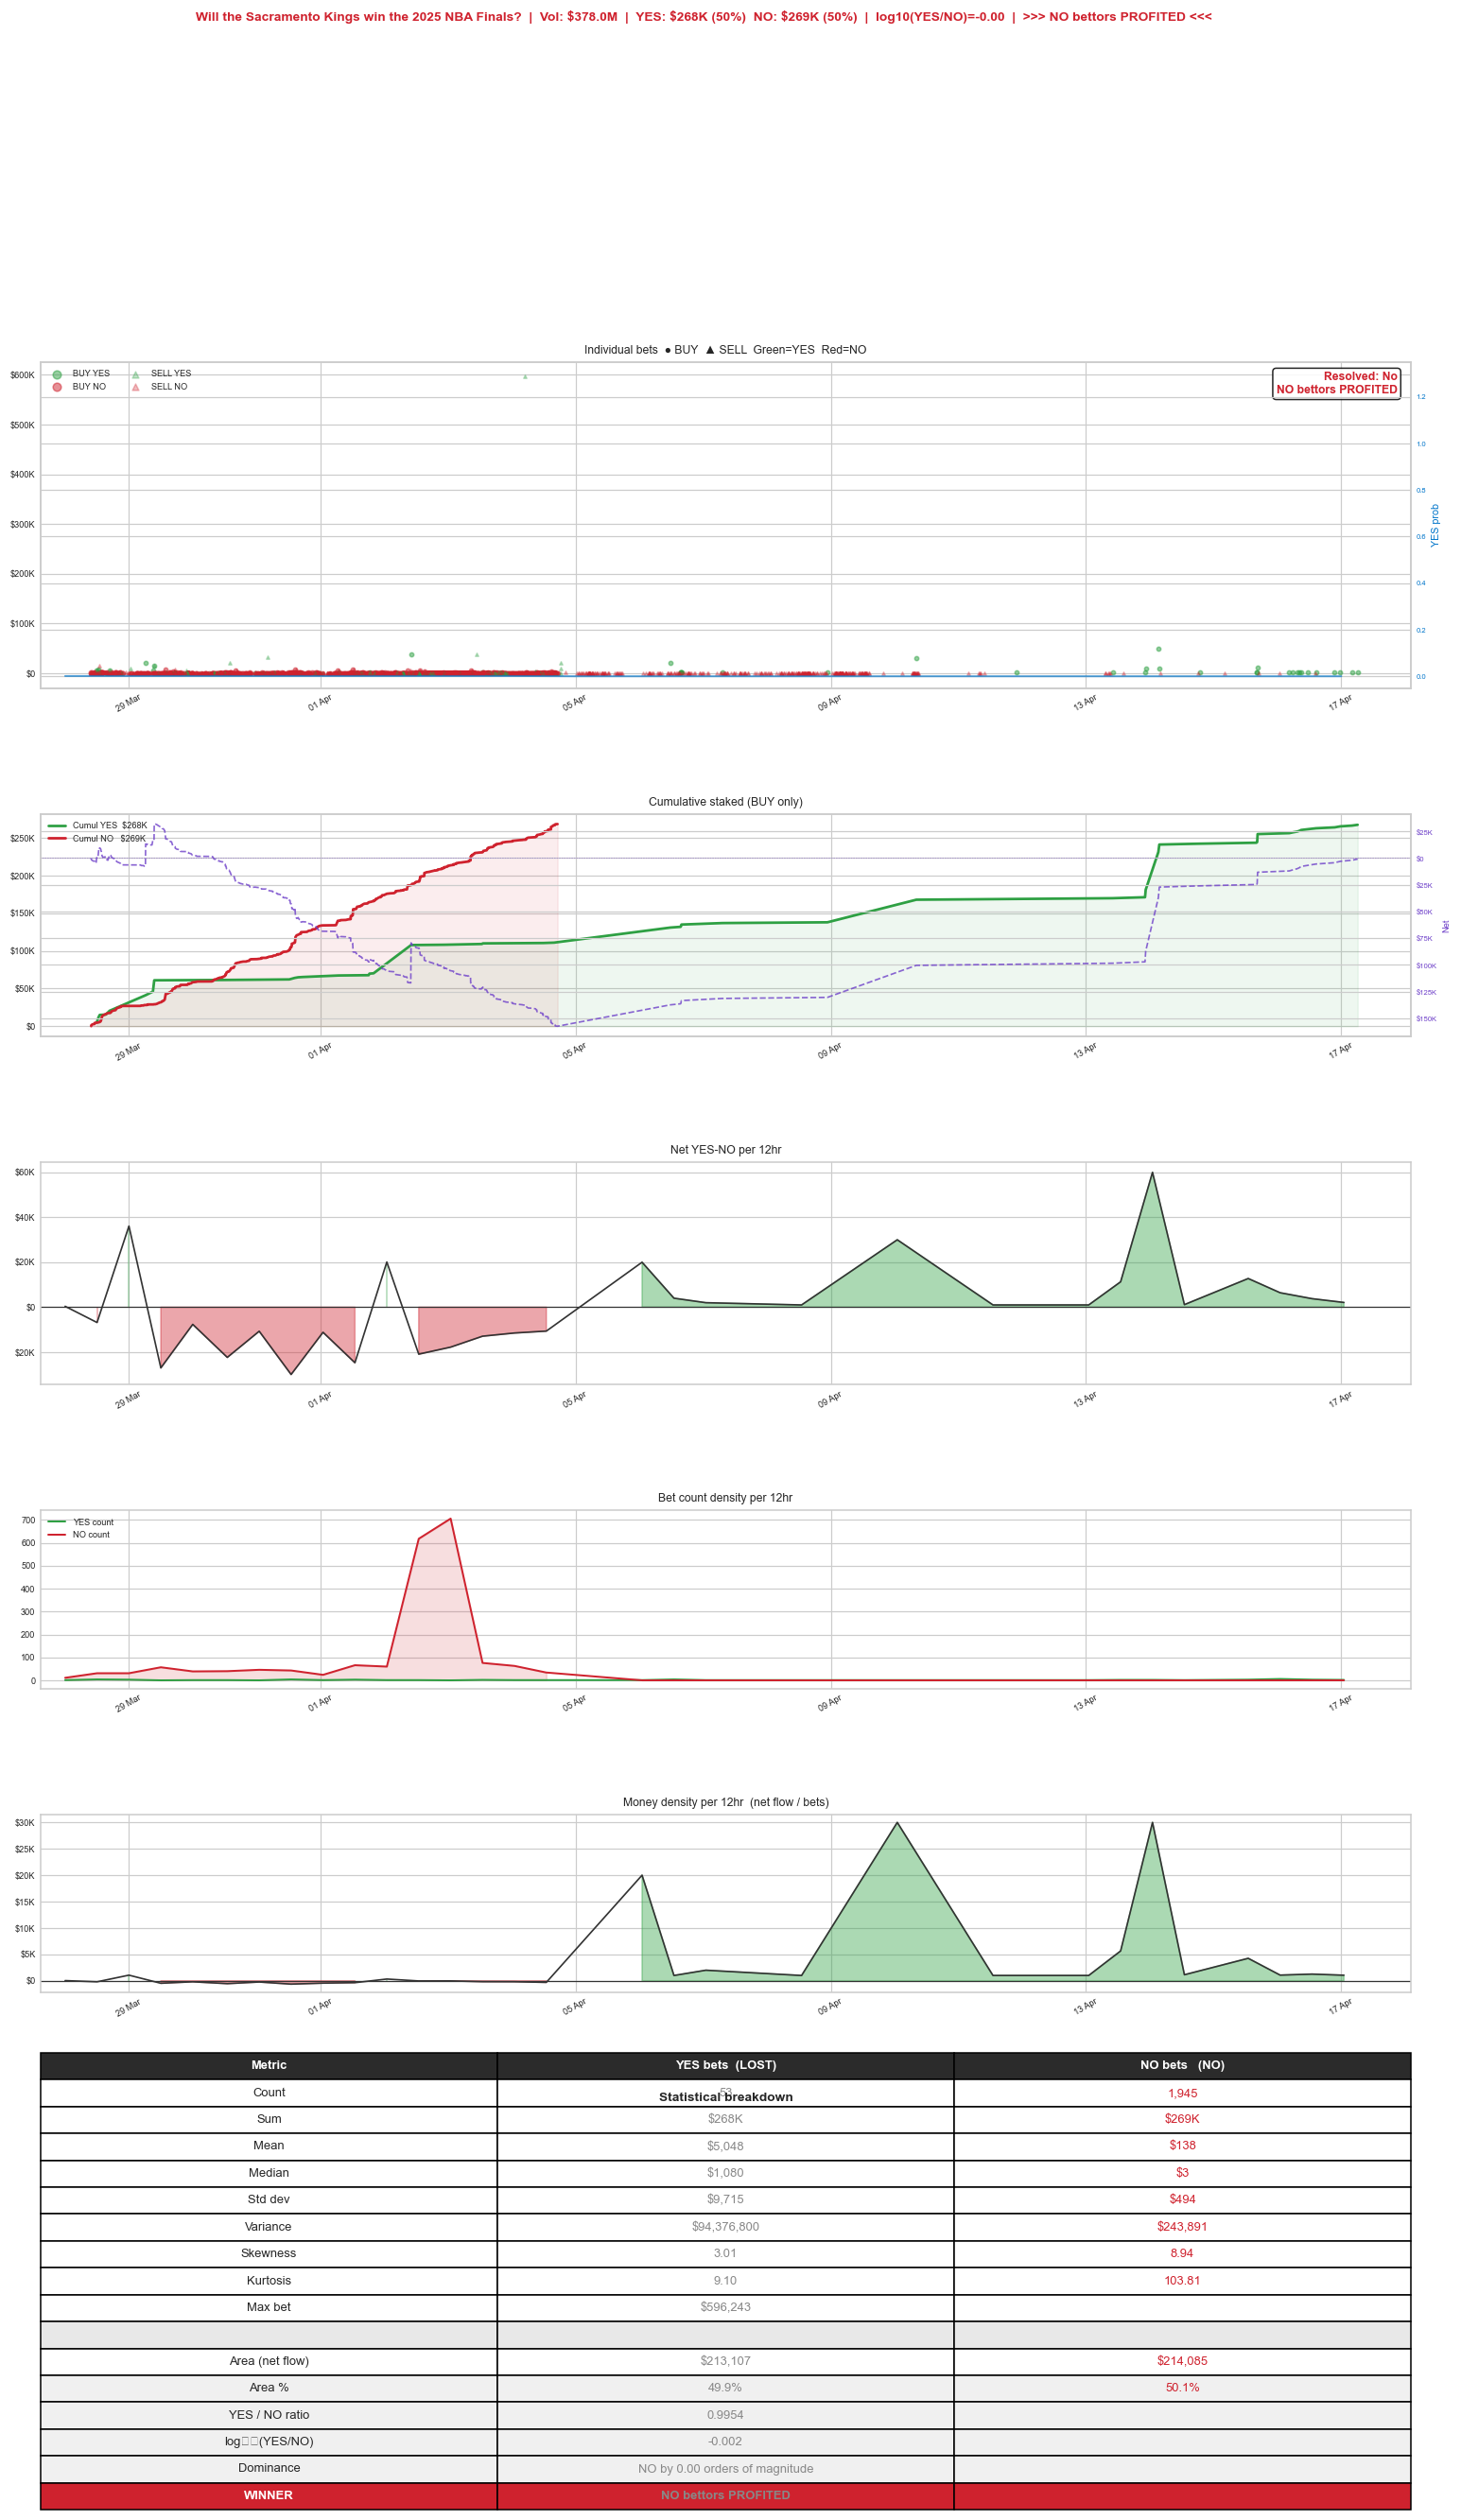

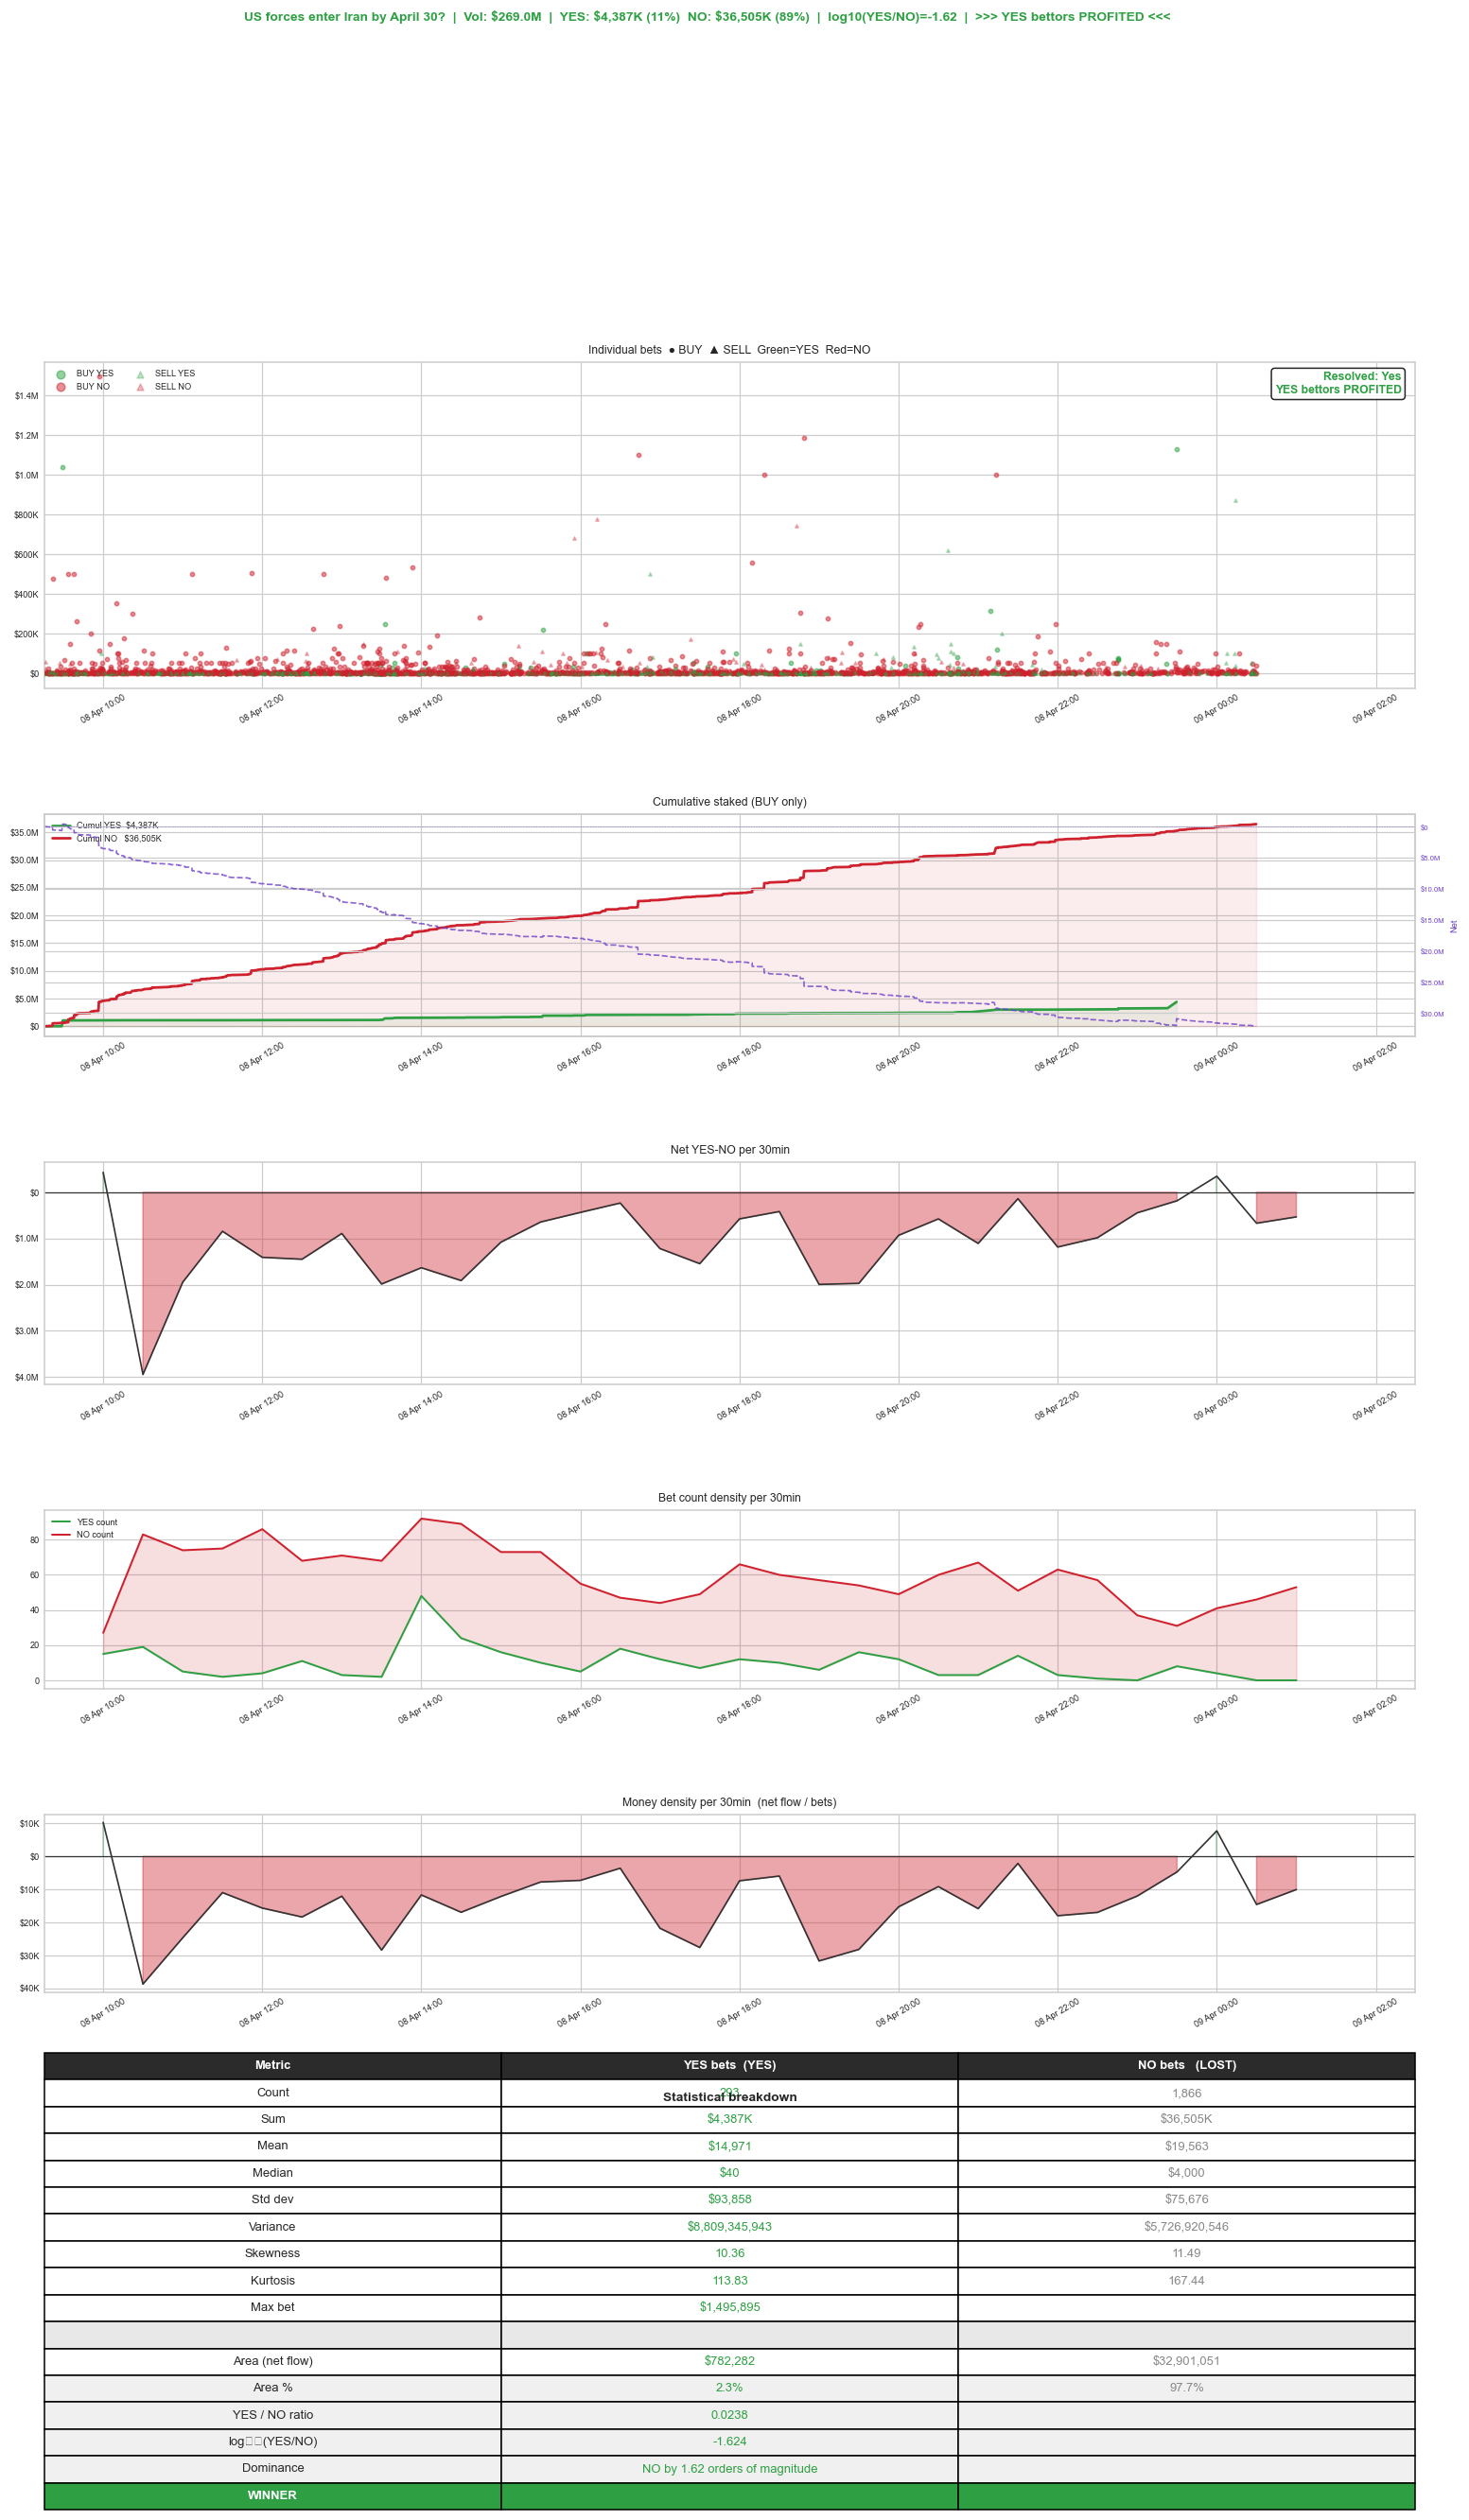

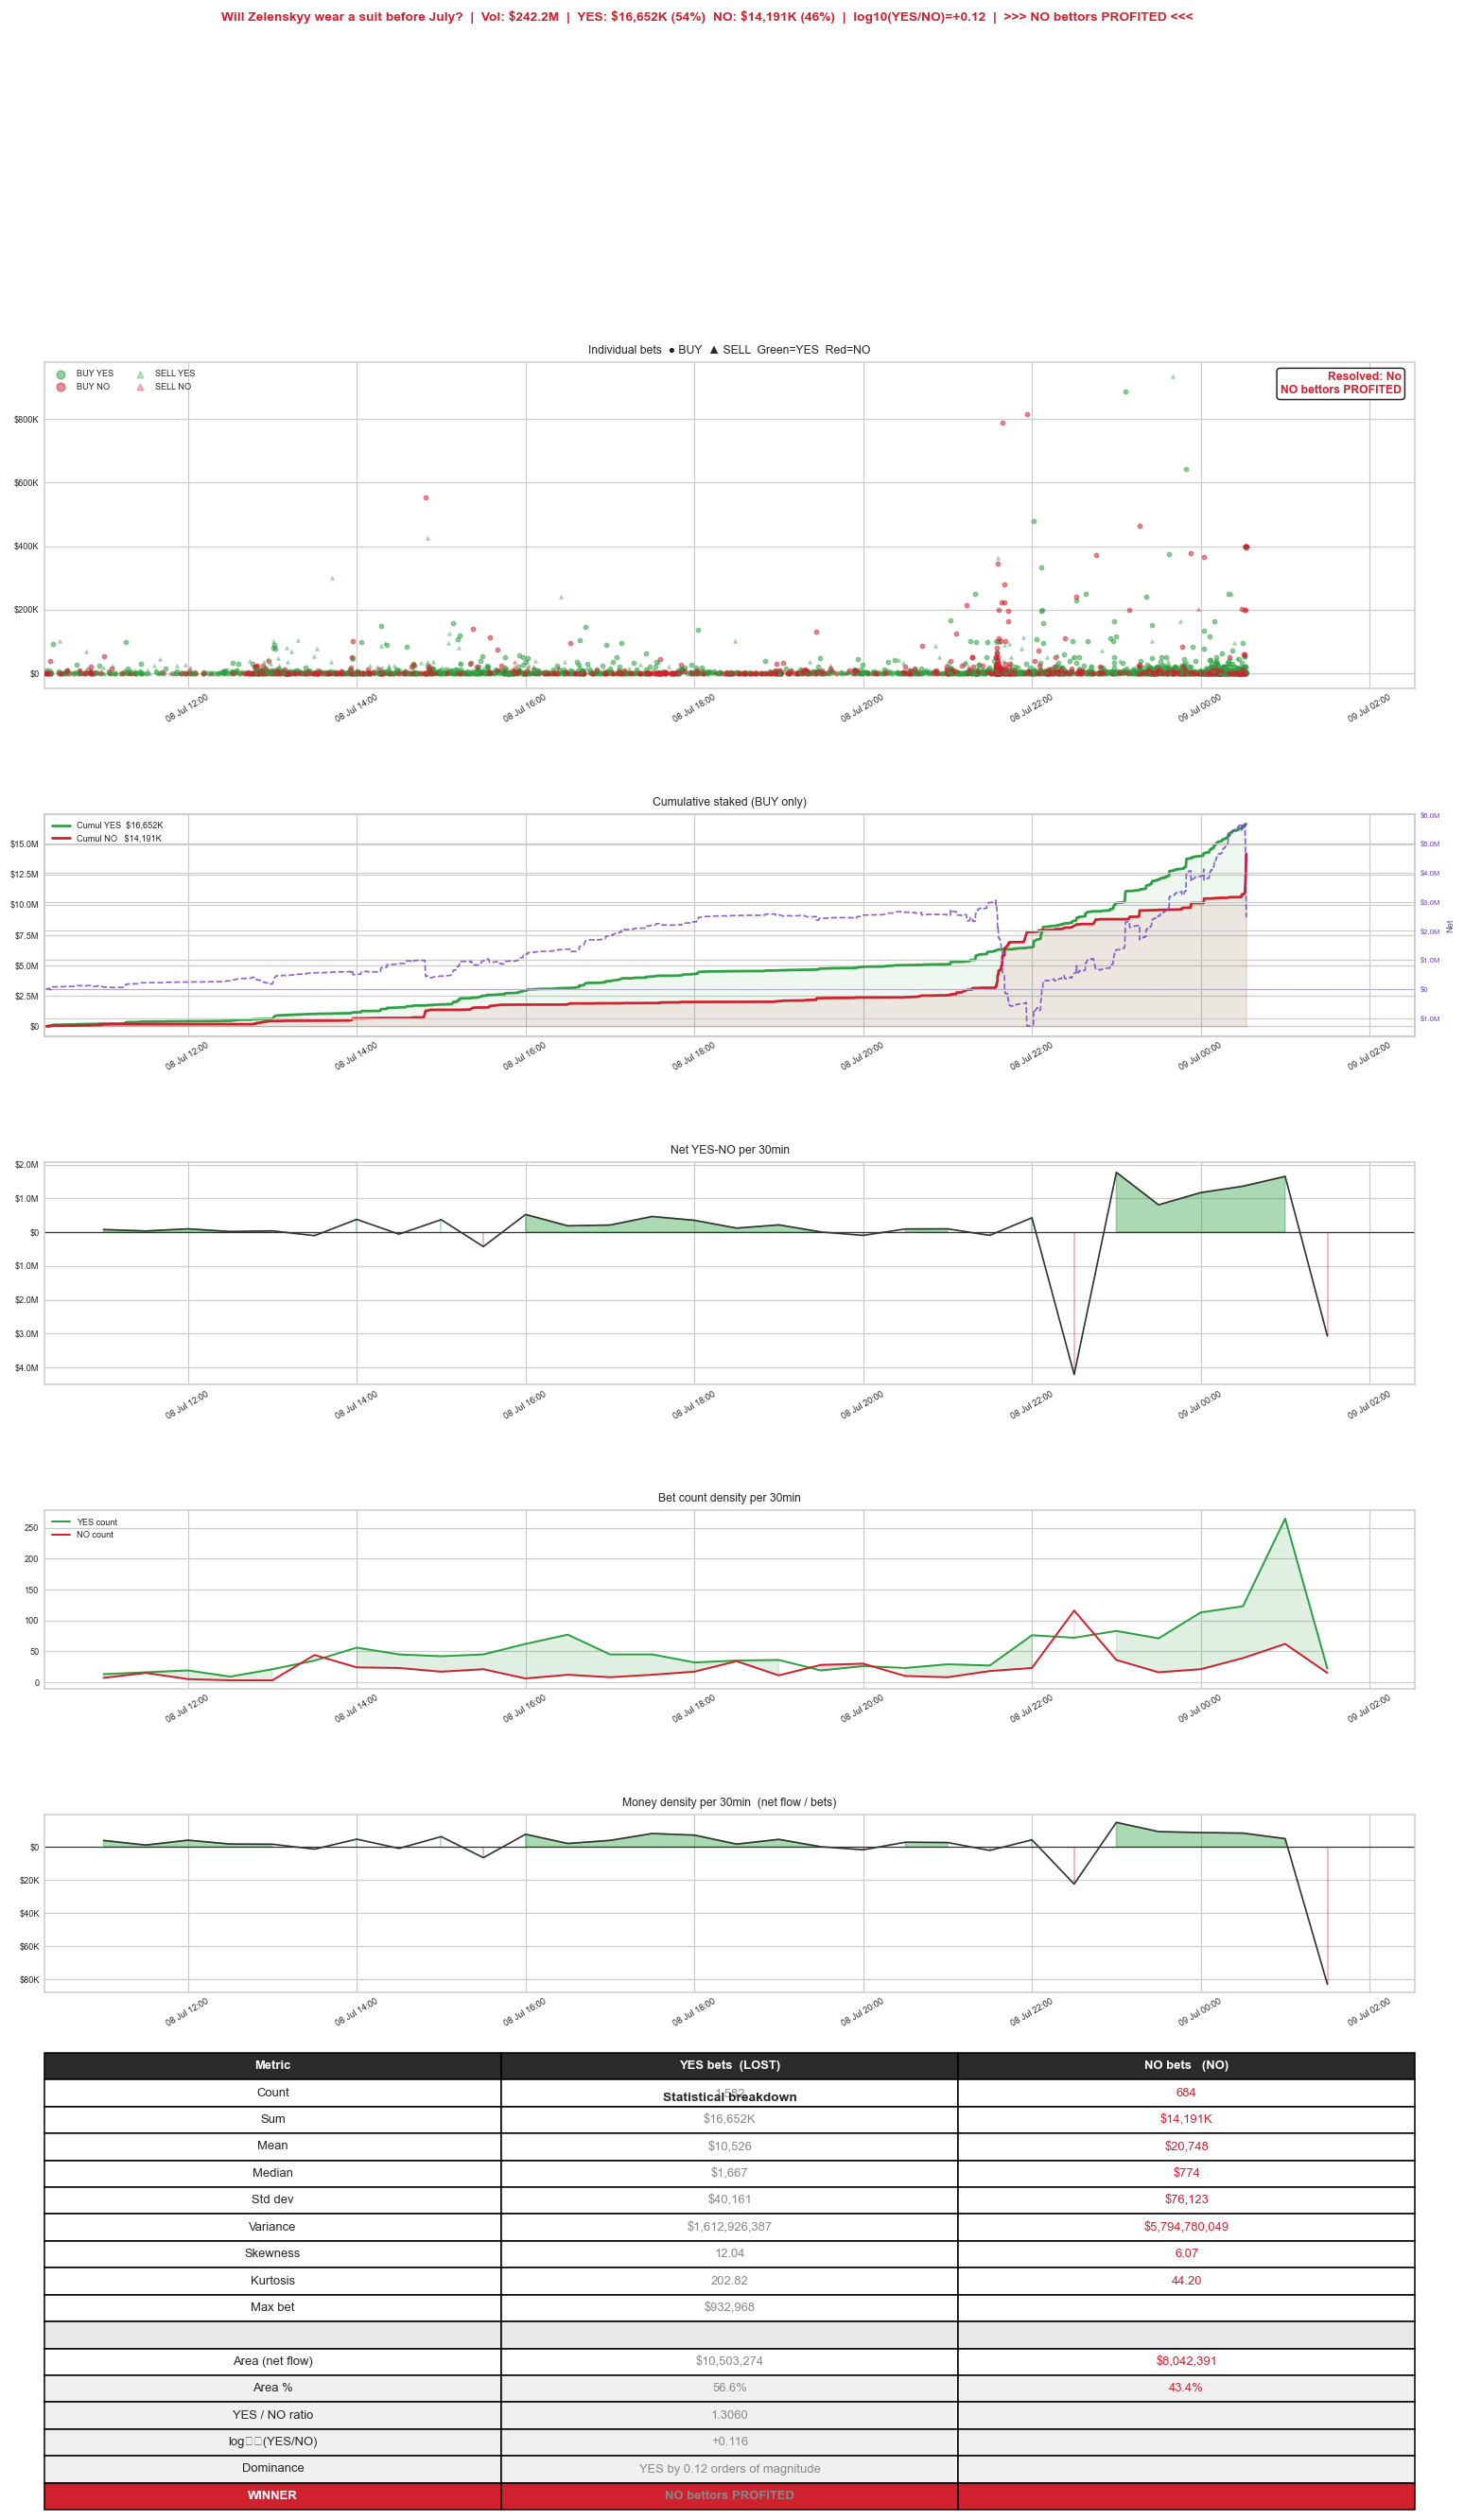

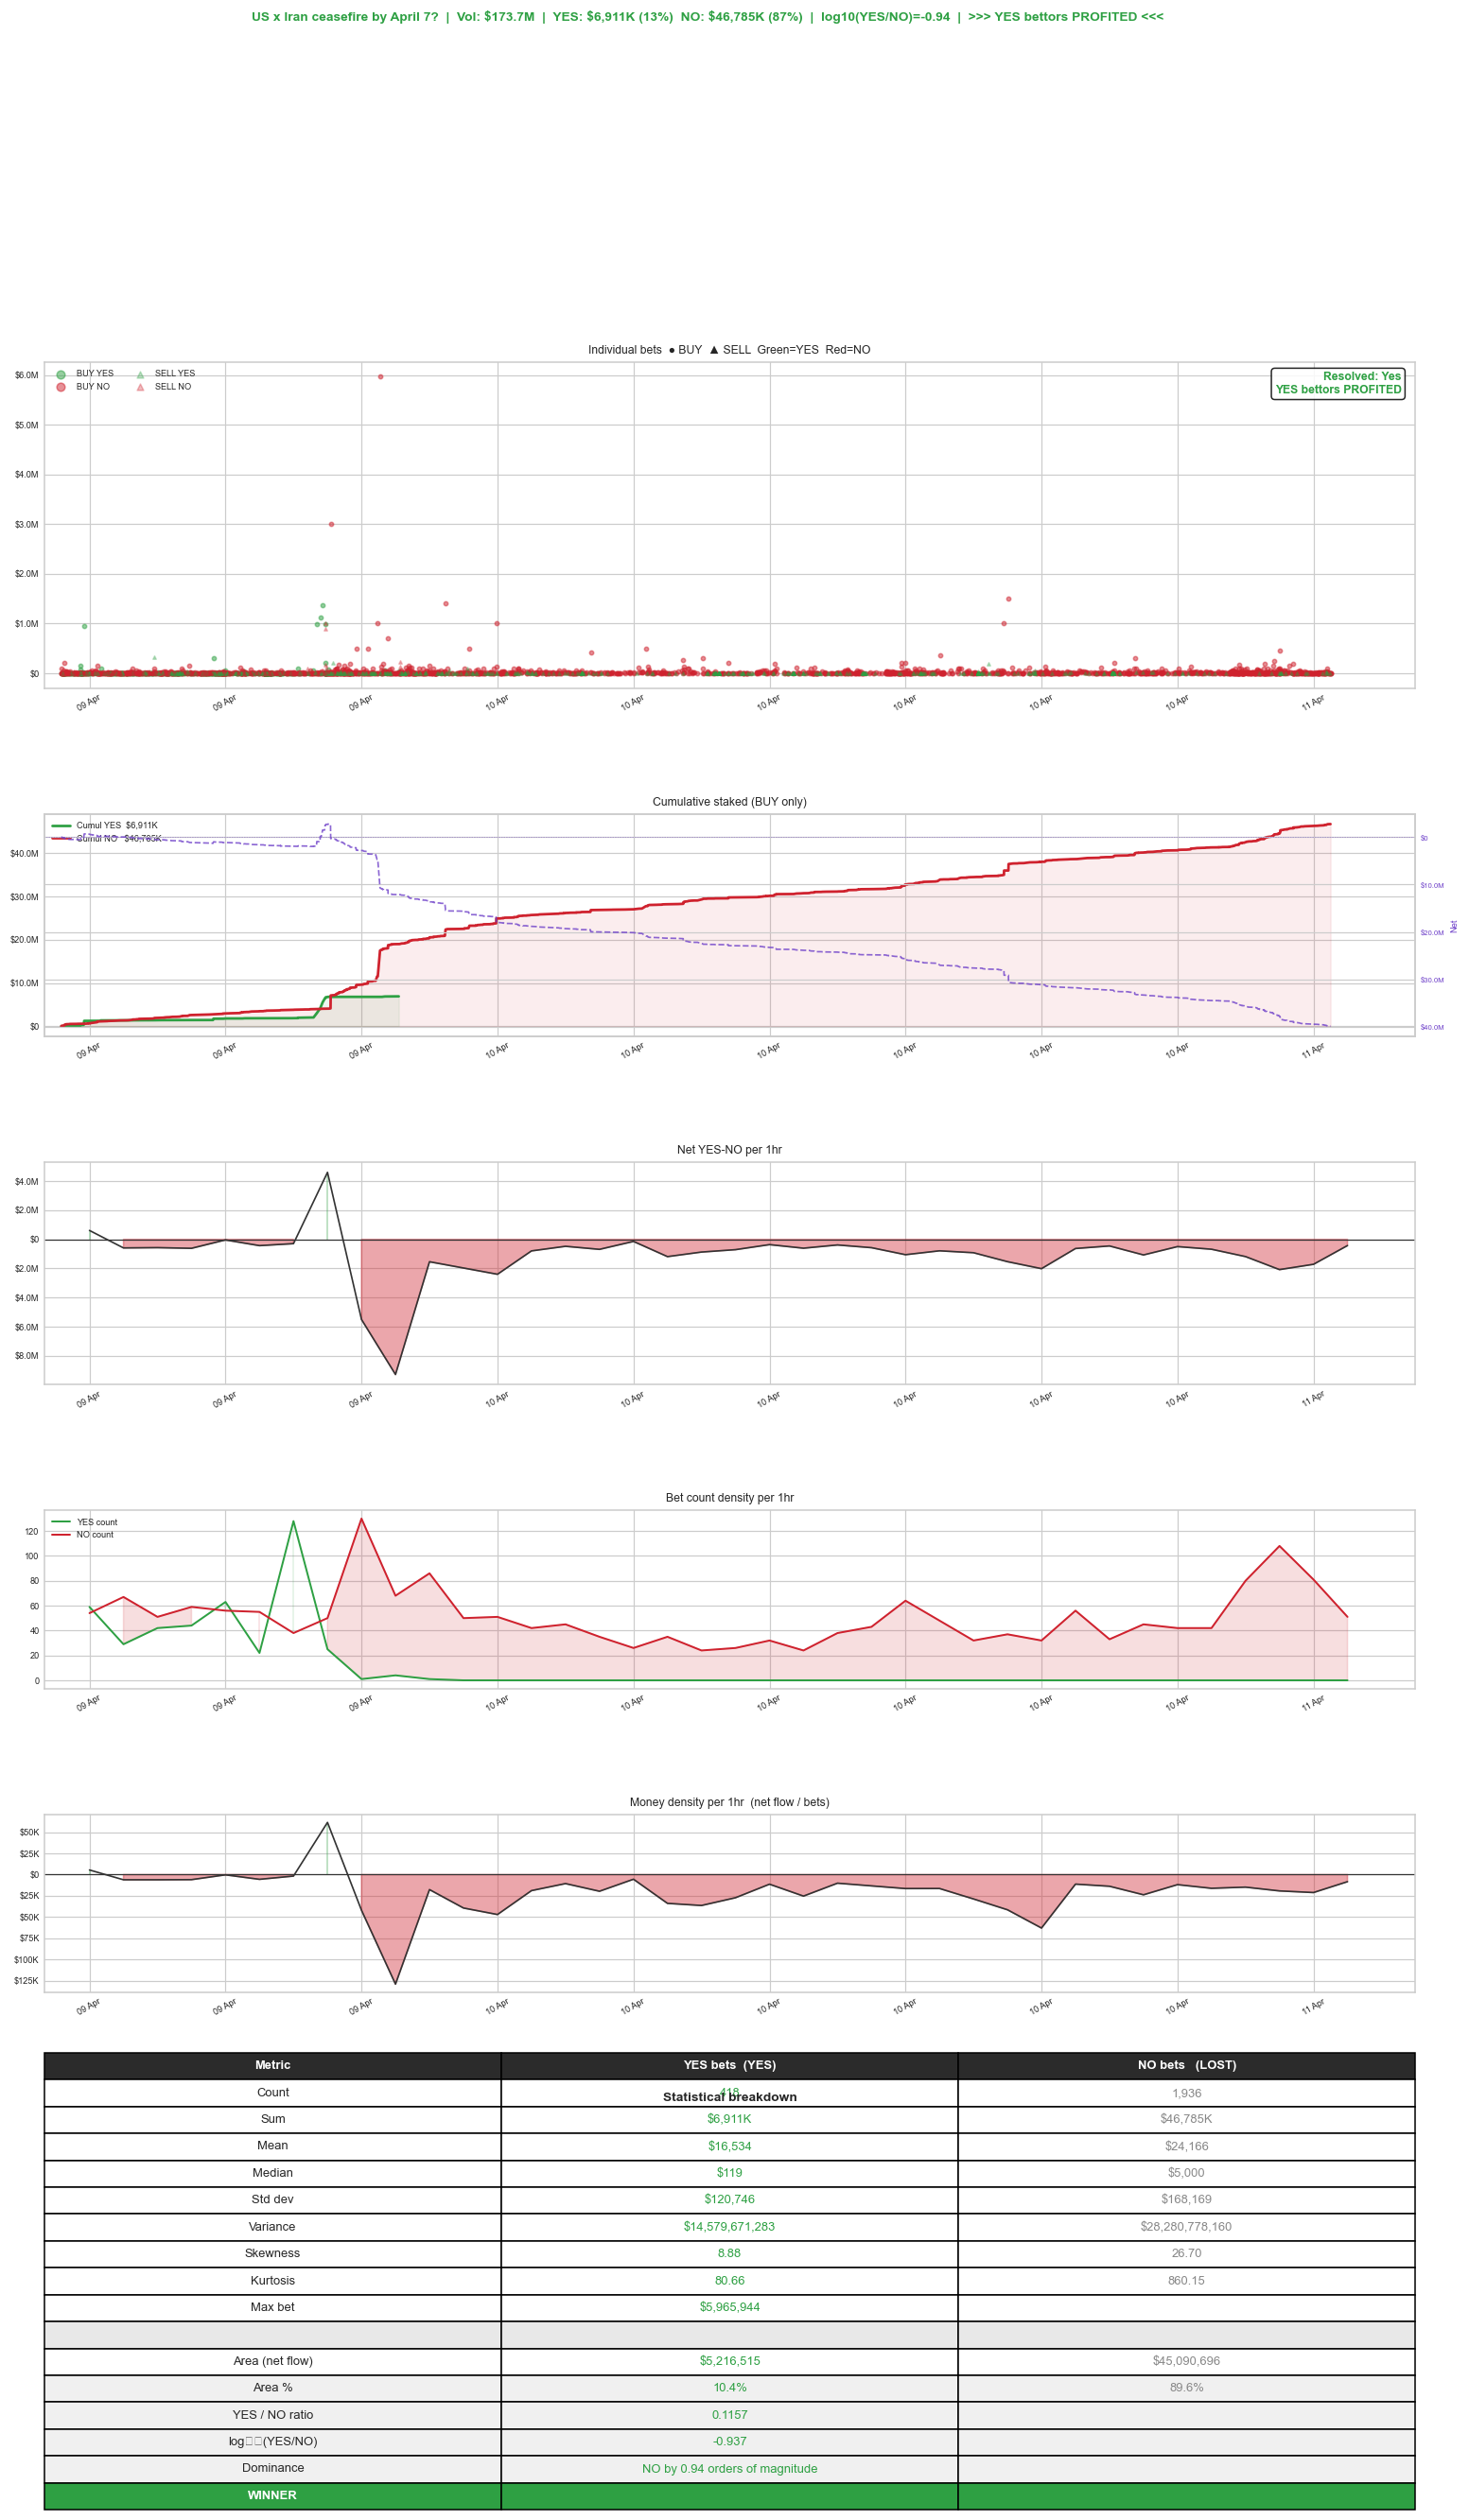

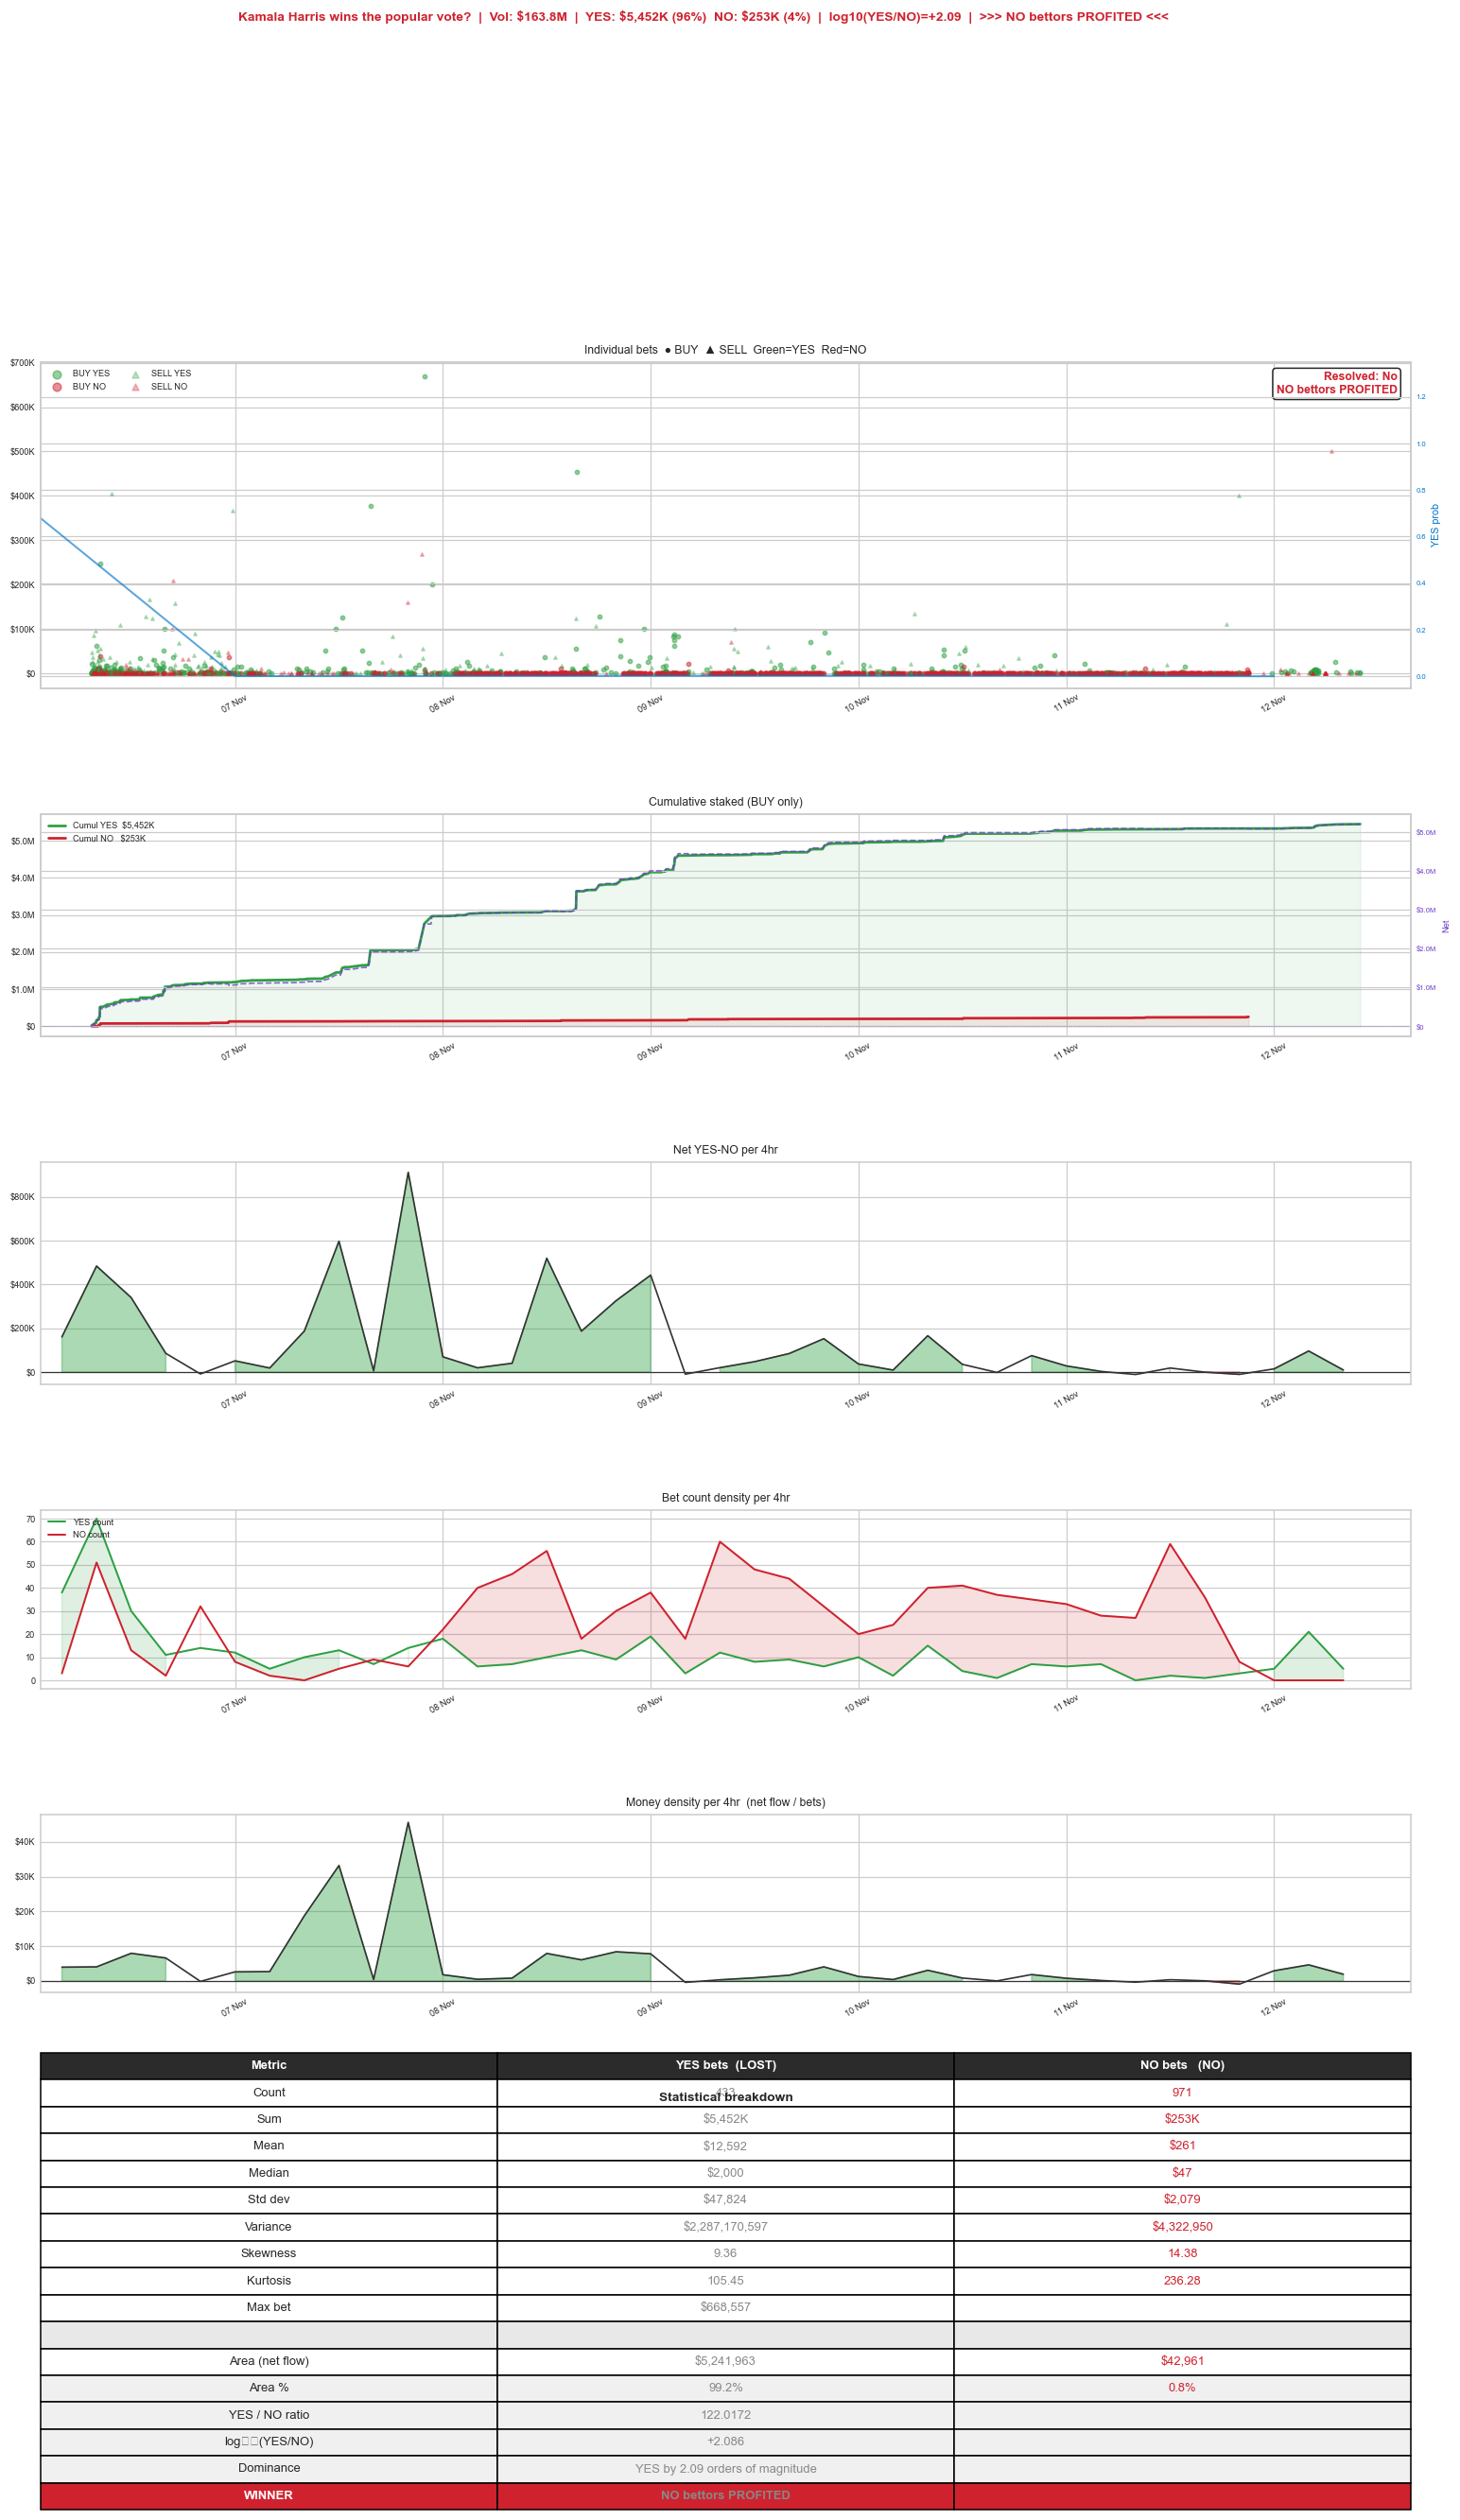

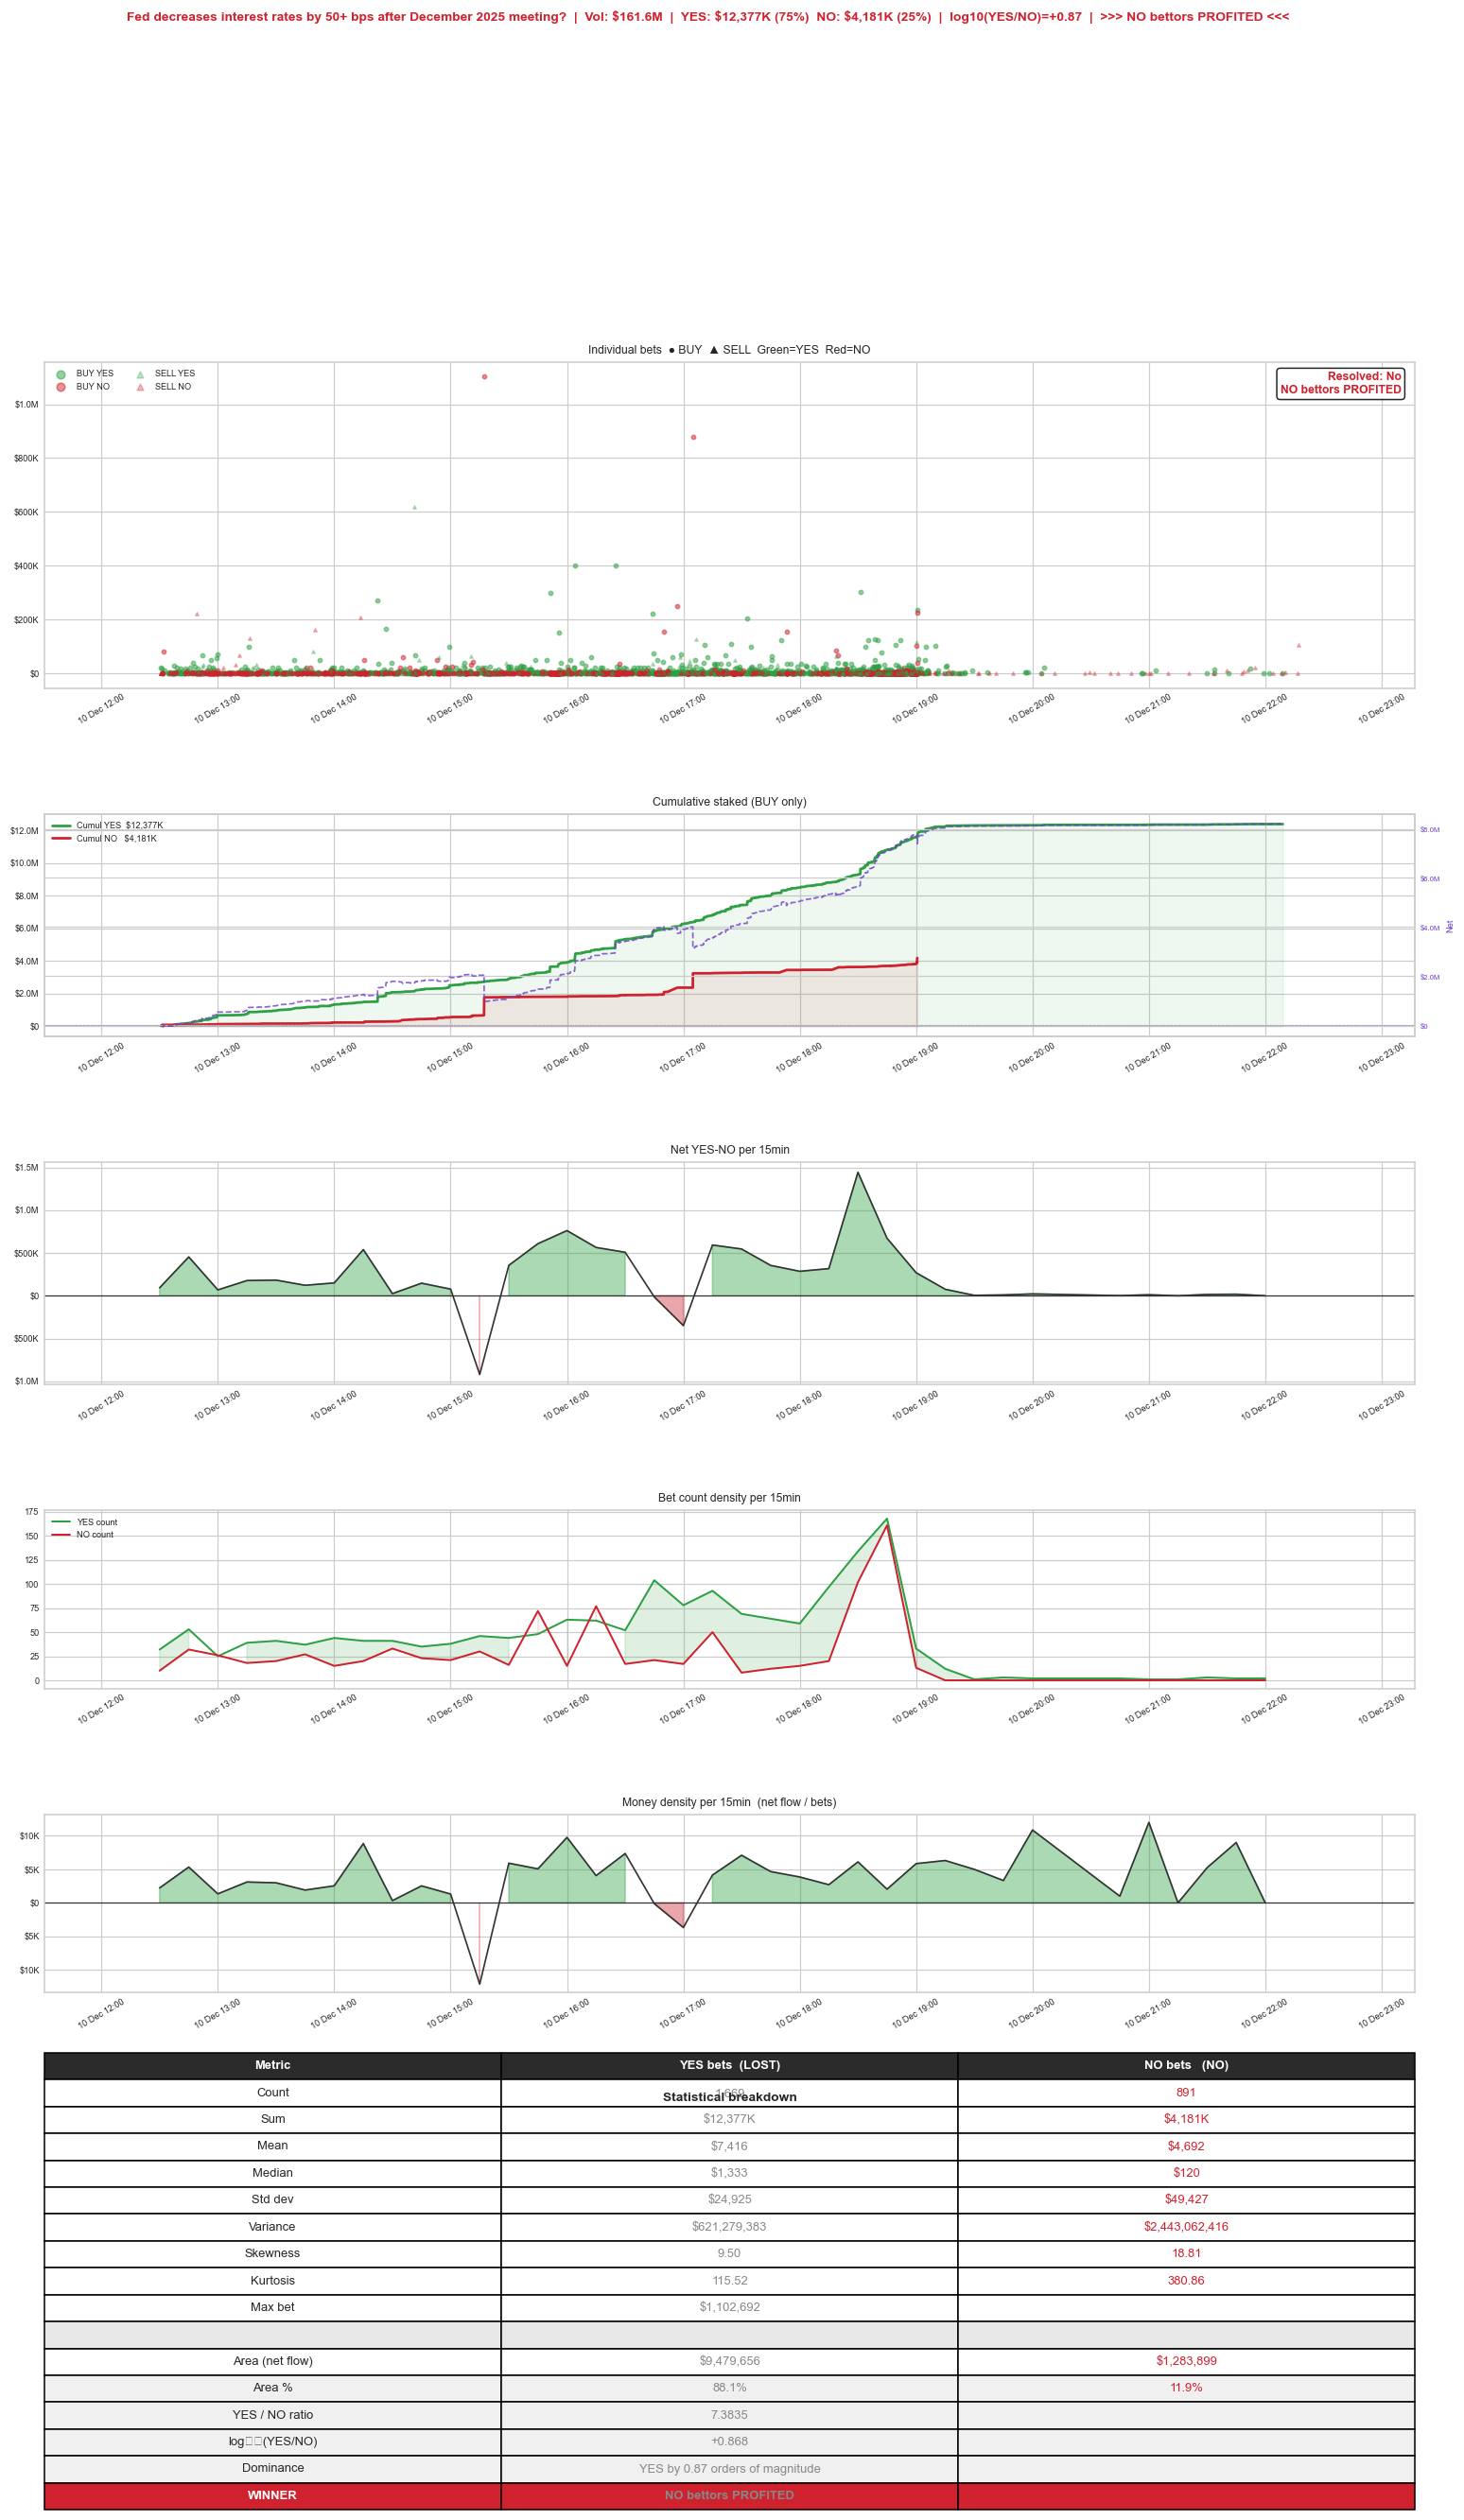

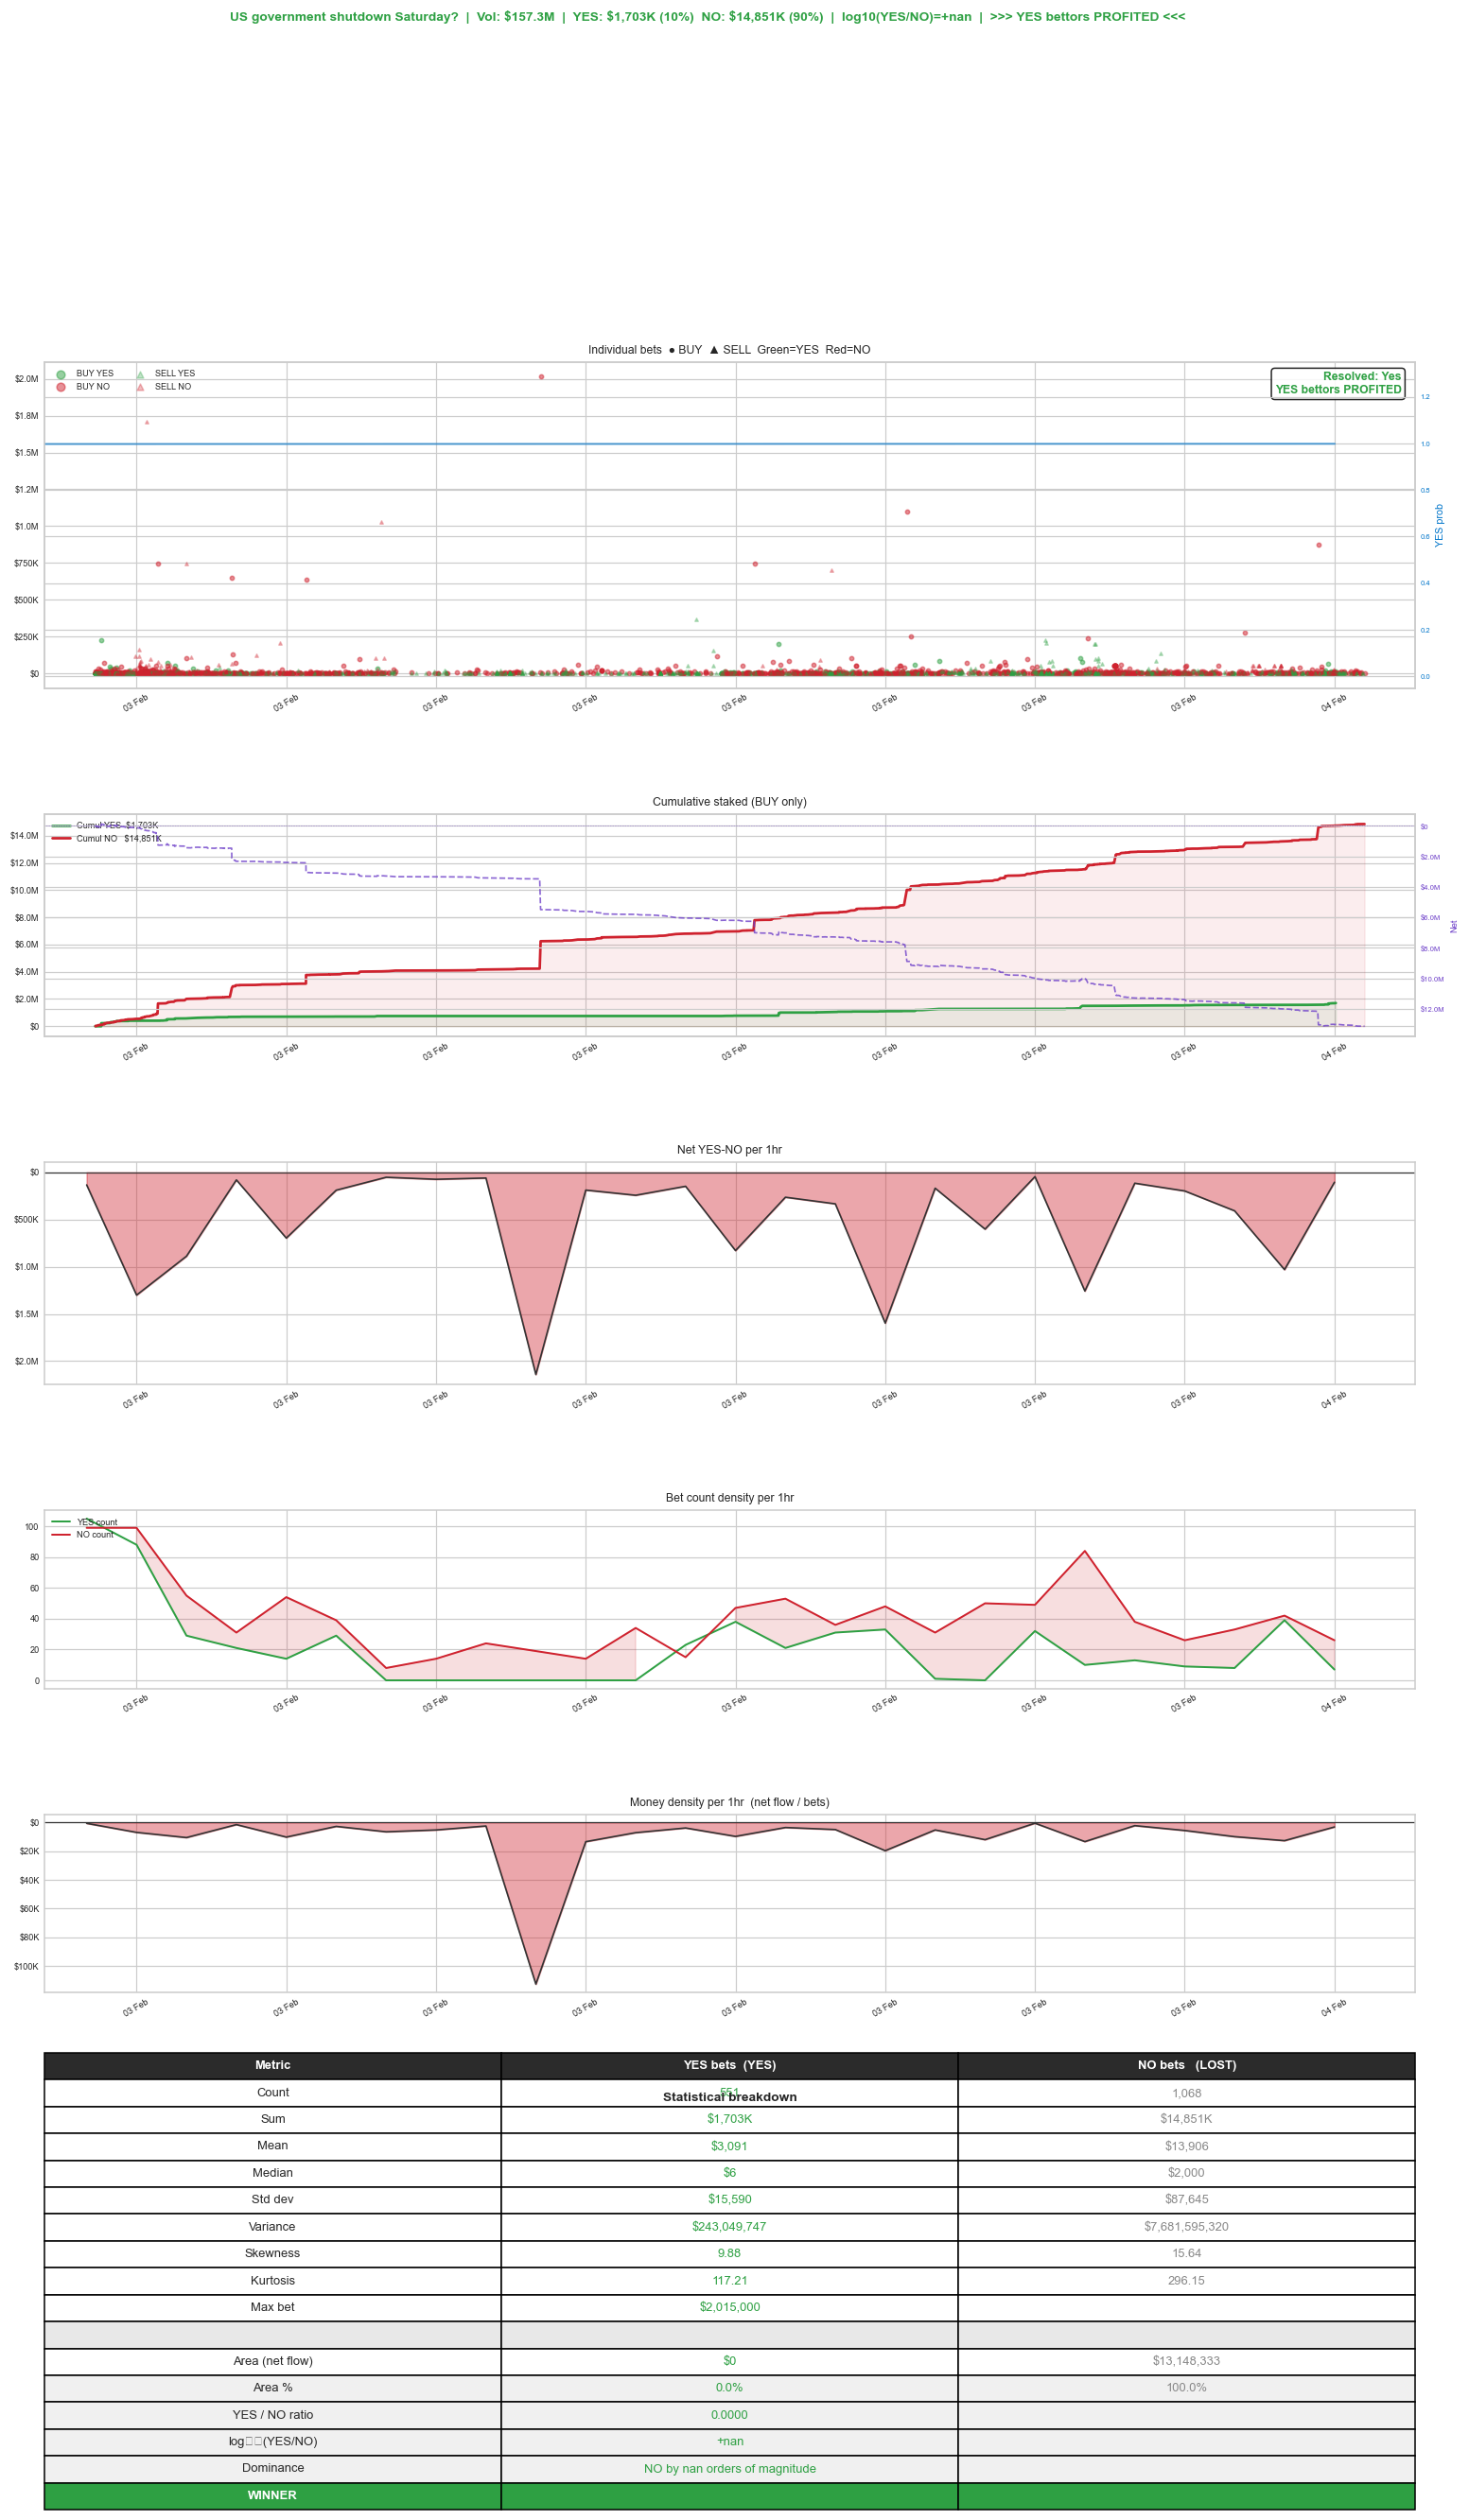

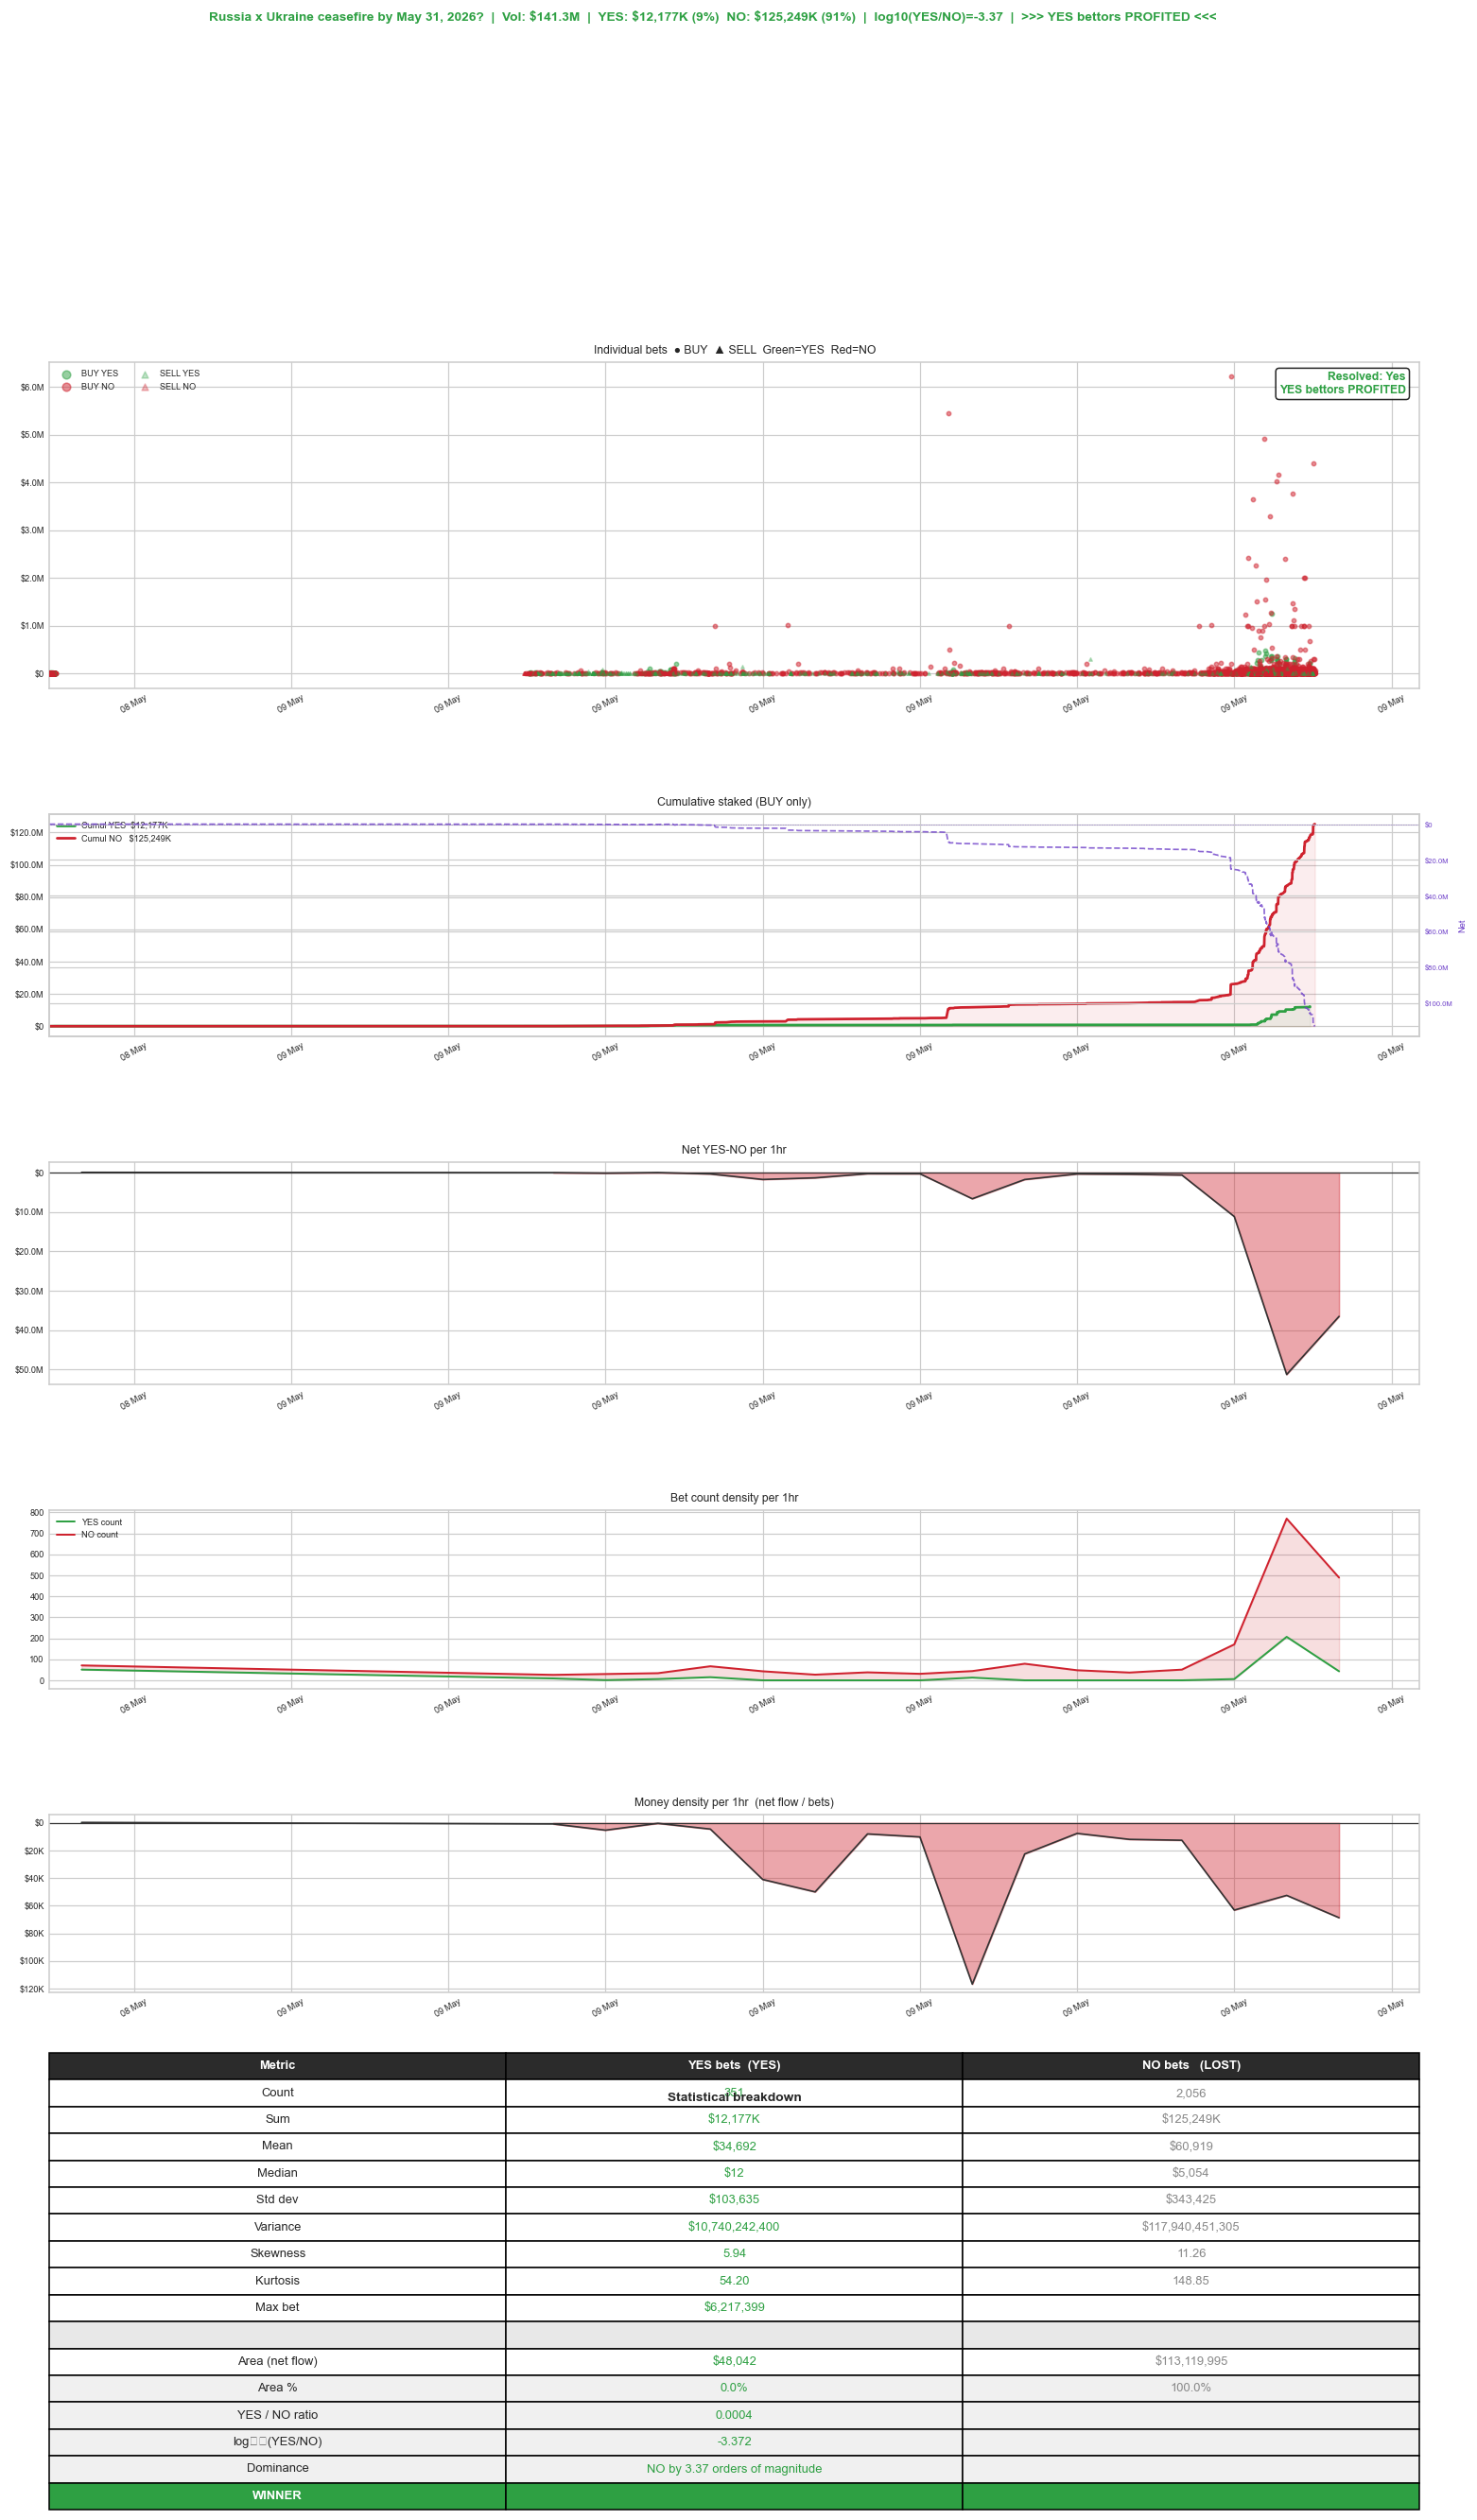

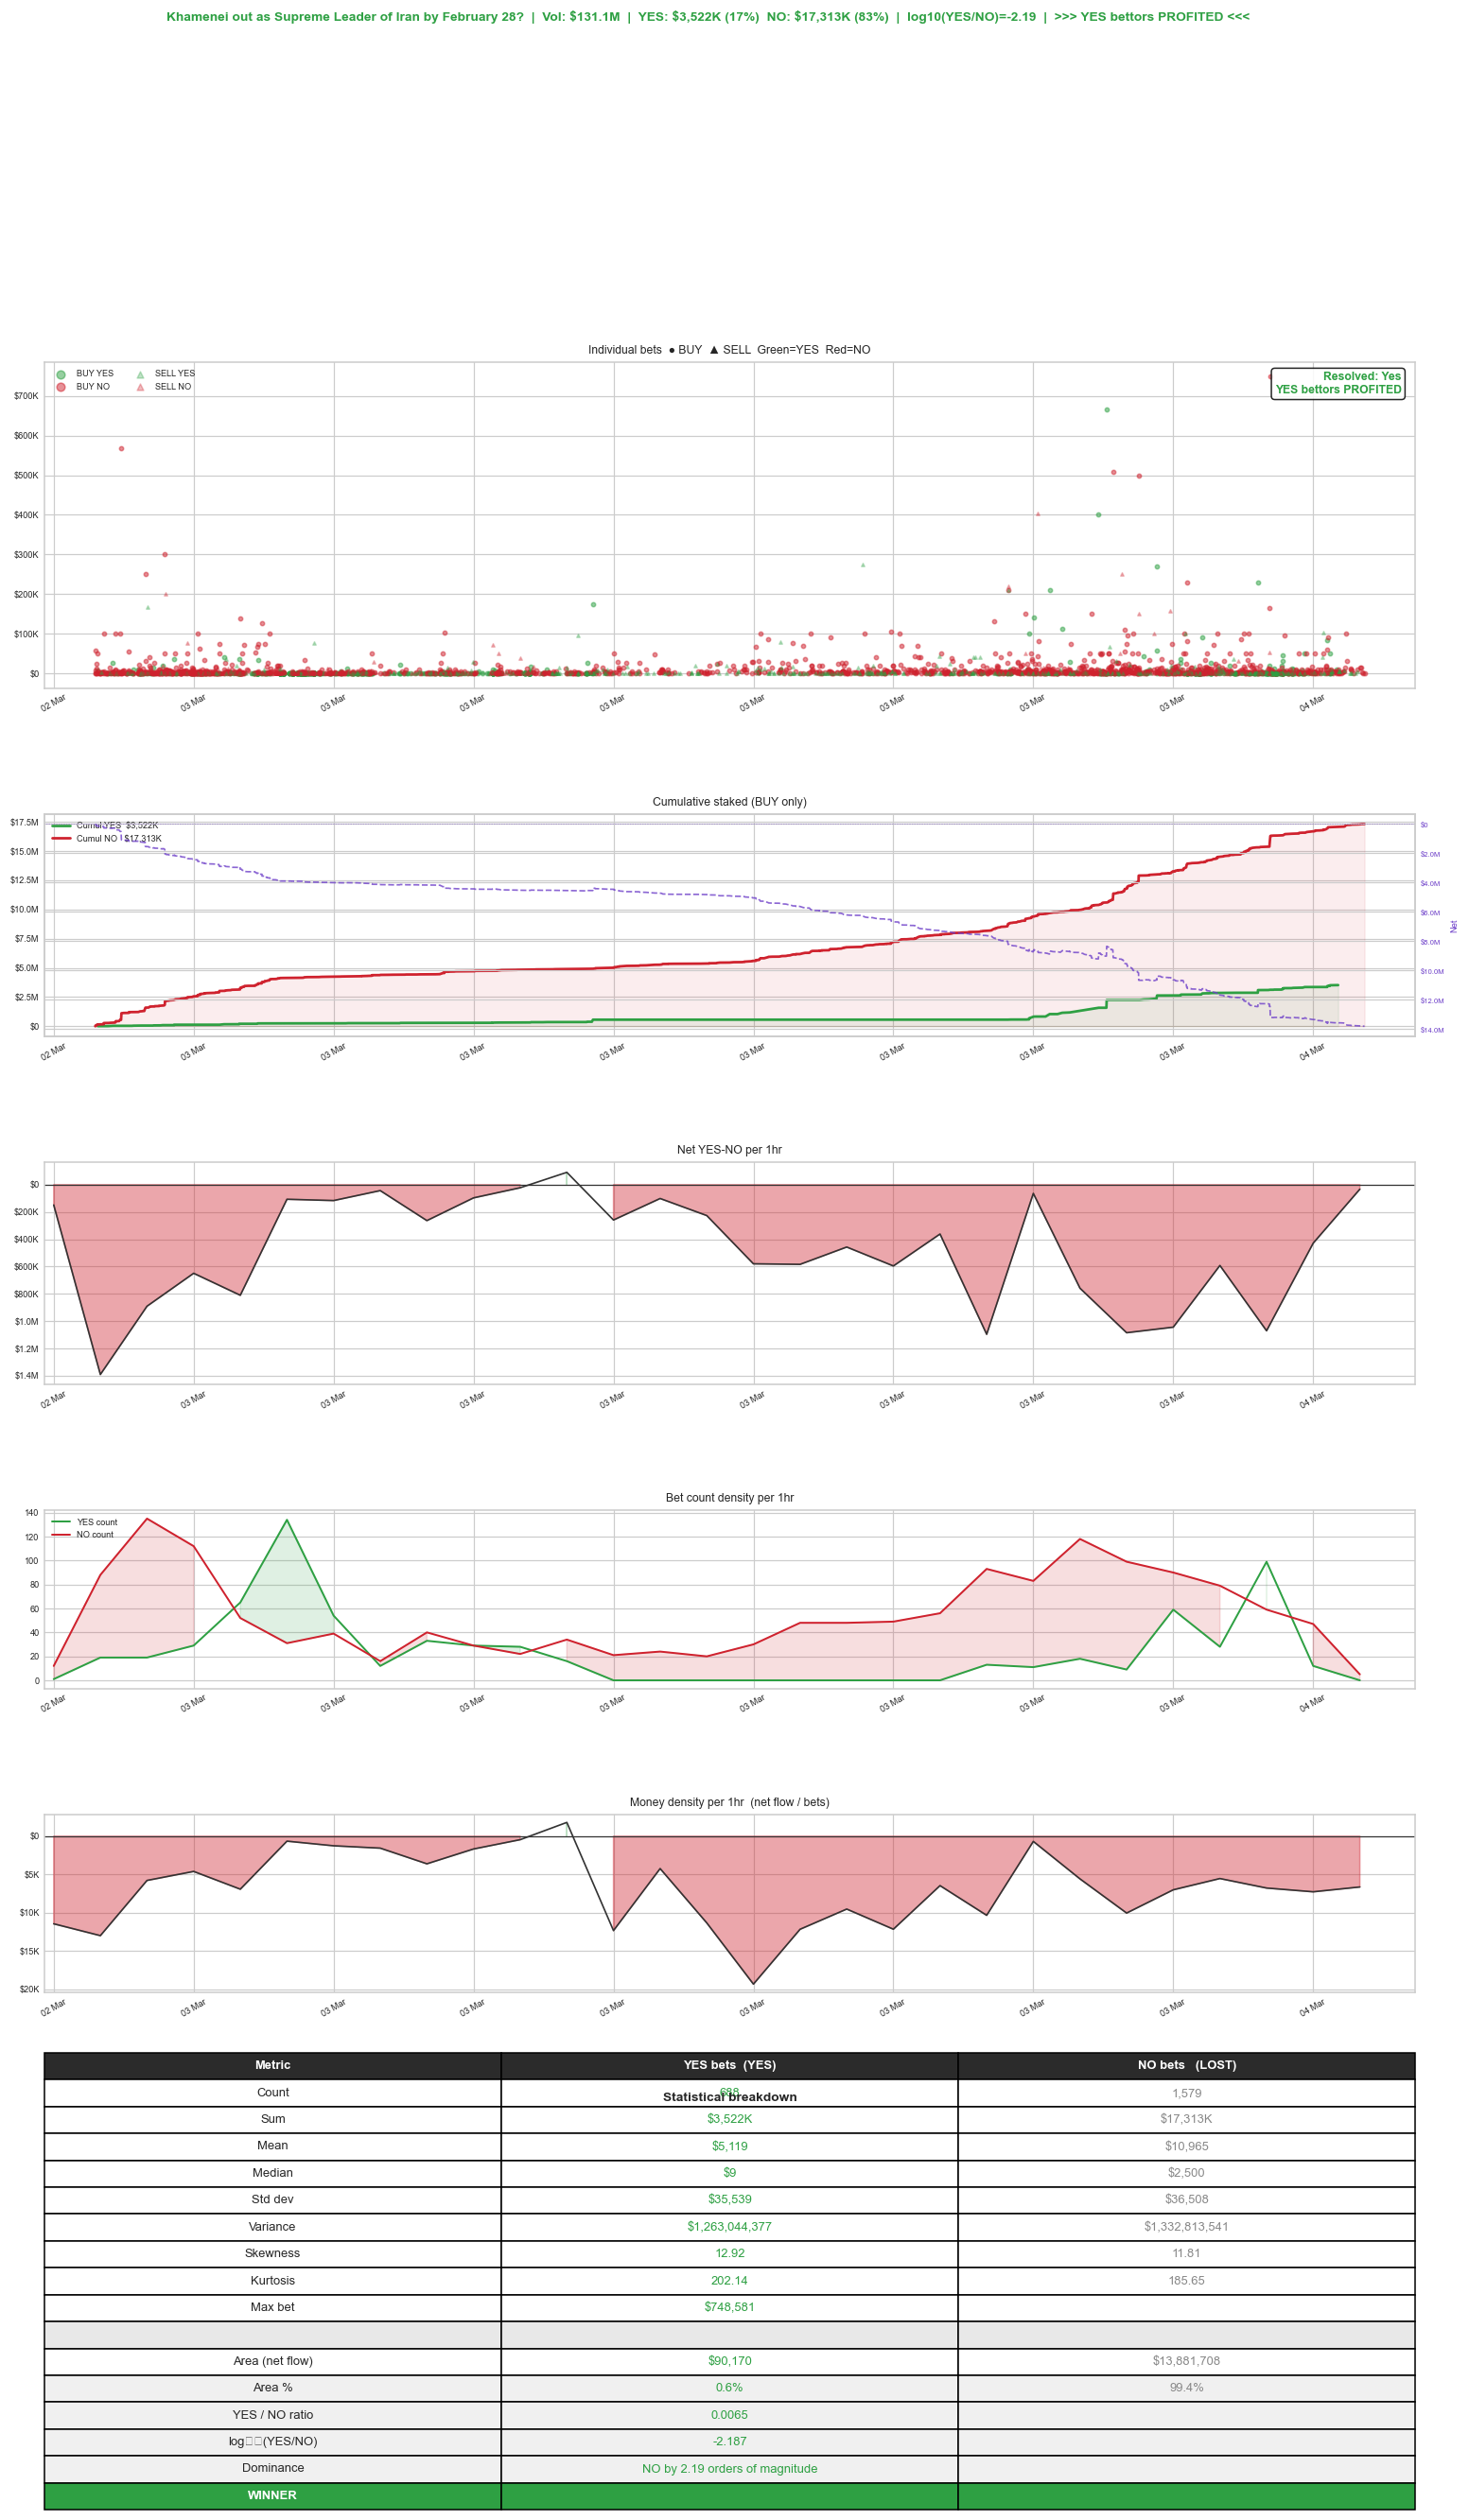

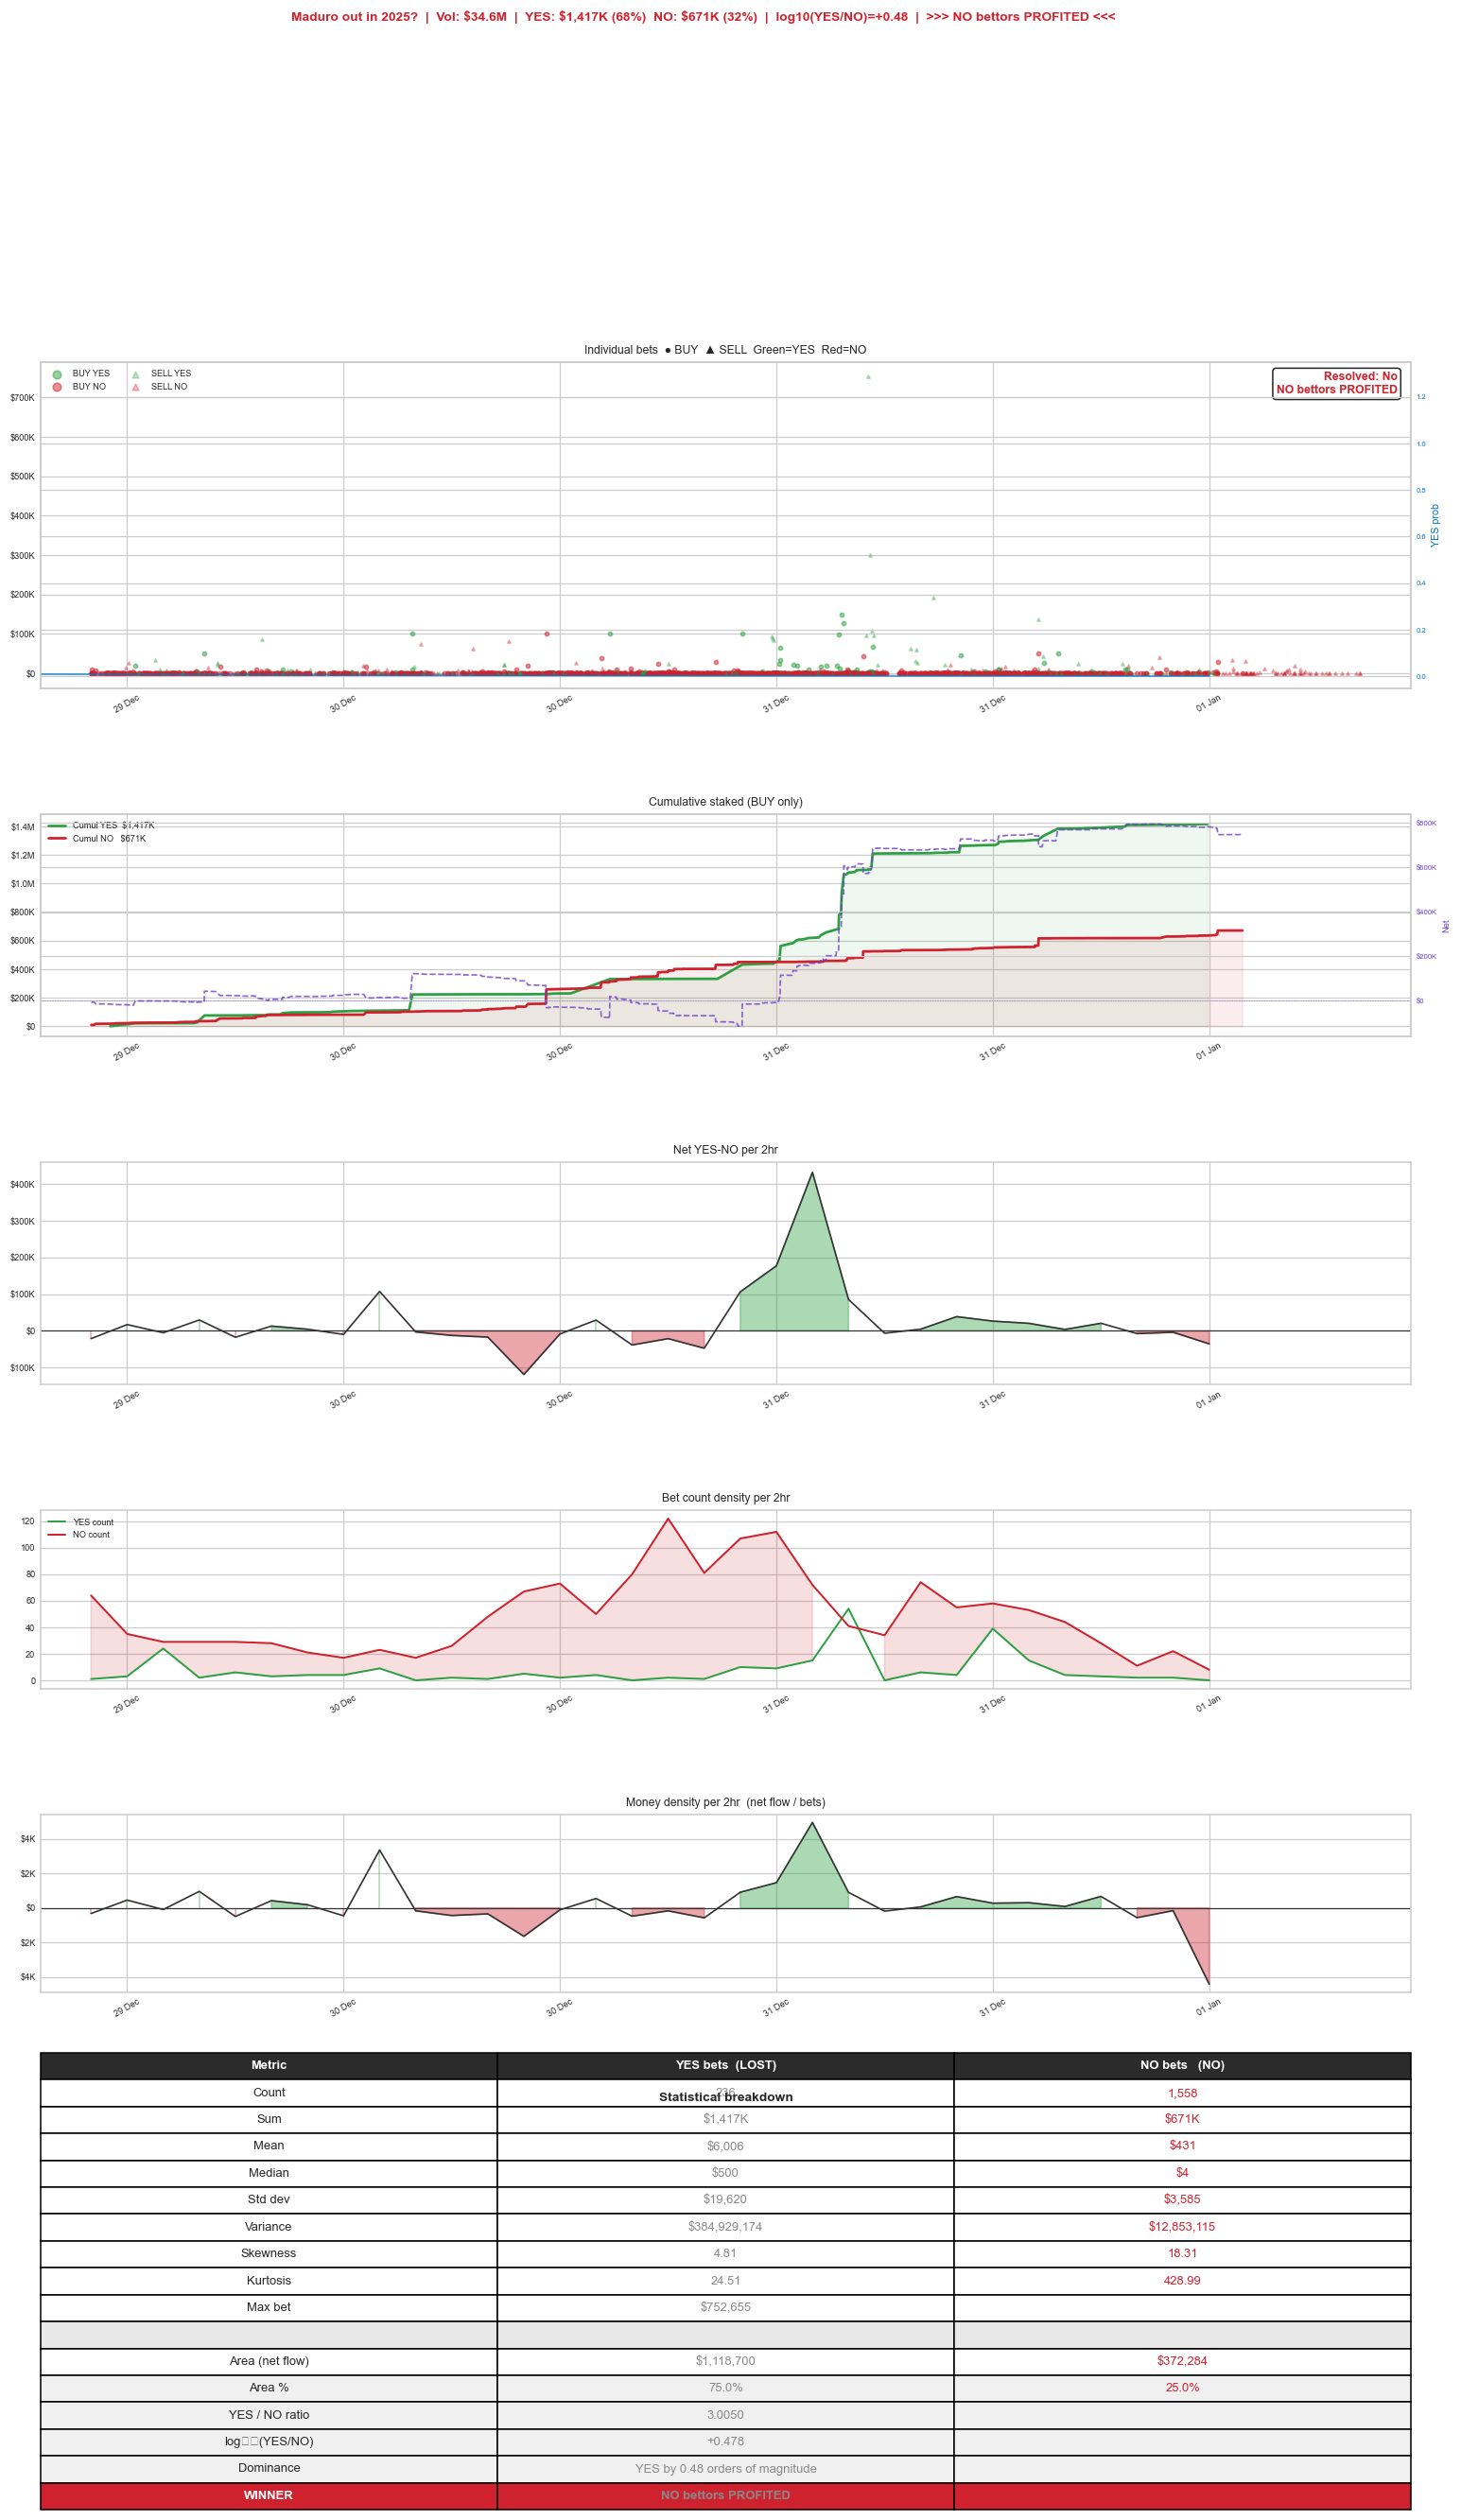

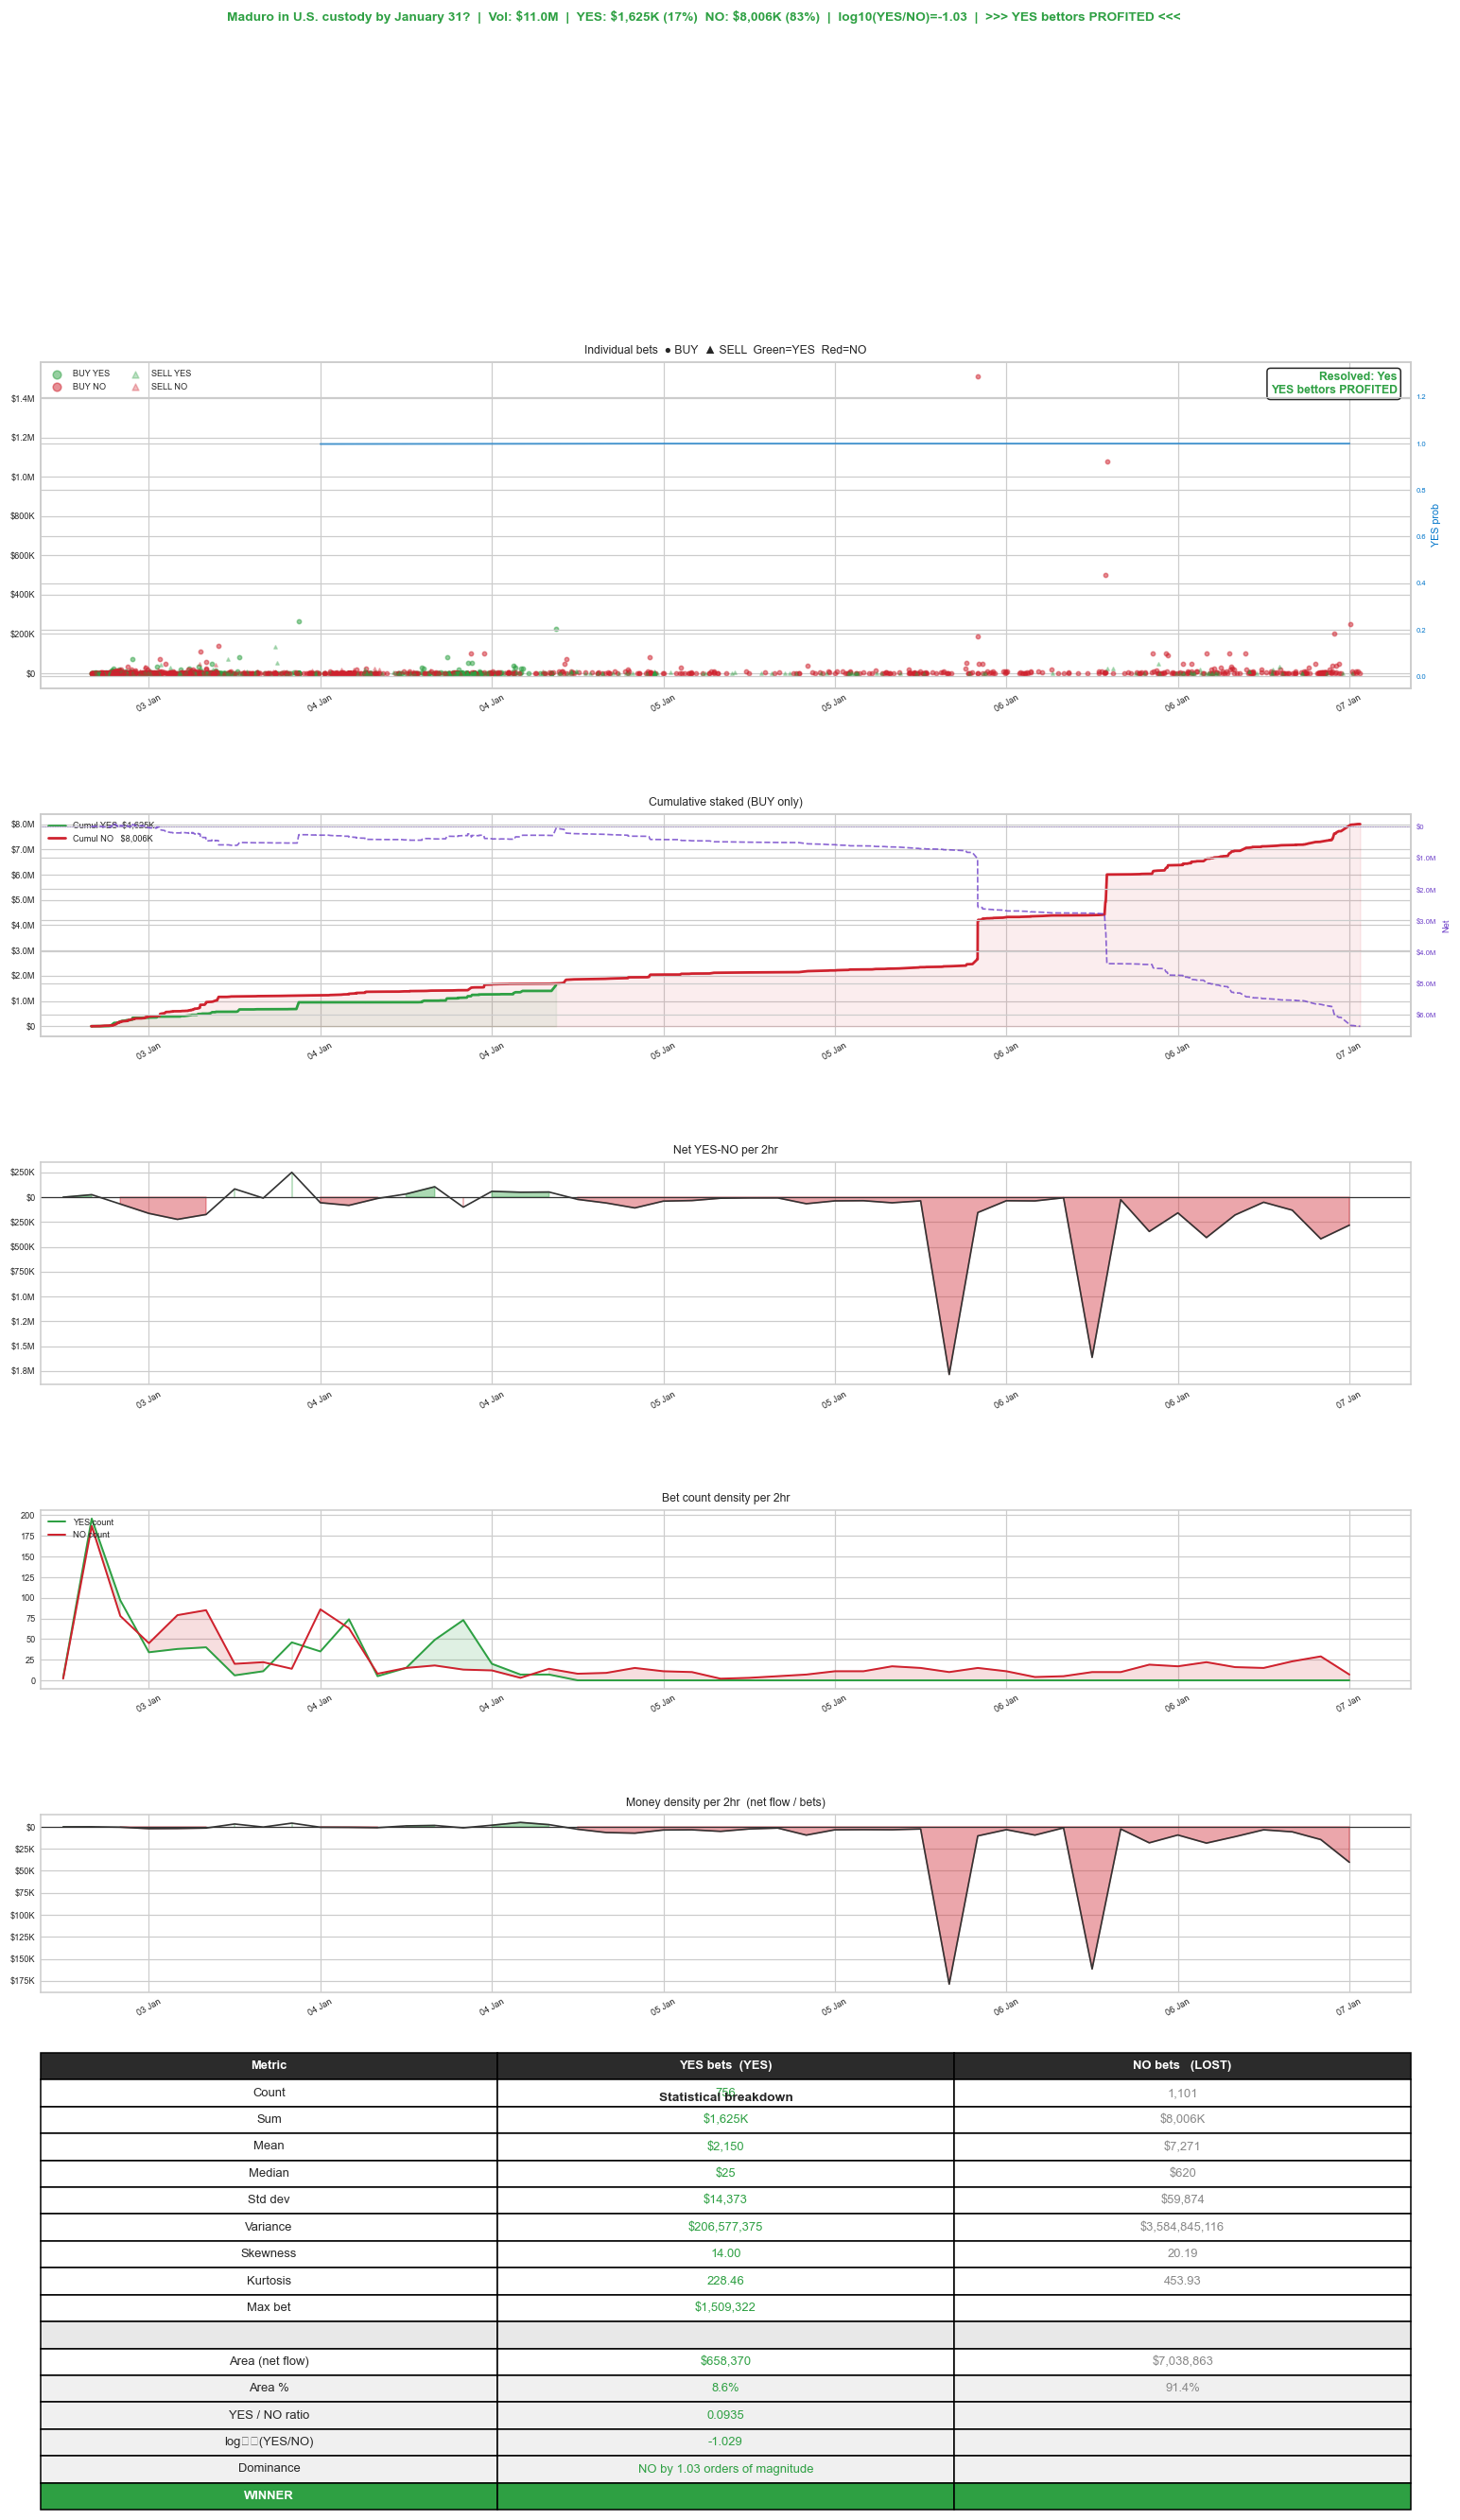

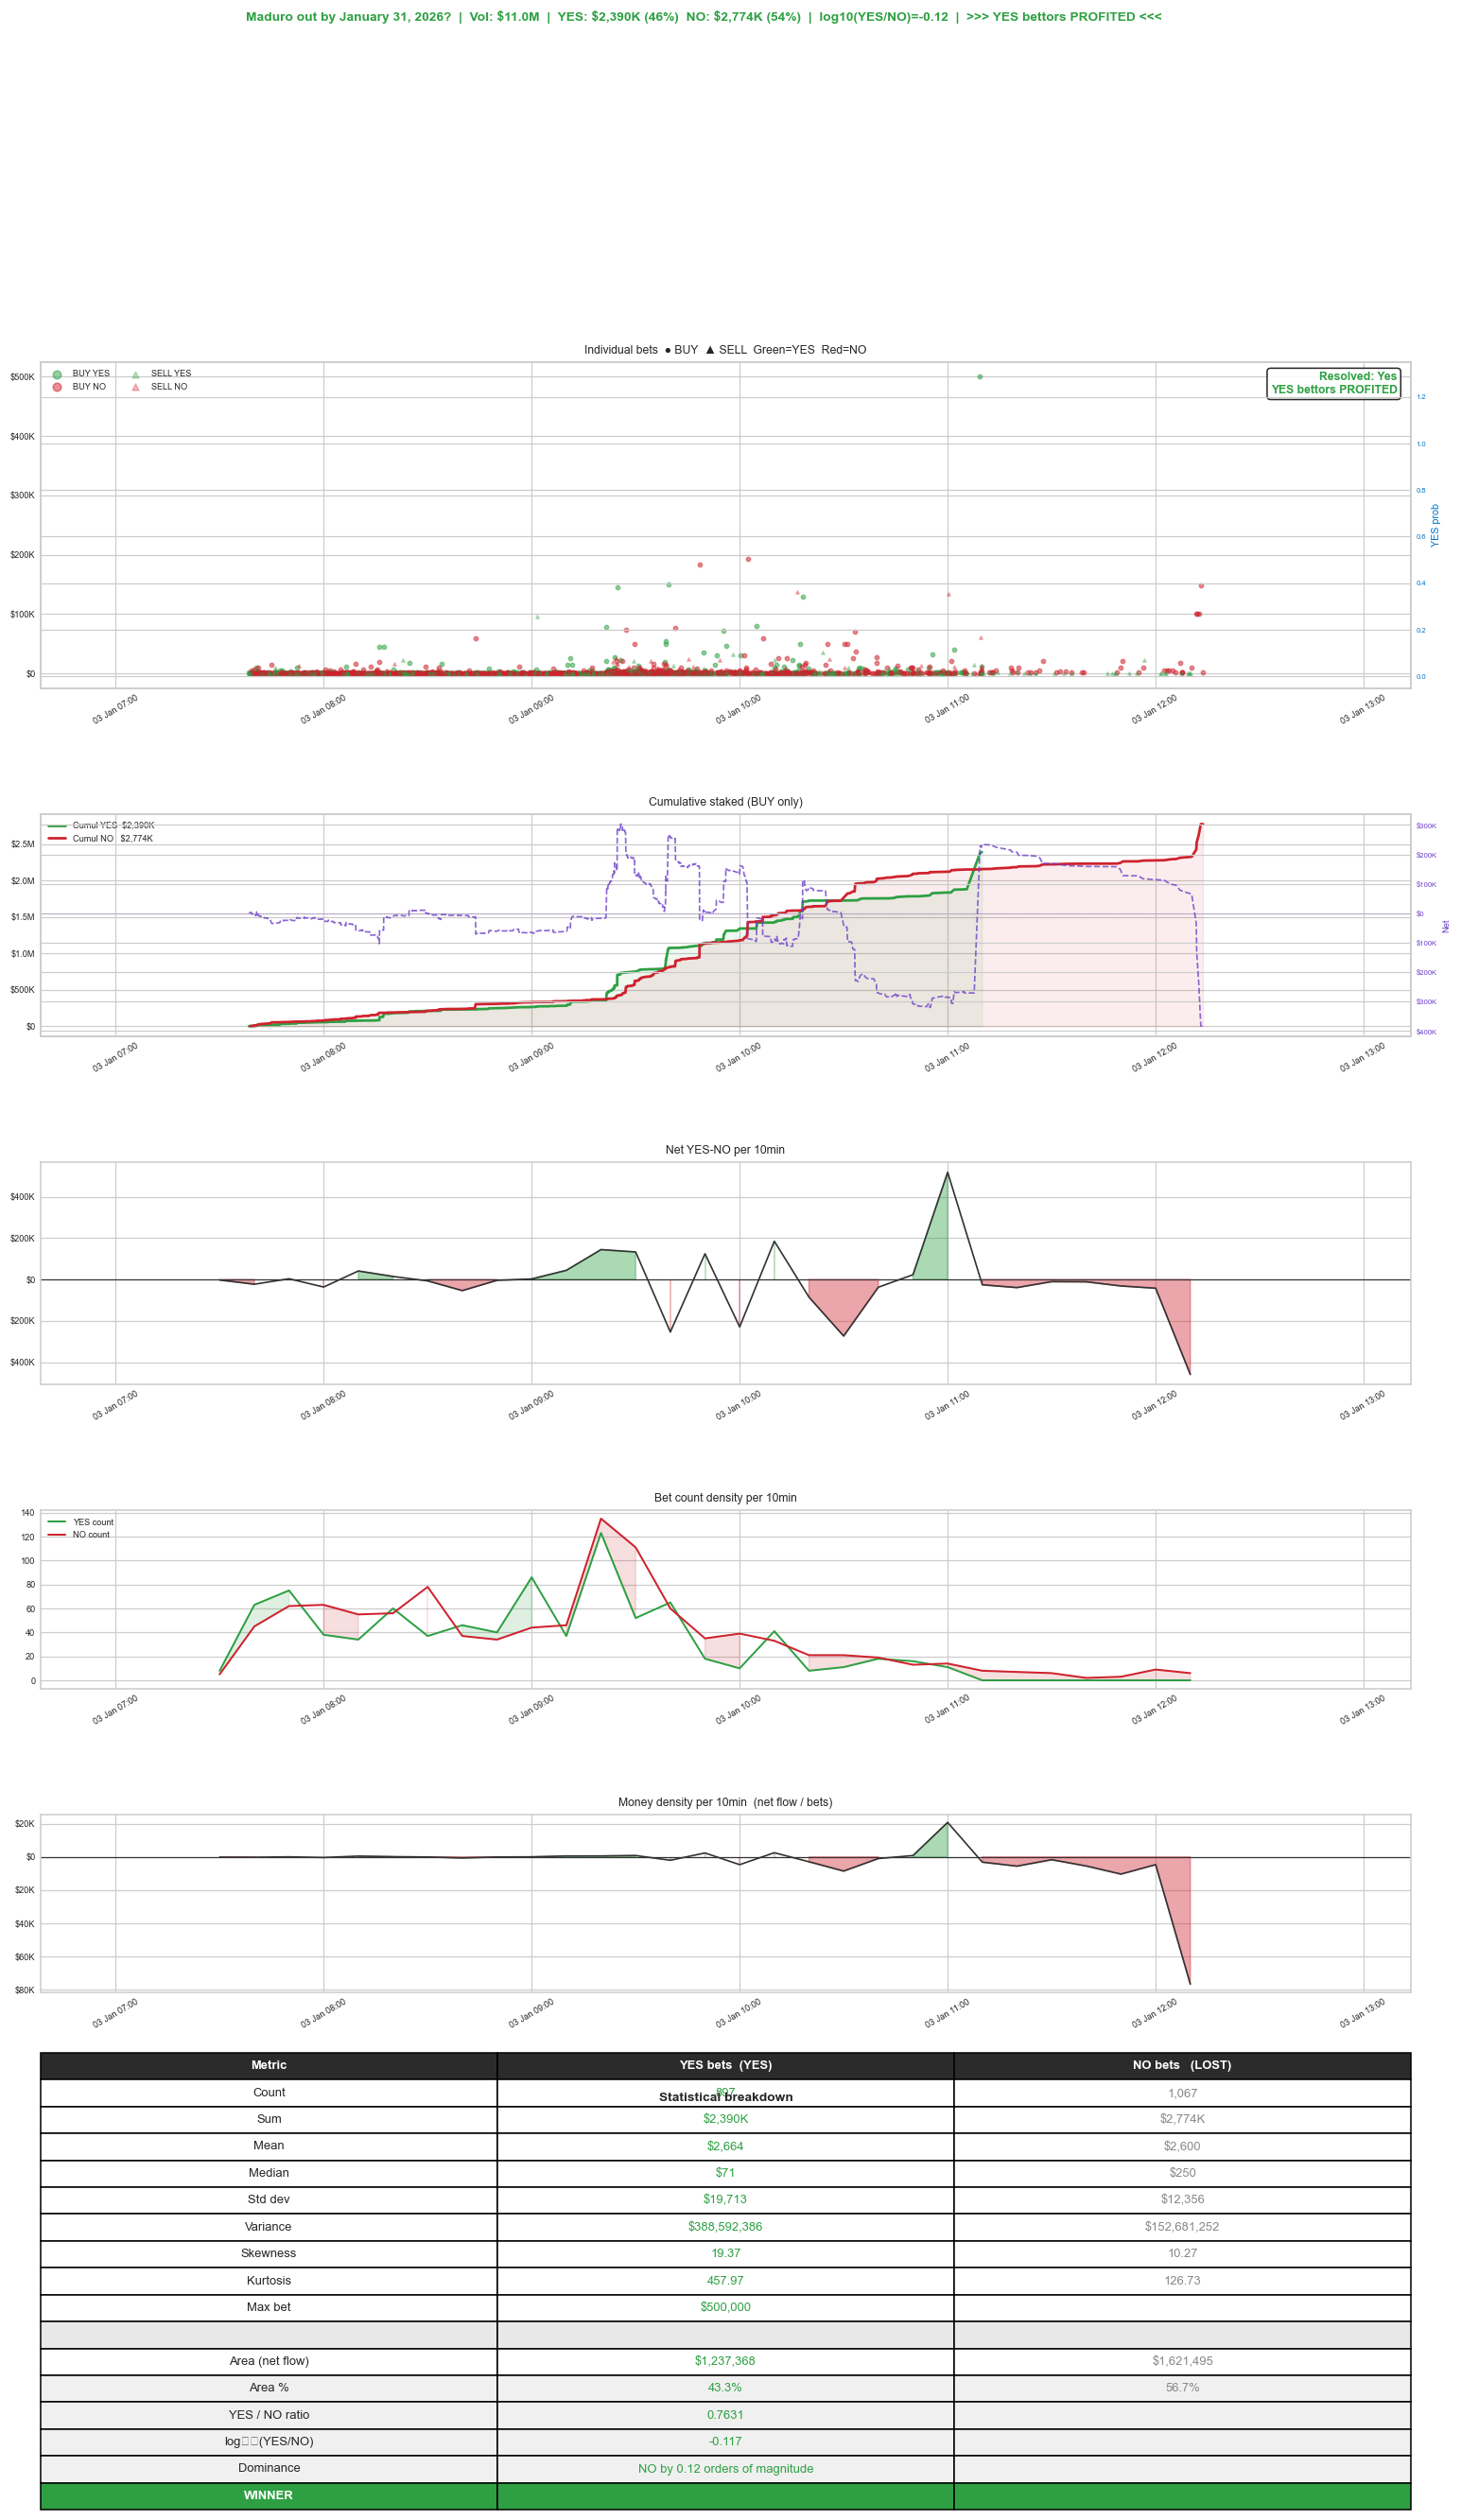

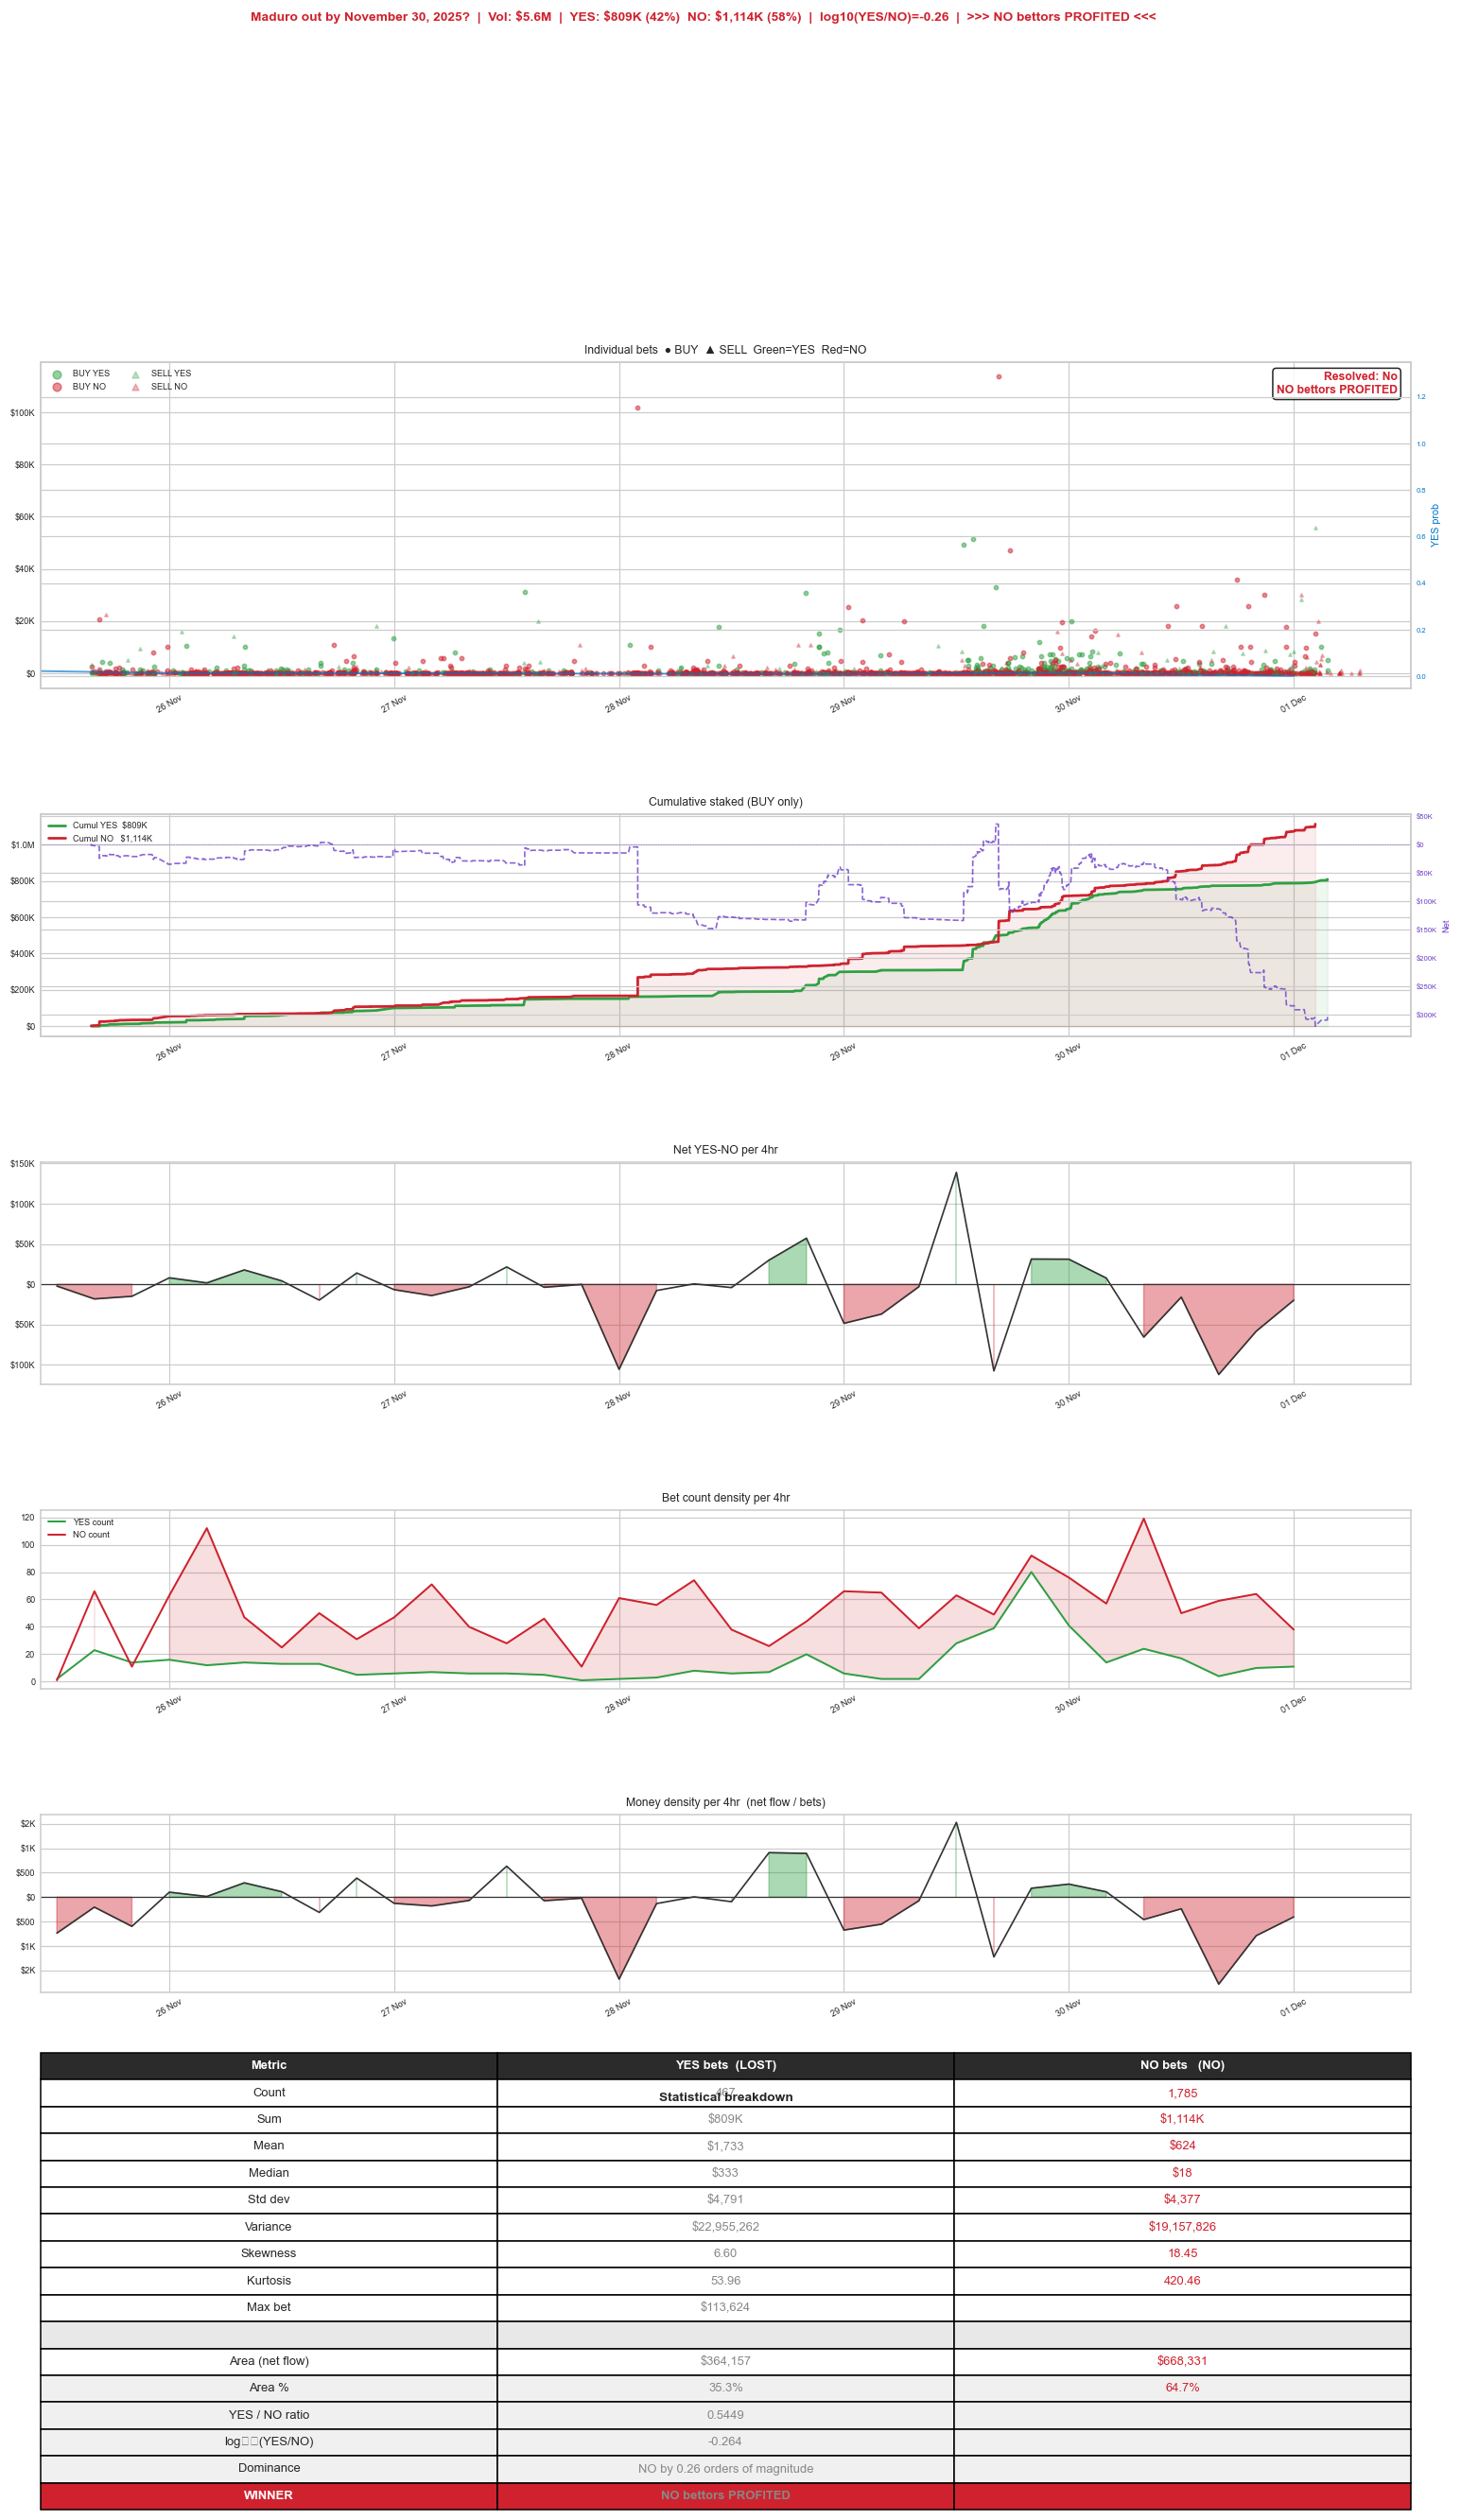

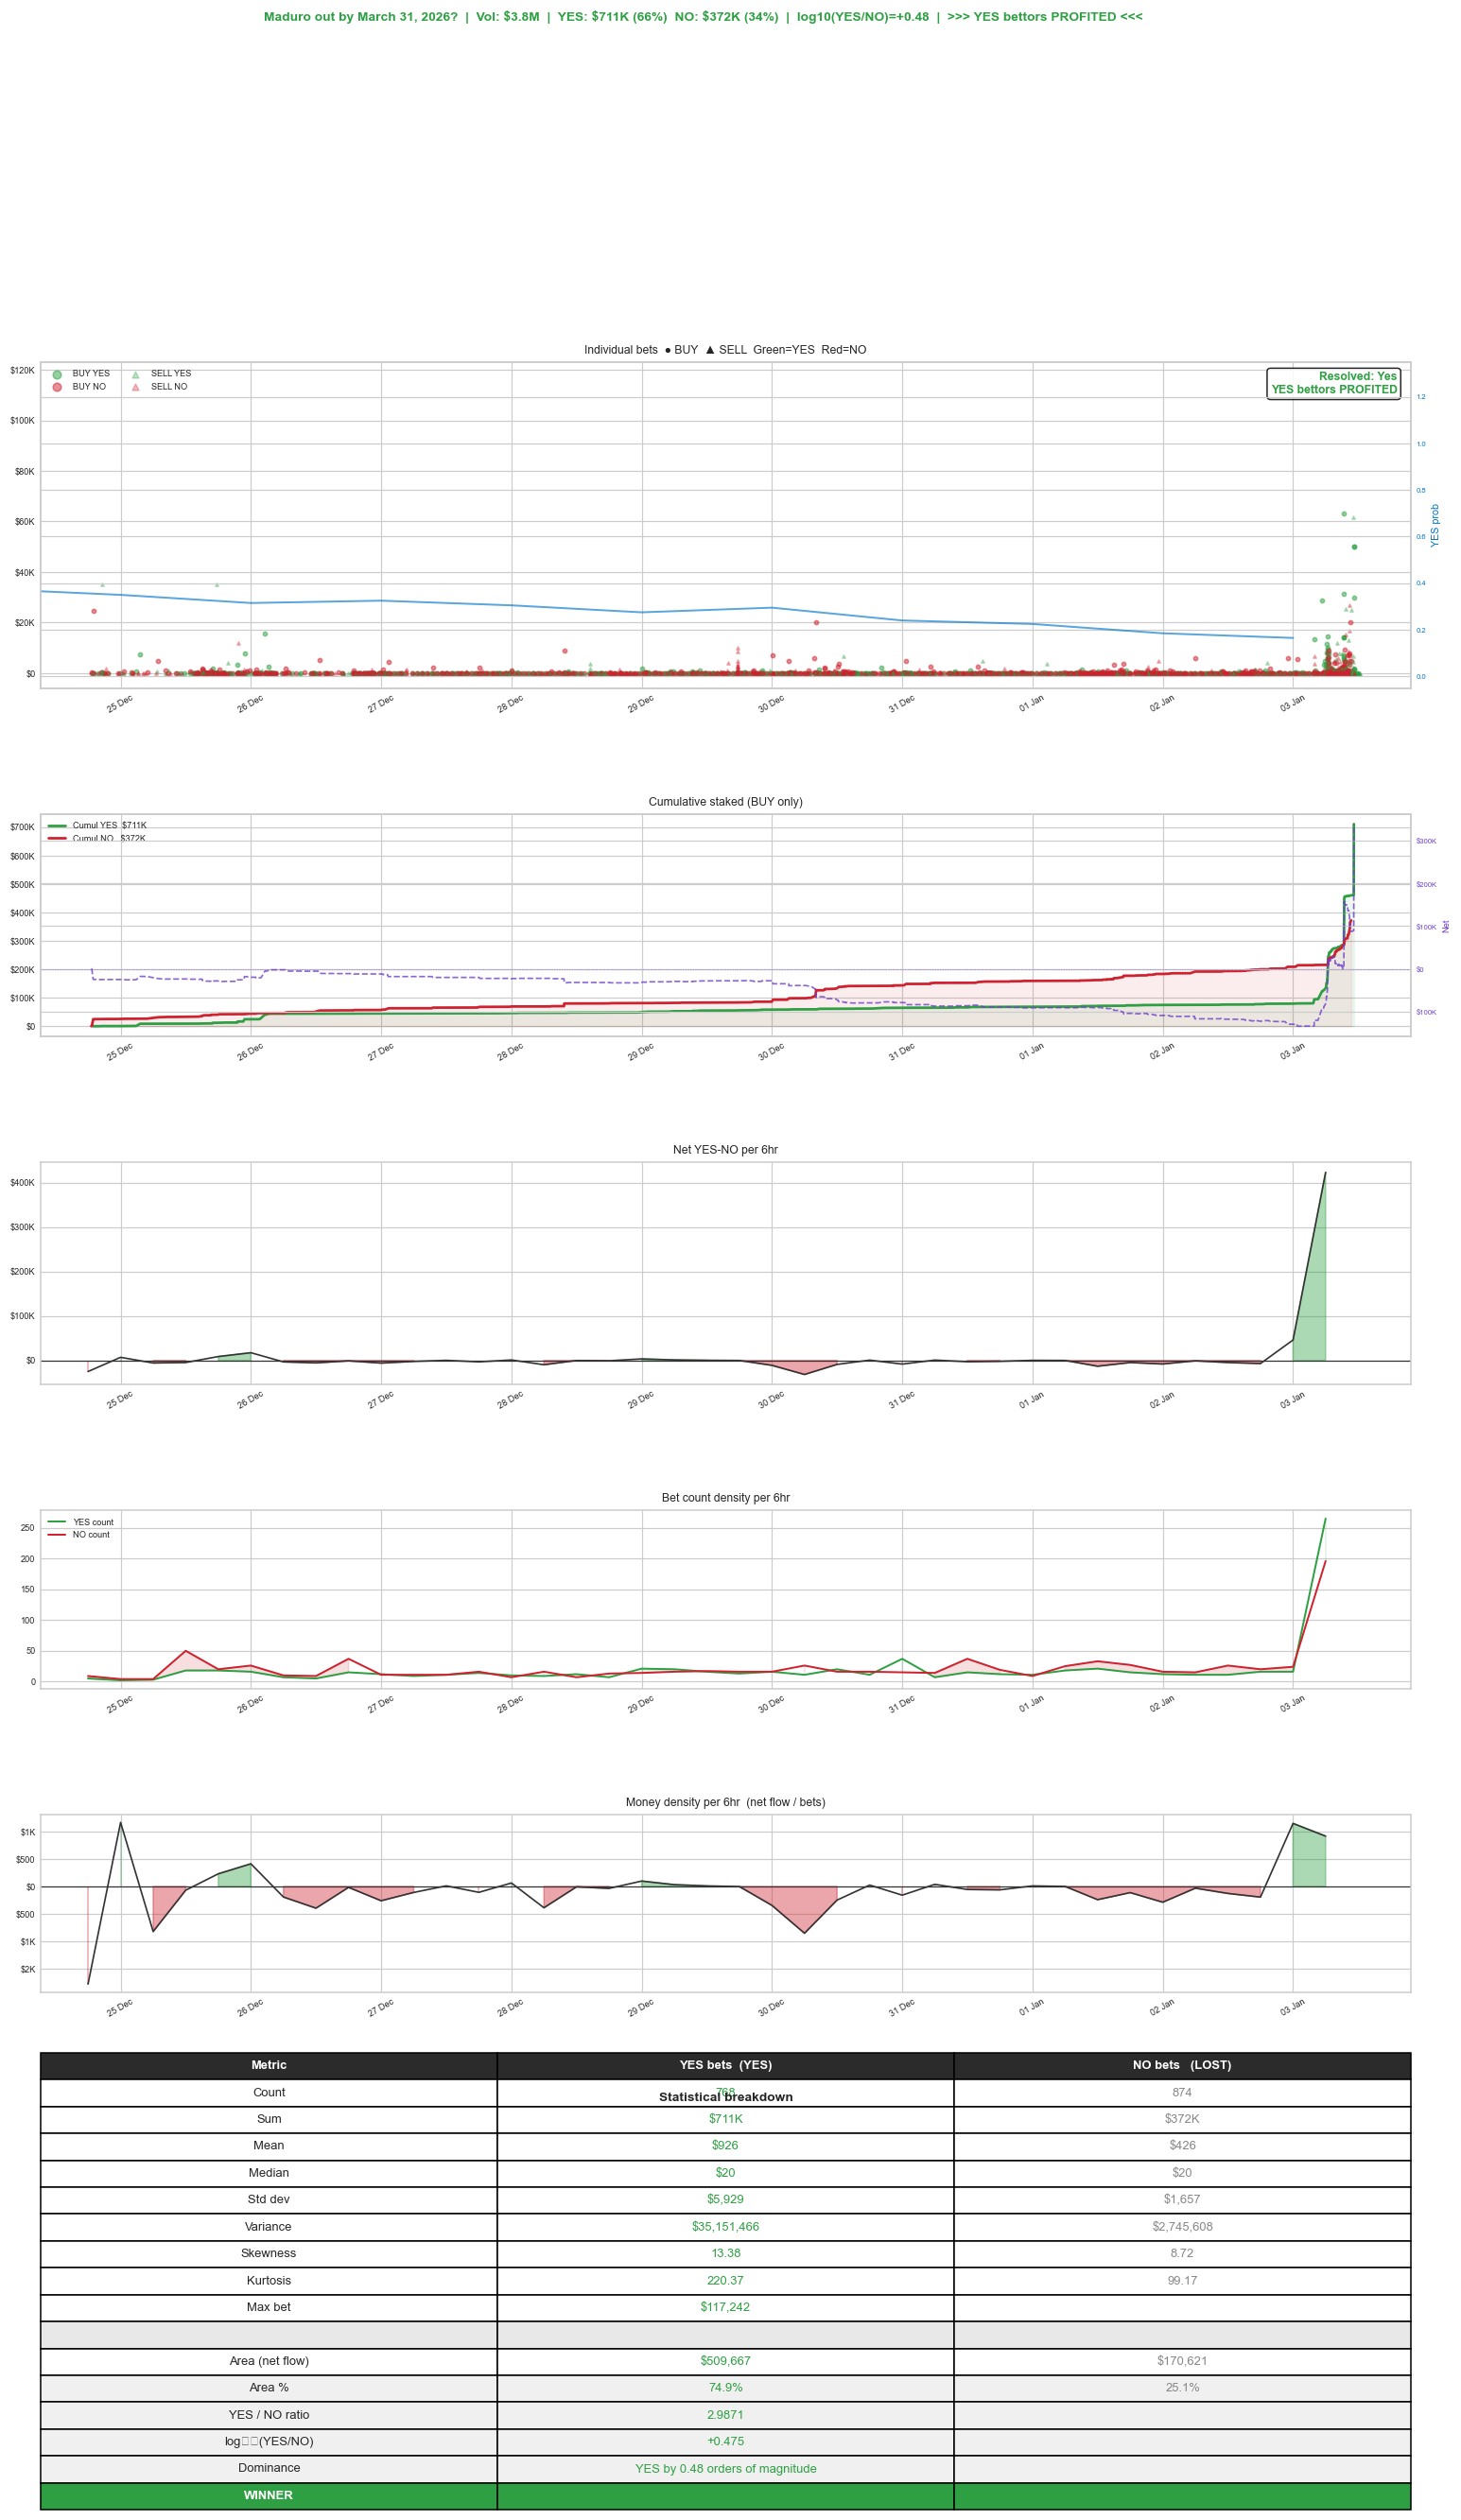

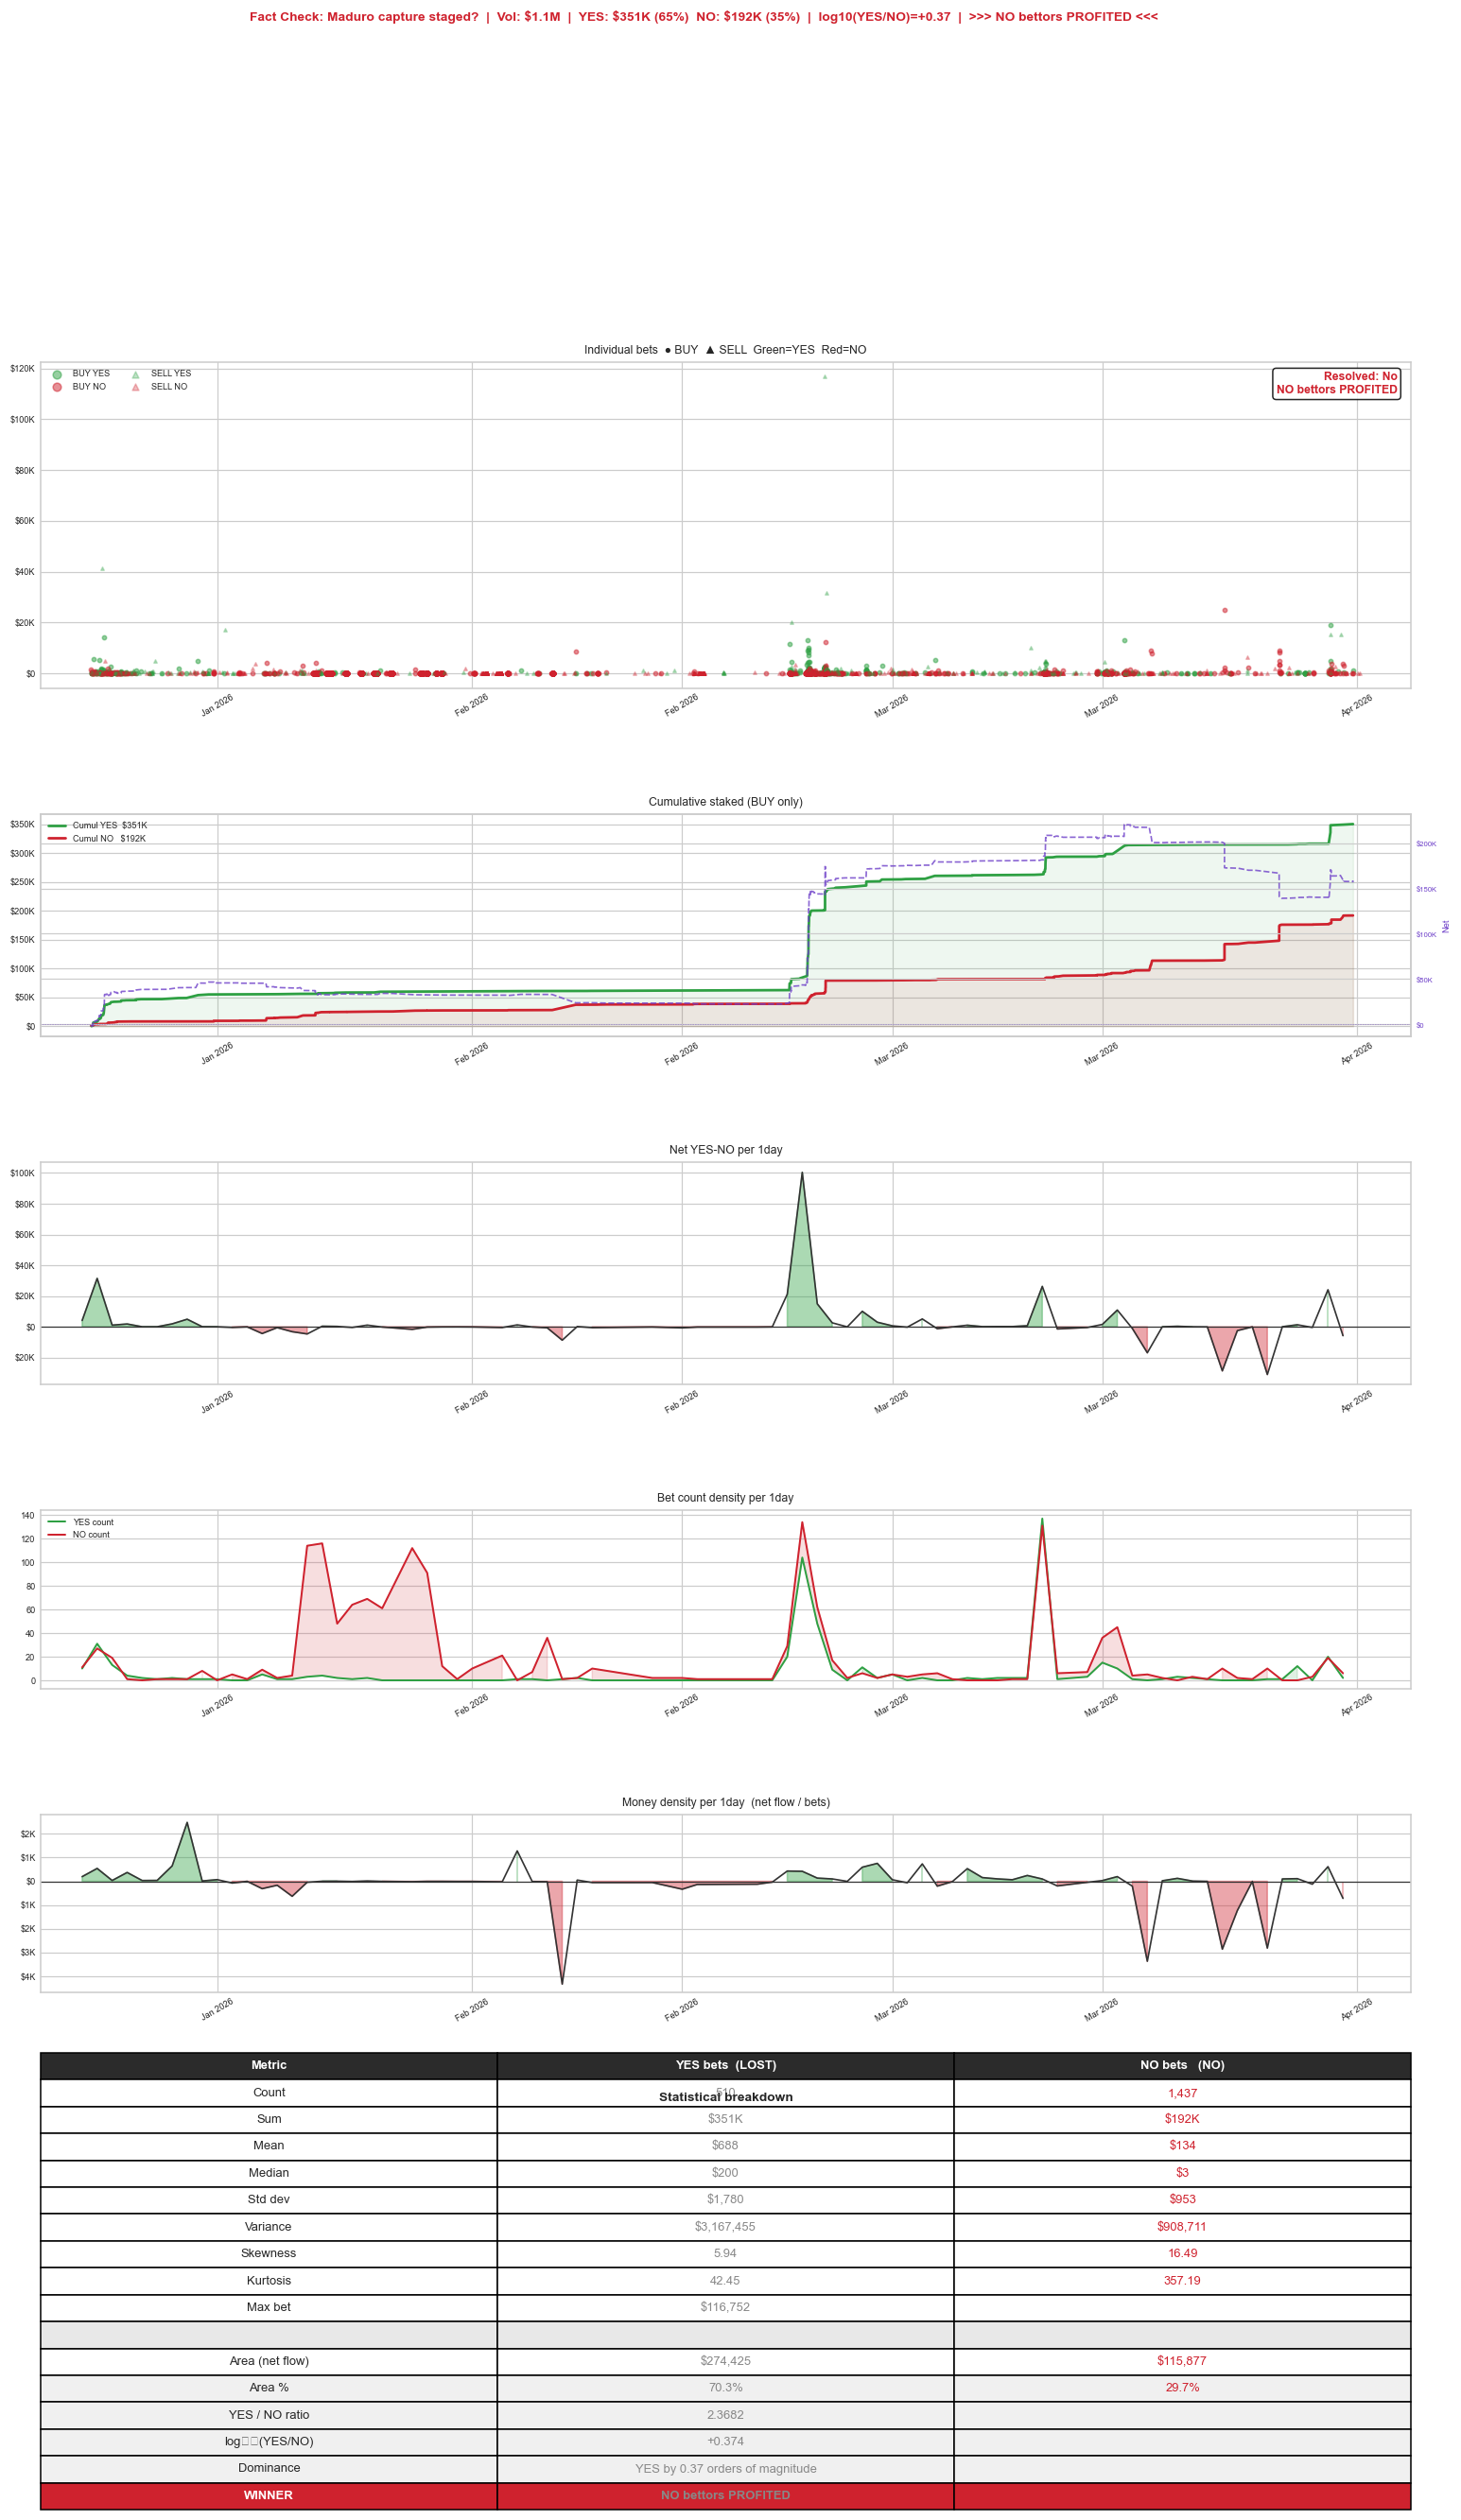

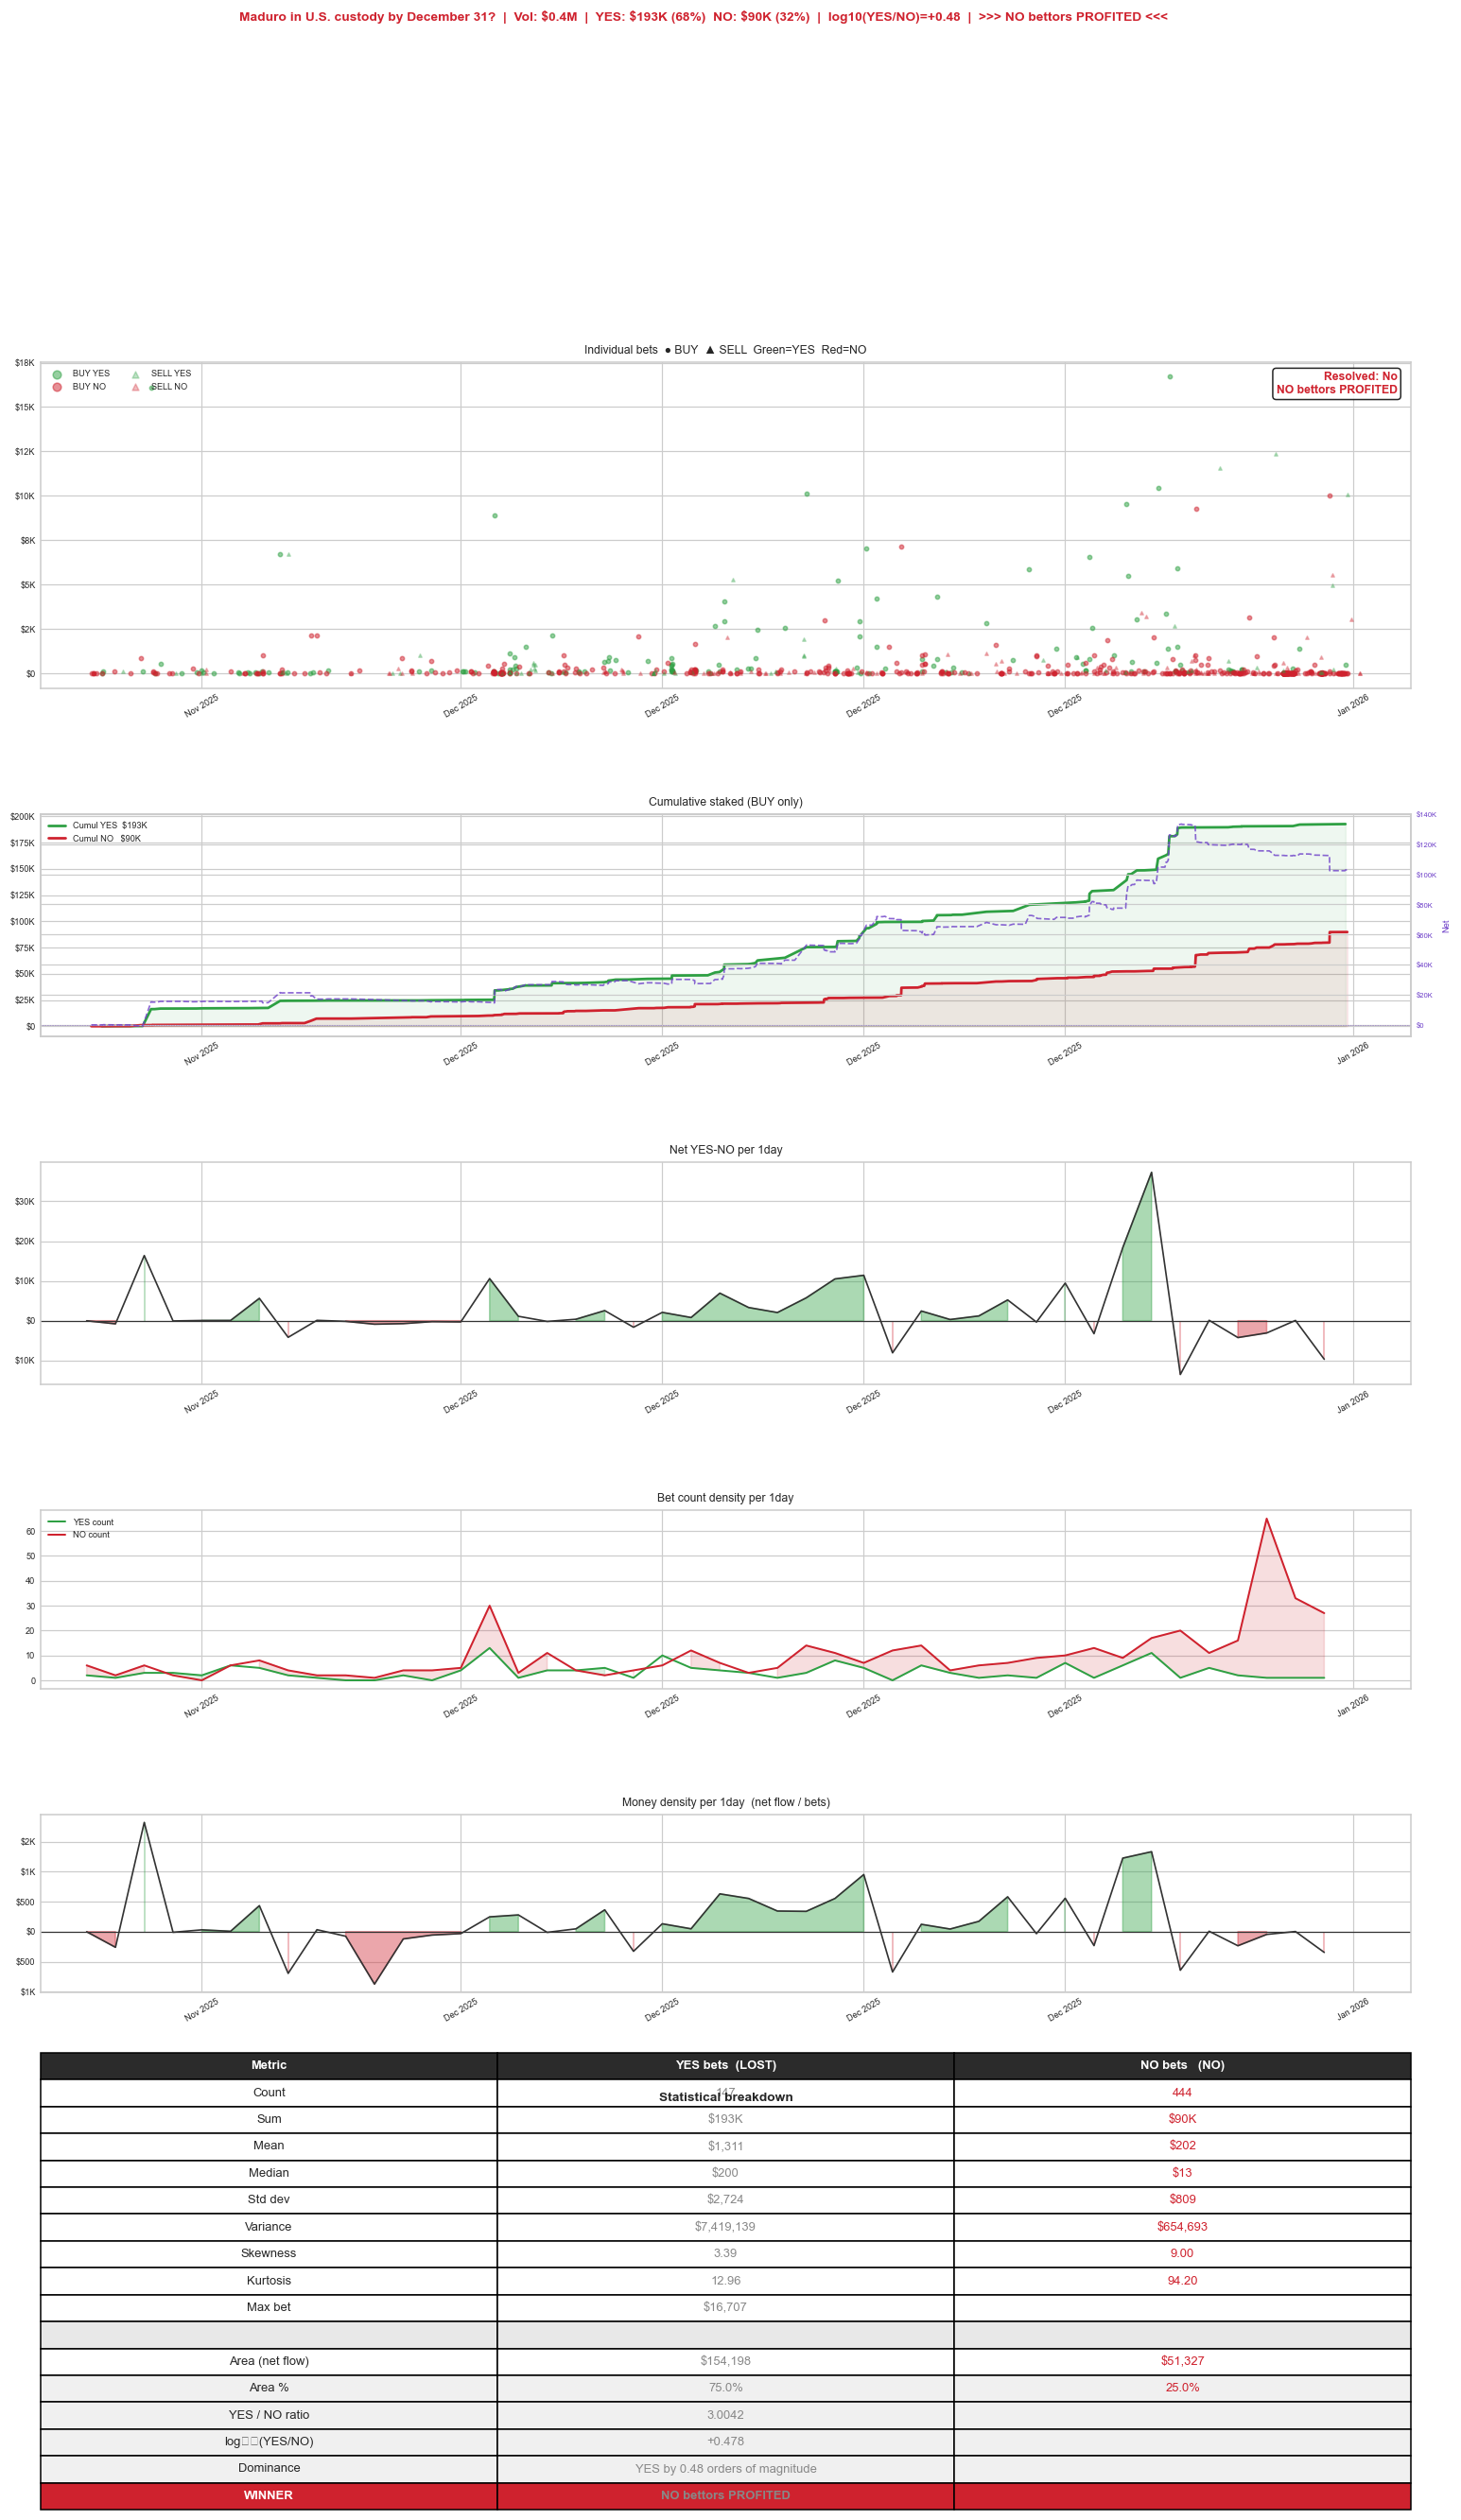

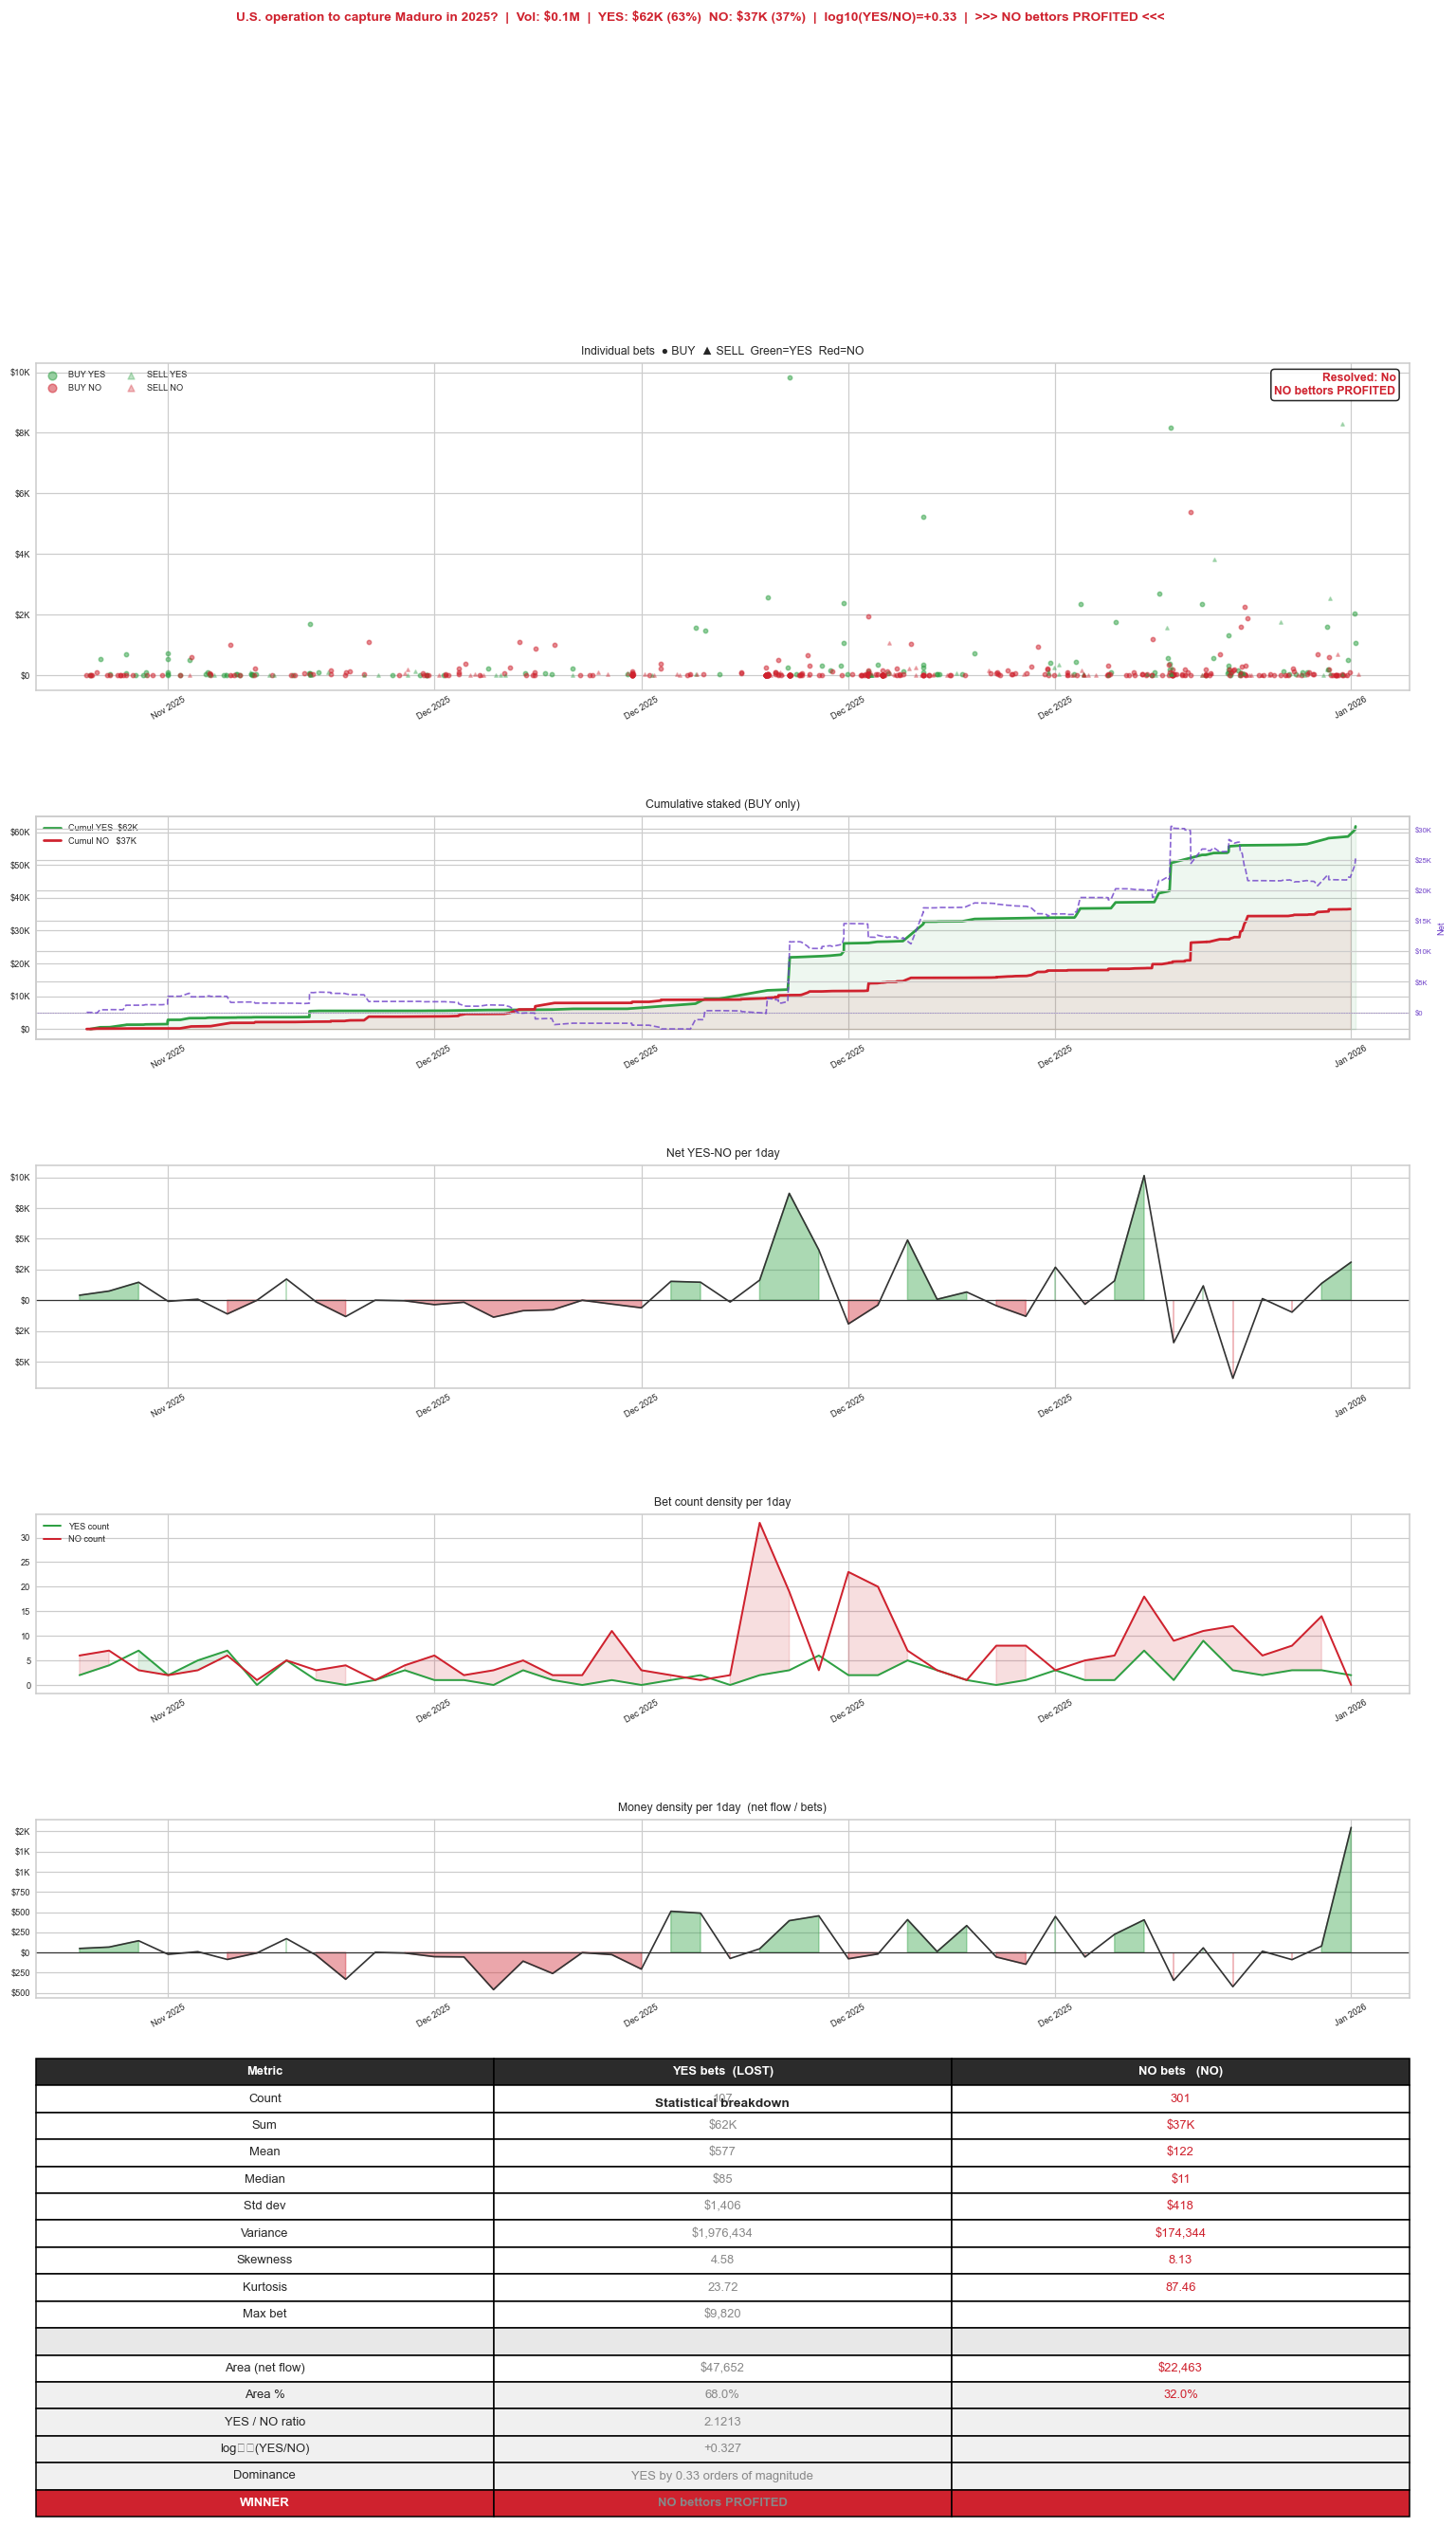

In [2]:
# Sort by volume descending
metas = [(load_meta(f), f) for f in folders]
metas.sort(key=lambda x: x[0].get('volume_m',0), reverse=True)

summary_rows = []  # collect for final comparison table

for meta, folder in metas:
    question   = meta.get('question','?')
    resolution = meta.get('resolution','?')
    vol_m      = meta.get('volume_m', 0)
    yes_won    = (resolution == 'Yes')
    c_res      = C_YES if yes_won else C_NO
    winner     = 'YES' if yes_won else 'NO'

    tr = load_tr(folder)
    ph = load_ph(folder)
    if tr.is_empty(): continue

    yes_buy  = tr.filter((pl.col('side')=='BUY') &(pl.col('outcome')=='Yes'))
    no_buy   = tr.filter((pl.col('side')=='BUY') &(pl.col('outcome')=='No'))
    yes_sell = tr.filter((pl.col('side')=='SELL')&(pl.col('outcome')=='Yes'))
    no_sell  = tr.filter((pl.col('side')=='SELL')&(pl.col('outcome')=='No'))
    buys     = tr.filter(pl.col('side')=='BUY')

    ys = np.abs(yes_buy['size'].to_numpy()) if not yes_buy.is_empty() else np.array([])
    ns = np.abs(no_buy['size'].to_numpy())  if not no_buy.is_empty()  else np.array([])

    yes_vol = float(ys.sum()) if len(ys) else 0
    no_vol  = float(ns.sum()) if len(ns) else 0
    total_s = yes_vol + no_vol
    yes_pct = 100*yes_vol/total_s if total_s else 0
    max_bet = float(tr['size'].max() or 0)

    ts_min = int(tr['timestamp'].min())
    ts_max = int(tr['timestamp'].max())
    span_s = ts_max - ts_min
    span_d = span_s / 86400
    pad    = timedelta(seconds=max(span_s*0.04, 3600))
    xlim   = (datetime.fromtimestamp(ts_min)-pad, datetime.fromtimestamp(ts_max)+pad)
    bsecs  = min(NICE, key=lambda x: abs(x-max(span_s/30,60)))
    blbl   = NLAB.get(bsecs,'?')
    dfmt   = mdates.DateFormatter('%d %b %H:%M' if span_d<1 else '%d %b' if span_d<30 else '%b %Y')
    ph_clip= ph.filter((pl.col('timestamp')>=ts_min-86400)&
                       (pl.col('timestamp')<=ts_max+86400)) if not ph.is_empty() else ph

    # Area calculations
    pos_area = neg_area = 0.0
    if not buys.is_empty():
        _b  = buys.with_columns(((pl.col('timestamp')//bsecs)*bsecs).alias('bt'))
        _yb = _b.filter(pl.col('outcome')=='Yes').group_by('bt').agg(pl.col('size').sum().alias('y'))
        _nb = _b.filter(pl.col('outcome')=='No' ).group_by('bt').agg(pl.col('size').sum().alias('n'))
        _jn = _yb.join(_nb, on='bt', how='full').fill_null(0)
        _net_arr = (_jn['y'] - _jn['n']).to_numpy()
        pos_area = float(_net_arr[_net_arr>0].sum())
        neg_area = float(abs(_net_arr[_net_arr<0].sum()))

    ratio_yes_no = pos_area / neg_area if neg_area > 0 else float('inf')
    log10_val    = math.log10(ratio_yes_no) if 0 < ratio_yes_no < float('inf') else float('nan')
    tot_area     = pos_area + neg_area

    def s(a): return f'${a.mean():,.0f}' if len(a) else 'n/a'
    def med(a): return f'${np.median(a):,.0f}' if len(a) else 'n/a'
    def std(a): return f'${a.std():,.0f}' if len(a) else 'n/a'
    def var(a): return f'${a.var():,.0f}' if len(a) else 'n/a'
    def skw(a): return f'{scipy_stats.skew(a):.2f}' if len(a)>2 else 'n/a'
    def kur(a): return f'{scipy_stats.kurtosis(a):.2f}' if len(a)>2 else 'n/a'

    summary_rows.append({
        'question': question[:55], 'resolution': resolution, 'vol_m': vol_m,
        'yes_area': pos_area, 'no_area': neg_area,
        'ratio_yes_no': ratio_yes_no, 'log10_yes_no': log10_val,
        'yes_skew': scipy_stats.skew(ys) if len(ys)>2 else float('nan'),
        'no_skew':  scipy_stats.skew(ns) if len(ns)>2 else float('nan'),
        'yes_std': ys.std() if len(ys) else 0,
        'no_std':  ns.std() if len(ns) else 0,
        'max_bet': max_bet, 'winner': winner,
    })

    # ── Figure: 5 chart panels + 1 stats table ───────────────────────────
    fig = plt.figure(figsize=(17, 26))
    gs  = fig.add_gridspec(6, 1, hspace=0.52,
                           height_ratios=[2.2, 1.5, 1.5, 1.2, 1.2, 2.2])
    ax1,ax2,ax3,ax4,ax5,ax6 = [fig.add_subplot(gs[i]) for i in range(6)]

    title = (f'{question}  |  Vol: ${vol_m:.1f}M  |  '
             f'YES: ${yes_vol/1e3:,.0f}K ({yes_pct:.0f}%)  '
             f'NO: ${no_vol/1e3:,.0f}K ({100-yes_pct:.0f}%)  |  '
             f'log10(YES/NO)={log10_val:+.2f}  |  >>> {winner} bettors PROFITED <<<')
    fig.suptitle(title, fontsize=9, fontweight='bold', color=c_res, y=1.01)

    # Panel 1 — scatter
    for df_s,col,mk,sz,al,lb in [(yes_buy,C_YES,'o',8,0.5,'BUY YES'),
                                   (no_buy,  C_NO, 'o',8,0.5,'BUY NO'),
                                   (yes_sell,C_YES,'^',5,0.3,'SELL YES'),
                                   (no_sell, C_NO, '^',5,0.3,'SELL NO')]:
        if not df_s.is_empty():
            ax1.scatter(df_s['date'].to_list(), df_s['size'].to_list(),
                        s=sz, alpha=al, color=col, marker=mk, label=lb, zorder=3)
    ax1.yaxis.set_major_formatter(fmt_usdc)
    ax1.set_title('Individual bets  ● BUY  ▲ SELL  Green=YES  Red=NO', fontsize=8)
    ax1.legend(markerscale=2, loc='upper left', ncol=2)
    ax1.set_xlim(*xlim)
    ax1.xaxis.set_major_formatter(dfmt)
    ax1.xaxis.set_major_locator(mdates.AutoDateLocator())
    plt.setp(ax1.xaxis.get_majorticklabels(), rotation=30)
    ax1.text(0.99,0.97, f'Resolved: {resolution}\n{winner} bettors PROFITED',
             transform=ax1.transAxes, ha='right', va='top', fontsize=8,
             fontweight='bold', color=c_res,
             bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.85))
    if not ph_clip.is_empty():
        ax1b = ax1.twinx()
        ax1b.plot(ph_clip['date'].to_list(), ph_clip['price'].to_list(),
                  color='#0075ca', lw=1.3, alpha=0.65, label='YES prob')
        ax1b.set_ylim(-0.05, 1.35)
        ax1b.set_ylabel('YES prob', color='#0075ca', fontsize=7)
        ax1b.tick_params(axis='y', colors='#0075ca', labelsize=5)
        ax1b.set_xlim(*xlim)

    # Panel 2 — cumulative
    yes_s = yes_buy.sort('date'); no_s = no_buy.sort('date')
    if not yes_s.is_empty():
        cy = np.cumsum(yes_s['size'].cast(pl.Float64).to_list())
        ax2.plot(yes_s['date'].to_list(), cy, color=C_YES, lw=1.8,
                 label=f'Cumul YES  ${yes_vol/1e3:,.0f}K')
        ax2.fill_between(yes_s['date'].to_list(), cy, 0, color=C_YES, alpha=0.08)
    if not no_s.is_empty():
        cn = np.cumsum(no_s['size'].cast(pl.Float64).to_list())
        ax2.plot(no_s['date'].to_list(), cn, color=C_NO, lw=1.8,
                 label=f'Cumul NO   ${no_vol/1e3:,.0f}K')
        ax2.fill_between(no_s['date'].to_list(), cn, 0, color=C_NO, alpha=0.08)
    both = pl.concat([yes_s.select(['date', pl.col('size').alias('net')]),
                      no_s.select(['date', (-pl.col('size')).alias('net')])]).sort('date')
    if not both.is_empty():
        cn2 = np.cumsum(both['net'].cast(pl.Float64).to_list())
        ax2b = ax2.twinx()
        ax2b.plot(both['date'].to_list(), cn2, color=C_NET, lw=1.1,
                  linestyle='--', alpha=0.8, label='Net')
        ax2b.axhline(0, color=C_NET, lw=0.4, linestyle=':')
        ax2b.yaxis.set_major_formatter(fmt_usdc)
        ax2b.set_ylabel('Net', color=C_NET, fontsize=6)
        ax2b.tick_params(axis='y', colors=C_NET, labelsize=5)
        ax2b.set_xlim(*xlim)
    ax2.yaxis.set_major_formatter(fmt_usdc)
    ax2.set_title('Cumulative staked (BUY only)', fontsize=8)
    ax2.legend(loc='upper left', fontsize=6)
    ax2.set_xlim(*xlim)
    ax2.xaxis.set_major_formatter(dfmt)
    ax2.xaxis.set_major_locator(mdates.AutoDateLocator())
    plt.setp(ax2.xaxis.get_majorticklabels(), rotation=30)

    # Panels 3-5 from bucket data
    if not buys.is_empty():
        buys_b = buys.with_columns(((pl.col('timestamp')//bsecs)*bsecs).alias('bt'))
        yb2 = buys_b.filter(pl.col('outcome')=='Yes').group_by('bt').agg(
            pl.col('size').sum().alias('y'), pl.len().alias('yc')).sort('bt')
        nb2 = buys_b.filter(pl.col('outcome')=='No').group_by('bt').agg(
            pl.col('size').sum().alias('n'), pl.len().alias('nc')).sort('bt')
        all_ts = sorted(set(yb2['bt'].to_list()+nb2['bt'].to_list()))
        ym2 = dict(zip(yb2['bt'].to_list(), yb2['y'].to_list()))
        nm2 = dict(zip(nb2['bt'].to_list(), nb2['n'].to_list()))
        ycm = dict(zip(yb2['bt'].to_list(), yb2['yc'].to_list()))
        ncm = dict(zip(nb2['bt'].to_list(), nb2['nc'].to_list()))
        bkts   = [datetime.fromtimestamp(t) for t in all_ts]
        net_v  = np.array([ym2.get(t,0)-nm2.get(t,0) for t in all_ts])
        ycs    = [ycm.get(t,0) for t in all_ts]
        ncs    = [ncm.get(t,0) for t in all_ts]
        tb     = [a+b for a,b in zip(ycs,ncs)]
        mdens  = np.array([nv/t if t>0 else 0 for nv,t in zip(net_v,tb)])

        ax3.plot(bkts, net_v, color='#333', lw=1.1, zorder=4)
        ax3.fill_between(bkts, net_v, 0, where=net_v>=0, color=C_YES, alpha=0.4)
        ax3.fill_between(bkts, net_v, 0, where=net_v<0,  color=C_NO,  alpha=0.4)
        ax3.axhline(0, color='#333', lw=0.8)
        ax3.yaxis.set_major_formatter(fmt_usdc)
        ax3.set_title(f'Net YES-NO per {blbl}', fontsize=8)
        ax3.set_xlim(*xlim)
        ax3.xaxis.set_major_formatter(dfmt)
        ax3.xaxis.set_major_locator(mdates.AutoDateLocator())
        plt.setp(ax3.xaxis.get_majorticklabels(), rotation=30)

        ax4.plot(bkts, ycs, color=C_YES, lw=1.3, label='YES count')
        ax4.plot(bkts, ncs, color=C_NO,  lw=1.3, label='NO count')
        ax4.fill_between(bkts, ycs, ncs,
                         where=[y>=n for y,n in zip(ycs,ncs)], color=C_YES, alpha=0.15)
        ax4.fill_between(bkts, ycs, ncs,
                         where=[y<n  for y,n in zip(ycs,ncs)], color=C_NO,  alpha=0.15)
        ax4.set_title(f'Bet count density per {blbl}', fontsize=8)
        ax4.legend(loc='upper left', fontsize=6)
        ax4.set_xlim(*xlim)
        ax4.xaxis.set_major_formatter(dfmt)
        ax4.xaxis.set_major_locator(mdates.AutoDateLocator())
        plt.setp(ax4.xaxis.get_majorticklabels(), rotation=30)

        ax5.plot(bkts, mdens, color='#333', lw=1.1, zorder=4)
        ax5.fill_between(bkts, mdens, 0, where=mdens>=0, color=C_YES, alpha=0.4)
        ax5.fill_between(bkts, mdens, 0, where=mdens<0,  color=C_NO,  alpha=0.4)
        ax5.axhline(0, color='#333', lw=0.8)
        ax5.yaxis.set_major_formatter(fmt_usdc)
        ax5.set_title(f'Money density per {blbl}  (net flow / bets)', fontsize=8)
        ax5.set_xlim(*xlim)
        ax5.xaxis.set_major_formatter(dfmt)
        ax5.xaxis.set_major_locator(mdates.AutoDateLocator())
        plt.setp(ax5.xaxis.get_majorticklabels(), rotation=30)

    # Panel 6 — stats table
    ax6.axis('off')

    yes_label = f'YES bets  ({winner if yes_won else "LOST"})'
    no_label  = f'NO bets   ({winner if not yes_won else "LOST"})'

    tbl_data = [
        ['Metric',          yes_label,                    no_label],
        ['Count',           f'{len(ys):,}',               f'{len(ns):,}'],
        ['Sum',             f'${yes_vol/1e3:,.0f}K',      f'${no_vol/1e3:,.0f}K'],
        ['Mean',            s(ys),                        s(ns)],
        ['Median',          med(ys),                      med(ns)],
        ['Std dev',         std(ys),                      std(ns)],
        ['Variance',        var(ys),                      var(ns)],
        ['Skewness',        skw(ys),                      skw(ns)],
        ['Kurtosis',        kur(ys),                      kur(ns)],
        ['Max bet',         f'${max_bet:,.0f}',           ''],
        ['',                '',                           ''],
        ['Area (net flow)', f'${pos_area:,.0f}',          f'${neg_area:,.0f}'],
        ['Area %',          f'{100*pos_area/tot_area:.1f}%' if tot_area else 'n/a',
                            f'{100*neg_area/tot_area:.1f}%' if tot_area else 'n/a'],
        ['YES / NO ratio',  f'{ratio_yes_no:.4f}',        ''],
        ['log₁₀(YES/NO)',
                            f'{log10_val:+.3f}',          ''],
        ['Dominance',       f'{"YES" if not math.isnan(log10_val) and log10_val>0 else "NO"} '
                            f'by {abs(log10_val):.2f} orders of magnitude', ''],
        ['WINNER',          f'{winner} bettors PROFITED', ''],
    ]

    col_labels = tbl_data[0]
    cell_text  = tbl_data[1:]

    tbl = ax6.table(
        cellText=cell_text,
        colLabels=col_labels,
        loc='center',
        cellLoc='center',
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(8.5)
    tbl.scale(1, 1.55)

    # Colour header and winner row
    for j in range(3):
        tbl[(0, j)].set_facecolor('#2b2b2b')
        tbl[(0, j)].set_text_props(color='white', fontweight='bold')
    for i, row in enumerate(cell_text):
        if row[0] == 'WINNER':
            for j in range(3):
                tbl[(i+1, j)].set_facecolor(c_res)
                tbl[(i+1, j)].set_text_props(color='white', fontweight='bold')
        elif row[0] in ('log₁₀(YES/NO)', 'Dominance', 'Area %', 'YES / NO ratio'):
            for j in range(3):
                tbl[(i+1, j)].set_facecolor('#f0f0f0')
        elif row[0] == '':
            for j in range(3):
                tbl[(i+1, j)].set_facecolor('#e8e8e8')
                tbl[(i+1, j)].set_text_props(color='#e8e8e8')
    # Colour YES/NO data columns
    for i in range(1, len(cell_text)+1):
        tbl[(i, 1)].set_text_props(color=C_YES if yes_won else '#888')
        tbl[(i, 2)].set_text_props(color=C_NO  if not yes_won else '#888')

    ax6.set_title('Statistical breakdown', fontsize=9, fontweight='bold', pad=12)

    plt.tight_layout()
    plt.show()
    plt.close(fig)


## Summary comparison — all 18 markets ranked by log₁₀(YES/NO area ratio)


Market                                                   Res      YES area      NO area   YES/NO   log10   Dominant  YES skew   NO skew
-------------------------------------------------------------------------------------------------------------------------------------------------
Russia x Ukraine ceasefire by May 31, 2026?              Yes  $    48,042 $113,119,995    0.000   -3.37        NO      +5.94    +11.26
Khamenei out as Supreme Leader of Iran by February 28?   Yes  $    90,170 $13,881,708    0.006   -2.19        NO     +12.92    +11.81
US forces enter Iran by April 30?                        Yes  $   782,282 $32,901,051    0.024   -1.62        NO     +10.36    +11.49
Maduro in U.S. custody by January 31?                    Yes  $   658,370 $ 7,038,863    0.094   -1.03        NO     +14.00    +20.19
US x Iran ceasefire by April 7?                          Yes  $ 5,216,515 $45,090,696    0.116   -0.94        NO      +8.88    +26.70
Maduro out by November 30, 2025?              

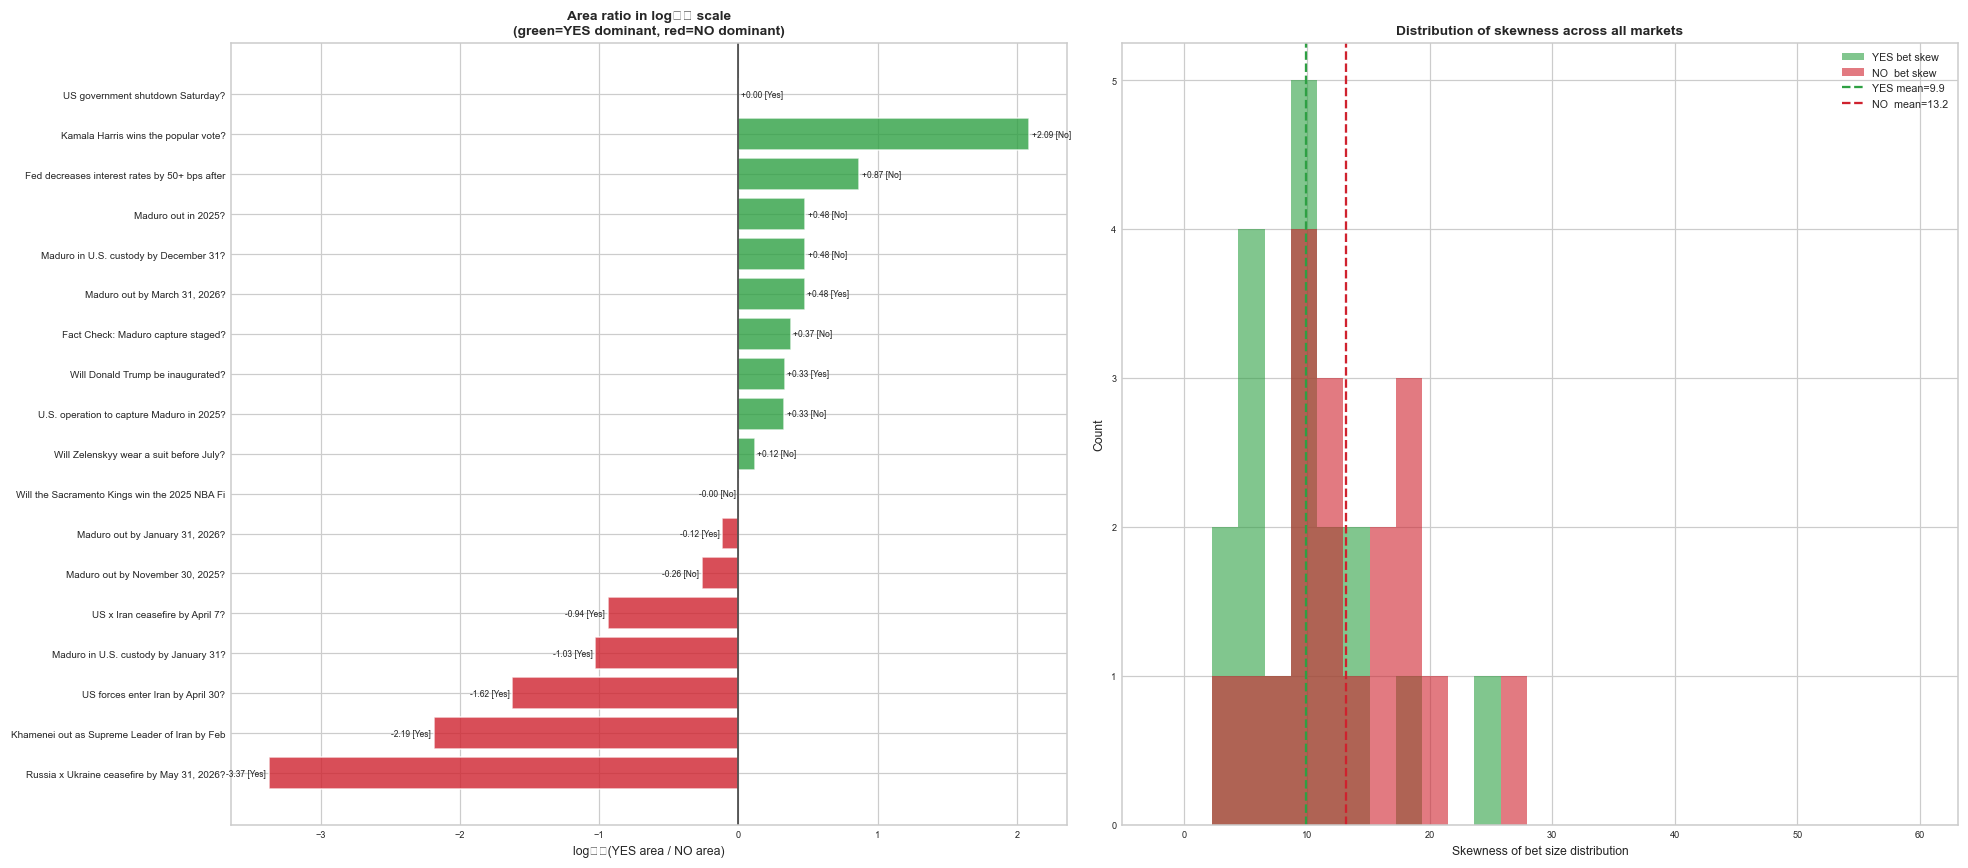

In [3]:
import matplotlib.patches as mpatches

# Sort by log10 ascending (most NO-dominant first)
summary_rows.sort(key=lambda r: r.get('log10_yes_no', 0))

print(f'\n{"Market":<56} {"Res":<4} {"YES area":>12} {"NO area":>12} {"YES/NO":>8} {"log10":>7} {"Dominant":>10} {"YES skew":>9} {"NO skew":>9}')
print('-'*145)
for r in summary_rows:
    dom  = 'YES' if r['log10_yes_no'] > 0 else 'NO '
    orders = abs(r['log10_yes_no']) if not math.isnan(r['log10_yes_no']) else 0
    print(f'{r["question"]:<56} {r["resolution"]:<4} '
          f'${r["yes_area"]:>10,.0f} ${r["no_area"]:>10,.0f} '
          f'{r["ratio_yes_no"]:>8.3f} {r["log10_yes_no"]:>+7.2f} '
          f'{dom:>10} {r["yes_skew"]:>+9.2f} {r["no_skew"]:>+9.2f}')

# Chart: log10 bar chart
fig,axes = plt.subplots(1,2,figsize=(18,8))

ax = axes[0]
labels = [r['question'][:45] for r in summary_rows]
vals   = [r['log10_yes_no'] if not math.isnan(r.get('log10_yes_no',float('nan'))) else 0 for r in summary_rows]
res    = [r['resolution'] for r in summary_rows]
colors = [C_YES if v>0 else C_NO for v in vals]
y = range(len(labels))
ax.barh(list(y), vals, color=colors, alpha=0.8, edgecolor='white')
ax.axvline(0,color='#333',lw=1.0)
ax.set_yticks(list(y)); ax.set_yticklabels(labels, fontsize=6.5)
ax.set_xlabel('log₁₀(YES area / NO area)')
ax.set_title('Area ratio in log₁₀ scale\n(green=YES dominant, red=NO dominant)', fontweight='bold')
for i,(v,r) in enumerate(zip(vals,res)):
    ax.text(v+(0.02 if v>=0 else -0.02),i,f'{v:+.2f} [{r}]',va='center',
            ha='left' if v>=0 else 'right',fontsize=5.5)

ax2 = axes[1]
yes_skews=[r['yes_skew'] for r in summary_rows if not math.isnan(r.get('yes_skew',float('nan')))]
no_skews =[r['no_skew']  for r in summary_rows if not math.isnan(r.get('no_skew', float('nan')))]
bins=np.linspace(-2,60,30)
ax2.hist(yes_skews,bins=bins,color=C_YES,alpha=0.6,label='YES bet skew')
ax2.hist(no_skews, bins=bins,color=C_NO, alpha=0.6,label='NO  bet skew')
ax2.set_xlabel('Skewness of bet size distribution')
ax2.set_ylabel('Count')
ax2.set_title('Distribution of skewness across all markets', fontweight='bold')
ax2.legend()
ax2.axvline(np.mean(yes_skews),color=C_YES,lw=1.5,linestyle='--',label=f'YES mean={np.mean(yes_skews):.1f}')
ax2.axvline(np.mean(no_skews), color=C_NO, lw=1.5,linestyle='--',label=f'NO  mean={np.mean(no_skews):.1f}')
ax2.legend(fontsize=7)

plt.tight_layout(); plt.show()